# DATA

In [1]:
import numpy as np
import pandas as pd
import networkx as nx

# Reset random seed for reproducibility
np.random.seed(2025)

# =====================================================
# 1. UNIFIED TOUCHPOINTS (DESIGN + INSURANCE + RISK)
# =====================================================
TOUCHPOINTS = [
    "Clinical_Strategy",     # 0: Bed counts, ROI, Service lines
    "Risk_Underwriting",     # 1: Liability profile, Premium forecasting
    "Site_Catastrophe_Risk", # 2: Flood plains, Seismic, Seismic Insurance
    "Medical_Planning",      # 3: Patient flow, Fall risk, Med-Mal exposure
    "Equipment_Assets",      # 4: MRI/CT (High-value equipment floater)
    "Structural_Integrity",  # 5: Seismic resilience vs. Deductibles
    "MEP_Systems",           # 6: Life safety, HVAC (HEPA), Power backup
    "ICT_Cyber_Security",    # 7: EMR Security, Ransomware insurance
    "Infection_Control",     # 8: Biohazard risk, Liability mitigation
    "Claims_History_Proxy",  # 9: Simulated historical risk data
    "Cost_Engineering",      # 10: CAPEX vs. OPEX (Premium costs)
    "Regulatory_Compliance", # 11: JCI/FGI, License to operate
    "BIM_Digital_Twin",      # 12: Precision underwriting data
    "Reinsurance_Layer",     # 13: Risk transfer for 100M+ assets
    "Operational_Policy"     # 14: Final Policy Issuance / Approval
]

D_GRAPH = len(TOUCHPOINTS)

# =====================================================
# 2. THE DSM (DEPENDENCY STRUCTURE MATRIX)
# =====================================================
# This matrix represents the "Gordian Knot" where Insurance (Risk)
# and Design (Asset) are deeply coupled.
DSM = np.zeros((D_GRAPH, D_GRAPH))

# Key Couplings:
# Risk Underwriting (1) affects Strategy (0) and Cost (10)
DSM[0, 1] = 0.8; DSM[1, 0] = 0.5
# Med Planning (3) affects Infection Control (8) and Claims (9)
DSM[3, 8] = 0.9; DSM[3, 9] = 0.7
# Equipment (4) affects Structural (5) and Reinsurance (13)
DSM[4, 5] = 1.0; DSM[4, 13] = 0.8
# ICT Cyber (7) has a loop with Operational Policy (14)
DSM[7, 14] = 0.6; DSM[14, 7] = 0.9
# Regulatory (11) must approve almost everything
DSM[11, [0, 3, 6, 8]] = 1.0

# =====================================================
# 3. METRIC CONFIGURATION (KPIs)
# =====================================================
METRIC_KEYS = [
    "Loss_Ratio_Prevention", # Insurance perspective
    "Clinical_Safety",       # Hospital perspective
    "Capital_Efficiency",    # Financial perspective
    "Regulatory_Alpha",      # Compliance perspective
]

# Mapping: Node -> [Primary Feature, Impacted Metric]
METRIC_MAP = {
    "Clinical_Strategy":     ["target_roi", "Capital_Efficiency"],
    "Risk_Underwriting":     ["premium_density", "Loss_Ratio_Prevention"],
    "Site_Catastrophe_Risk": ["pml_score", "Loss_Ratio_Prevention"], # Probable Max Loss
    "Medical_Planning":      ["nurse_travel_dist", "Clinical_Safety"],
    "Equipment_Assets":      ["asset_replacement_val", "Capital_Efficiency"],
    "Structural_Integrity":  ["seismic_drift_ratio", "Clinical_Safety"],
    "MEP_Systems":           ["redundancy_n_plus_1", "Clinical_Safety"],
    "ICT_Cyber_Security":    ["encryption_level", "Loss_Ratio_Prevention"],
    "Infection_Control":     ["isolation_room_ratio", "Clinical_Safety"],
    "Claims_History_Proxy":  ["incident_frequency", "Loss_Ratio_Prevention"],
    "Cost_Engineering":      ["total_insured_value", "Capital_Efficiency"],
    "Regulatory_Compliance": ["compliance_score", "Regulatory_Alpha"],
    "BIM_Digital_Twin":      ["data_fidelity_lod", "Regulatory_Alpha"],
    "Reinsurance_Layer":     ["risk_retention_level", "Capital_Efficiency"],
    "Operational_Policy":    ["policy_limit_million", "Regulatory_Alpha"]
}

# =====================================================
# 4. UNIFIED DATA GENERATORS
# =====================================================
def get_generators():
    return {
        "Clinical_Strategy":     lambda: {"target_roi": np.random.uniform(0.08, 0.18)},
        "Risk_Underwriting":     lambda: {"premium_density": np.random.uniform(0.02, 0.05)},
        "Site_Catastrophe_Risk": lambda: {"pml_score": np.random.beta(2, 5)},
        "Medical_Planning":      lambda: {"nurse_travel_dist": np.random.randint(20, 100)},
        "Equipment_Assets":      lambda: {"asset_replacement_val": np.random.uniform(50, 500)}, # Millions
        "Structural_Integrity":  lambda: {"seismic_drift_ratio": np.random.uniform(0.005, 0.02)},
        "MEP_Systems":           lambda: {"redundancy_n_plus_1": np.random.choice([0, 1, 2])},
        "ICT_Cyber_Security":    ["low", "med", "high"], # Handled in formula
        "Infection_Control":     lambda: {"isolation_room_ratio": np.random.uniform(0.1, 0.3)},
        "Claims_History_Proxy":  lambda: {"incident_frequency": np.random.poisson(2)},
        "Cost_Engineering":      lambda: {"total_insured_value": np.random.randint(200, 1500)},
        "Regulatory_Compliance": lambda: {"compliance_score": np.random.uniform(0.85, 1.0)},
        "BIM_Digital_Twin":      lambda: {"data_fidelity_lod": np.random.choice([300, 350, 400, 500])},
        "Reinsurance_Layer":     lambda: {"risk_retention_level": np.random.uniform(0.1, 0.5)},
        "Operational_Policy":    lambda: {"policy_limit_million": np.random.randint(500, 2000)}
    }

# =====================================================
# 5. COMPLEXITY SCORING & NORMALIZATION FORMULAS
# =====================================================
# Transforms raw engineering/insurance data into 0.0-1.0 scores
FORMULAS = {
    "Clinical_Strategy":     lambda x: x / 0.2,
    "Risk_Underwriting":     lambda x: 1.0 - (x * 10),
    "Site_Catastrophe_Risk": lambda x: 1.0 - x, # Lower PML is better
    "Medical_Planning":      lambda x: max(0, 1.0 - (x/120)),
    "Equipment_Assets":      lambda x: x / 500.0,
    "Structural_Integrity":  lambda x: 1.0 - (x / 0.03),
    "MEP_Systems":           lambda x: x / 2.0,
    "ICT_Cyber_Security":    lambda x: 1.0 if x == "high" else 0.5,
    "Infection_Control":     lambda x: x / 0.4,
    "Claims_History_Proxy":  lambda x: max(0, 1.0 - (x/10)),
    "Cost_Engineering":      lambda x: x / 2000.0,
    "Regulatory_Compliance": lambda x: (x - 0.8) / 0.2,
    "BIM_Digital_Twin":      lambda x: x / 500.0,
    "Reinsurance_Layer":     lambda x: 1.0 - x,
    "Operational_Policy":    lambda x: x / 2000.0
}

# =====================================================
# 6. STRUCTURAL SUMMARY
# =====================================================
print("=== UNIFIED INSURANCE-HOSPITAL DESIGN TEMPLATE ===")
print(f"Total Nodes: {len(TOUCHPOINTS)}")
print(f"Metrics Tracked: {METRIC_KEYS}")

# Identifying the 'Heart' of the Insurance Complexity
print("\n--- CORE INSURANCE LOOPS (Coupled Nodes) ---")
# 1. Financial Loop: Strategy <-> Risk Underwriting
# 2. Technical Loop: Cyber Security <-> Operational Policy
# 3. Asset Loop: Equipment <-> Structural <-> Reinsurance
# ======================================================
# UNIFIED GENERATOR MAP (15 TOUCHPOINTS)
# ======================================================
# This map links each Touchpoint to its specific data generator function.
# It handles both the 12 design nodes and the 3 new insurance/risk nodes.

GENERATOR_MAP = {
    # --- DESIGN & CLINICAL NODES ---
    "Clinical_Strategy":     lambda: {
        "target_roi": np.random.uniform(0.08, 0.18),
        "icu_bed_count": np.random.randint(10, 60)
    },
    "Site_Catastrophe_Risk": lambda: {
        "pml_score": np.random.beta(2, 5), # Probable Max Loss
        "seismic_zone": np.random.choice([1, 2, 3, 4])
    },
    "Medical_Planning":      lambda: {
        "nurse_travel_dist": np.random.randint(20, 100),
        "fall_risk_index": np.random.uniform(0.1, 0.9)
    },
    "Equipment_Assets":      lambda: {
        "asset_replacement_val": np.random.uniform(50, 500), # Millions
        "mri_shielding_req": np.random.uniform(0.5, 1.0)
    },
    "Structural_Integrity":  lambda: {
        "seismic_drift_ratio": np.random.uniform(0.005, 0.02),
        "vibration_sensitivity": np.random.choice(["VC-A", "VC-B", "VC-C"])
    },
    "MEP_Systems":           lambda: {
        "redundancy_n_plus_1": np.random.choice([0, 1, 2]),
        "ach_operating_room": np.random.randint(15, 25)
    },
    "ICT_Cyber_Security":    lambda: {
        "encryption_level": np.random.choice(["low", "med", "high"]),
        "vulnerability_count": np.random.randint(0, 50)
    },
    "Infection_Control":     lambda: {
        "isolation_room_ratio": np.random.uniform(0.1, 0.3),
        "hepa_coverage": np.random.uniform(0.7, 1.0)
    },
    "Claims_History_Proxy":  lambda: {
        "incident_frequency": np.random.poisson(2),
        "projected_annual_claims": np.random.randint(1, 15)
    },
    "Cost_Engineering":      lambda: {
        "total_insured_value": np.random.randint(200, 1500),
        "ve_savings_ratio": np.random.uniform(0.05, 0.20)
    },
    "Regulatory_Compliance": lambda: {
        "compliance_score": np.random.uniform(0.85, 1.0),
        "fgi_compliance_gap": np.random.randint(0, 5)
    },
    "BIM_Digital_Twin":      lambda: {
        "data_fidelity_lod": np.random.choice([300, 350, 400, 500]),
        "clash_resolution_rate": np.random.uniform(0.6, 0.99)
    },

    # --- INSURANCE & GOVERNANCE NODES ---
    "Risk_Underwriting":     lambda: {
        "premium_density": np.random.uniform(0.02, 0.05),
        "liability_exposure_index": np.random.uniform(0.1, 0.8)
    },
    "Reinsurance_Layer":     lambda: {
        "risk_retention_level": np.random.uniform(0.1, 0.5),
        "reinsurance_attachment_point": np.random.randint(10, 50)
    },
    "Operational_Policy":    lambda: {
        "policy_limit_million": np.random.randint(500, 2000),
        "policy_compliance_score": np.random.uniform(0.7, 1.0)
    }
}

import numpy as np

# ======================================================
# 1. METRIC KEYS (15 Touchpoints: Design + Insurance)
# ======================================================
METRIC_KEYS = [
    "ClinicalProgramming",    # 0
    "SiteLogistics",          # 1
    "MedicalEquipPlanning",   # 2
    "ArchitecturalLayout",    # 3
    "InfectionControl",       # 4
    "StructuralSeismic",      # 5
    "SpecializedMEP",         # 6
    "ICT_SmartHospital",      # 7
    "Regulatory_Accred",      # 8
    "ValueEngineering",       # 9
    "BIM_DigitalTwin",        # 10
    "Risk_Underwriting",      # 11: NEW - Liability & Premiums
    "Reinsurance_Layer",      # 12: NEW - Catastrophic Risk Transfer
    "Operational_Policy",     # 13: NEW - Governance & Procedures
    "Aggregate_Safety"        # 14: Summary Index
]

# ======================================================
# 2. FEATURE KEYS (Expanded for Insurance Domain)
# ======================================================
FEATURE_KEYS = [
    # Clinical / Site
    'icu_bed_count', 'acuity_level', 'theatre_complexity',
    'ambulance_access_rating', 'helipad_clearance',
    # Technical
    'mri_shielding_req', 'radiation_protection_mm',
    'clinical_adjacency_score', 'infection_control_zoning',
    'vibration_sensitivity_vc', 'seismic_importance_factor',
    'ach_operating_room', 'medgas_redundancy',
    'telemetry_coverage', 'nurse_call_latency',
    # Compliance / Process
    'fgi_compliance_gap', 'jci_safety_score',
    've_savings_ratio', 'clash_resolution_rate',
    'handover_completeness',
    # Insurance / Financial (NEW)
    'premium_base_rate', 'liability_exposure_index',
    'risk_retention_limit', 'reinsurance_attachment_point',
    'policy_compliance_score'
]

# ======================================================
# 3. MAPPING (Node -> Features)
# ======================================================
metric_feature_map = {
    "ClinicalProgramming":   ['icu_bed_count', 'theatre_complexity'],
    "SiteLogistics":         ['ambulance_access_rating', 'helipad_clearance'],
    "MedicalEquipPlanning":  ['mri_shielding_req', 'radiation_protection_mm'],
    "ArchitecturalLayout":   ['clinical_adjacency_score', 'infection_control_zoning'],
    "InfectionControl":      ['ach_operating_room', 'infection_control_zoning'],
    "StructuralSeismic":     ['vibration_sensitivity_vc', 'seismic_importance_factor'],
    "SpecializedMEP":        ['medgas_redundancy', 'ach_operating_room'],
    "ICT_SmartHospital":     ['telemetry_coverage', 'nurse_call_latency'],
    "Regulatory_Accred":     ['fgi_compliance_gap', 'jci_safety_score'],
    "ValueEngineering":      ['ve_savings_ratio', 'theatre_complexity'],
    "BIM_DigitalTwin":       ['clash_resolution_rate', 'handover_completeness'],
    "Risk_Underwriting":     ['premium_base_rate', 'liability_exposure_index'],
    "Reinsurance_Layer":     ['risk_retention_limit', 'reinsurance_attachment_point'],
    "Operational_Policy":    ['policy_compliance_score', 'jci_safety_score'],
    "Aggregate_Safety":      ['jci_safety_score', 'clash_resolution_rate', 'liability_exposure_index']
}

# ======================================================
# 4. FORMULAS (Physics, Economics & Actuarial)
# ======================================================
METRIC_FORMULAS = [
    lambda x: np.log(x + 1),            # 0. Clinical
    lambda x: np.exp(-x),               # 1. Site
    lambda x: x**1.8 / 10.0,            # 2. MedEquip
    lambda x: x * 1.2,                  # 3. Arch
    lambda x: 3.0 * x,                  # 4. Infection
    lambda x: 2.5 * x,                  # 5. Structural
    lambda x: np.tanh(x) * 2.0,         # 6. MEP
    lambda x: 1.0 / (1.0 + x),          # 7. ICT
    lambda x: np.exp(-x * 3.0),         # 8. Regulatory
    lambda x: 1.0 / (x + 0.1),          # 9. ValueEng
    lambda x: (np.arctan(x) * 2)/np.pi, # 10. BIM
    lambda x: 1.0 / (x * 0.5 + 0.1),    # 11. Underwriting: Lower exposure = Higher Score
    lambda x: x * 0.8,                  # 12. Reinsurance: Higher retention capacity is good
    lambda x: np.log(x + 2),            # 13. Policy: Log benefit of strict governance
    lambda x: np.mean(x),               # 14. Aggregate
]

# ======================================================
# 5. TARGET MATRIX (15x15 Interaction Graph)
# ======================================================
# Row = Source Node, Column = Target Metric Impact
# 0-14 Indices
METRIC_TARGET = [
    # 0  1  2  3  4  5  6  7  8  9  10 11 12 13 14
    [1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1], # 0: Clinical -> VE, Underwriting
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1], # 1: Site -> VE, Underwriting
    [0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1], # 2: MedEquip -> Reinsurance (High Asset Value)
    [0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1], # 3: Arch -> Policy (Flows)
    [0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1], # 4: Infection -> Underwriting, Policy
    [0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1], # 5: Structural -> Reinsurance
    [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1], # 6: MEP -> Policy
    [0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1], # 7: ICT -> Underwriting (Cyber), Policy
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1], # 8: Regulatory (Global Constraint)
    [1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1], # 9: Value Eng (Feedback Loop)
    [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], # 10: BIM (Global Coordination)
    [1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1], # 11: Underwriting -> Feedbacks to Strategy/Reins
    [0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1], # 12: Reinsurance -> Feedbacks to MedEquip/Struct
    [0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1], # 13: Policy -> Feedbacks to Operations
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1], # 14: Aggregate
]

# ======================================================
# 6. OPTIMIZER (Branch & Bound)
# ======================================================
class BranchBoundOptimizer:
    def __init__(self, tol=1e-3, max_depth=20, minimize=True, value_range=(0.0, 10.0)):
        self.tol = tol
        self.max_depth = max_depth
        self.minimize = minimize
        self.value_range = value_range

    def optimize(self, features, y=None, metric_mask=None):
        y = np.zeros(3) if y is None else np.array(y[:3])
        base = np.mean(list(features.values())) + np.mean(y)

        a0, b0 = self.value_range
        a0 += base
        b0 += base

        work = [(a0, b0, 0)]
        best_x = None
        best_score = np.inf if self.minimize else -np.inf

        def better(s1, s2):
            return s1 < s2 if self.minimize else s1 > s2

        while work:
            a, b, depth = work.pop()
            mid = 0.5 * (a + b)

            # Apply Formula if mask is active
            mv = [f(mid) if m else 0.0 for f, m in zip(METRIC_FORMULAS, metric_mask)]
            score = sum(mv)

            if best_x is None or better(score, best_score):
                best_x = mid
                best_score = score

            if depth >= self.max_depth or (b - a) < self.tol:
                continue

            work.append((a, mid, depth + 1))
            work.append((mid, b, depth + 1))

        return best_x

# ======================================================
# 8. EVALUATOR
# ======================================================
class MetricsEvaluator:
    def __init__(
        self,
        data_matrix,
        metric_formulas=METRIC_FORMULAS,
        metric_feature_map=metric_feature_map,
        feature_keys=FEATURE_KEYS,
        feature_target=None,
        metric_target=None,
        tol=1e-3,
        max_depth=20,
        minimize=False,
        value_range=(0.0, 5.0)
    ):
        self.data_matrix = data_matrix
        self.metric_formulas = metric_formulas
        self.metric_feature_map = metric_feature_map
        self.feature_keys = feature_keys

        # Defaults
        self.feature_target = feature_target or [[1]*len(feature_keys) for _ in range(data_matrix.shape[0])]
        self.metric_target = metric_target or METRIC_TARGET
        self.num_nodes = data_matrix.shape[0]

        self.optimizer = BranchBoundOptimizer(
            tol=tol,
            max_depth=max_depth,
            minimize=minimize,
            value_range=value_range
        )

    def extract_features(self, node_idx):
        if node_idx >= len(self.data_matrix): return {}
        row = self.data_matrix[node_idx]
        mask = self.feature_target[node_idx]
        features = {k: v for k, v, m in zip(self.feature_keys, row, mask) if m}
        return features

    def compute_node_metrics(self, node_idx, y=None):
        features = self.extract_features(node_idx)
        metric_mask = self.metric_target[node_idx] if node_idx < len(self.metric_target) else [0]*len(METRIC_KEYS)
        metric_values = {}

        for key, formula, mask in zip(METRIC_KEYS, self.metric_formulas, metric_mask):
            if mask and key in self.metric_feature_map:
                relevant_keys = self.metric_feature_map[key]
                relevant_features = [features[f] for f in relevant_keys if f in features]
                x = np.mean(relevant_features) if relevant_features else 0.0

                # Optimize
                opt_value = self.optimizer.optimize(features={key: x}, y=y, metric_mask=[1])
                metric_values[key] = formula(opt_value)
            else:
                metric_values[key] = 0.0

        metric_values['score'] = sum(metric_values.values())
        return metric_values
# ======================================================
# 8. EXECUTION
# ======================================================

# Generate Mock Data (15 Nodes x 25 Features)
# ======================================================
# 9. DIMENSIONALITY CONFIGURATION (15 Nodes)
# ======================================================

# Dimensions assigned based on node complexity and coupling depth.
# "Hub" nodes and Financial nodes get higher dimensions.

candidate_dims = [
    [4],   # 0: ClinicalProgramming (Input)
    [4],   # 1: SiteLogistics (Input)
    [16],  # 2: MedicalEquipPlanning (HUB: High Value Assets)
    [12],  # 3: ArchitecturalLayout (Coupled)
    [12],  # 4: InfectionControl (Coupled)
    [12],  # 5: StructuralSeismic (Coupled)
    [16],  # 6: SpecializedMEP (HUB: The Engine)
    [8],   # 7: ICT_SmartHospital (High Tech)
    [12],  # 8: Regulatory_Accred (Constraint)
    [8],   # 9: ValueEngineering (Feedback)
    [12],  # 10: BIM_DigitalTwin (Coordination Layer)
    [16],  # 11: Risk_Underwriting (NEW: High Complexity Financial)
    [16],  # 12: Reinsurance_Layer (NEW: High Value/Complex)
    [8],   # 13: Operational_Policy (Process)
    [4]    # 14: Aggregate_Safety (Output)
]

D_graph = len(candidate_dims)
# 1. Ensure TOUCHPOINTS match the GENERATOR_MAP keys exactly
TOUCHPOINTS = [
    "Clinical_Strategy",     # Matches Generator Map
    "Risk_Underwriting",
    "Site_Catastrophe_Risk",
    "Medical_Planning",
    "Equipment_Assets",
    "Structural_Integrity",
    "MEP_Systems",
    "ICT_Cyber_Security",
    "Infection_Control",
    "Claims_History_Proxy",
    "Cost_Engineering",
    "Regulatory_Compliance",
    "BIM_Digital_Twin",
    "Reinsurance_Layer",
    "Operational_Policy"
]

# 2. Re-run the Data Matrix generation
num_samples = 100
feature_list = []

for tp in TOUCHPOINTS:
    # Now tp ("Clinical_Strategy") will correctly find the key in GENERATOR_MAP
    samples = [GENERATOR_MAP[tp]() for _ in range(num_samples)]
    df = pd.DataFrame(samples)

    # Encode categorical text (like 'high'/'med'/'low') into numbers
    for col in df.columns:
        if df[col].dtype == 'object':
            df[col] = pd.factorize(df[col])[0]

    feature_list.append(df)

# 3. Build and Normalize
DATA_MATRIX_RAW = pd.concat(feature_list, axis=1).to_numpy()
DATA_MATRIX = (DATA_MATRIX_RAW - DATA_MATRIX_RAW.min(axis=0)) / (np.ptp(DATA_MATRIX_RAW, axis=0) + 1e-8)

print(f"Success! Data Matrix Shape: {DATA_MATRIX.shape}")
# =====================================================
# 3. HIGH-FIDELITY SYNTHETIC TARGET GENERATOR
# =====================================================
def generate_synthetic_targets_per_node(DATA_MATRIX, candidate_dims):
    """
    Transforms the normalized feature space into node-specific target signatures.
    Uses reflective padding to preserve variance in high-dimensional risk nodes.
    """
    dims_flat = [i[0] for i in candidate_dims]
    num_nodes = len(dims_flat)
    targets = []
    current_col = 0

    for node_idx in range(num_nodes):
        dim = dims_flat[node_idx]

        # Select the feature row for this specific touchpoint
        # Wrapping ensures we don't index out of bounds if num_nodes > num_samples
        row = DATA_MATRIX[node_idx % DATA_MATRIX.shape[0]]

        # Extract a contiguous block of data corresponding to the node's dimensionality
        block = row[current_col : current_col + dim]

        # Padding logic: Crucial for nodes requiring higher dimensions (16)
        # than their direct feature count. Reflective padding maintains the
        # 'extreme' values essential for catastrophic risk modeling.
        if len(block) < dim:
            block = np.pad(block, (0, dim - len(block)), mode='reflect')

        targets.append({
            'node_id': node_idx,
            'touchpoint': TOUCHPOINTS[node_idx],
            'dim_required': dim,
            'target': np.round(block, 4)
        })

        # Increment the column pointer with a modular wrap to recycle feature variance
        current_col = (current_col + dim) % DATA_MATRIX.shape[1]

    return targets

# Execute target generation
synthetic_targets = generate_synthetic_targets_per_node(DATA_MATRIX, candidate_dims)

# =====================================================
# 4. DIAGNOSTIC OUTPUT
# =====================================================
print(f"--- 15-Node Optimization Matrix Created ---")
print(f"Total Combined Features: {DATA_MATRIX.shape[1]}")
print("-" * 50)

for t in synthetic_targets:
    node_desc = f"{t['node_id']:02d} | {t['touchpoint']:<22}"
    print(f"Node {node_desc} | Size: {t['dim_required']:02d} | Sig: {t['target'][:4]}...")

=== UNIFIED INSURANCE-HOSPITAL DESIGN TEMPLATE ===
Total Nodes: 15
Metrics Tracked: ['Loss_Ratio_Prevention', 'Clinical_Safety', 'Capital_Efficiency', 'Regulatory_Alpha']

--- CORE INSURANCE LOOPS (Coupled Nodes) ---
Success! Data Matrix Shape: (100, 30)
--- 15-Node Optimization Matrix Created ---
Total Combined Features: 30
--------------------------------------------------
Node 00 | Clinical_Strategy      | Size: 04 | Sig: [0.1326 0.375  0.2445 0.3874]...
Node 01 | Risk_Underwriting      | Size: 04 | Sig: [0.1226 0.6667 0.6962 0.1042]...
Node 02 | Site_Catastrophe_Risk  | Size: 16 | Sig: [0.4718 0.169  0.5804 1.    ]...
Node 03 | Medical_Planning       | Size: 12 | Sig: [0.25   0.4426 0.9703 0.9744]...
Node 04 | Equipment_Assets       | Size: 12 | Sig: [0.4304 0.8623 0.4985 0.6828]...
Node 05 | Structural_Integrity   | Size: 12 | Sig: [0.     0.0769 0.9884 0.5758]...
Node 06 | MEP_Systems            | Size: 16 | Sig: [0.3792 0.4167 0.6348 0.8812]...
Node 07 | ICT_Cyber_Security     |

# MLP metrics


--- Generating CAUSAL Synthetic Data (Global Patterns) ---

--- Starting Training on 500 samples ---
Epoch [50/400] | Loss: 0.003817
Epoch [100/400] | Loss: 0.001522
Epoch [150/400] | Loss: 0.000983
Epoch [200/400] | Loss: 0.000723
Epoch [250/400] | Loss: 0.000566
Epoch [300/400] | Loss: 0.000463
Epoch [350/400] | Loss: 0.000391
Epoch [400/400] | Loss: 0.000336


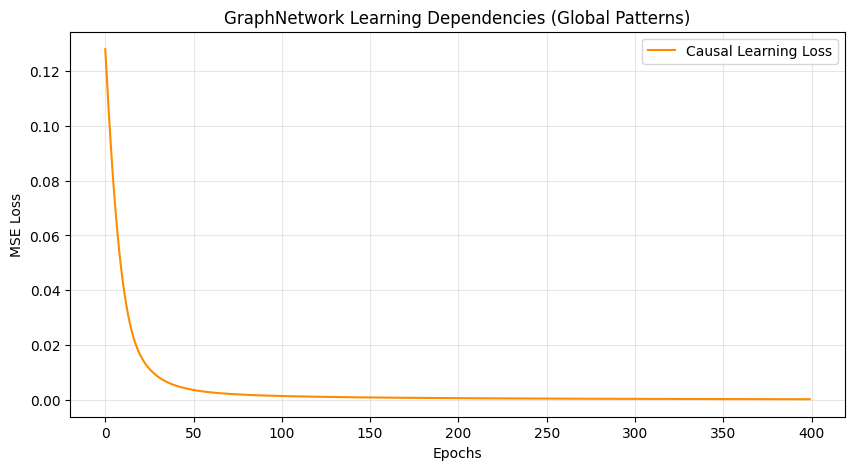

Training Complete.


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from typing import List

# ======================================================
# 1. THE GRAPH NETWORK (MODEL ARCHITECTURE)
# ======================================================
class GraphNetwork(nn.Module):
    def __init__(self,
                 node_feature_dims: List[int],
                 adjacency_matrix: np.ndarray,
                 latent_dim: int = 16):
        super().__init__()

        self.num_nodes = len(node_feature_dims)
        self.node_feature_dims = node_feature_dims
        self.latent_dim = latent_dim

        # Register the Graph Structure (DSM)
        self.register_buffer('adj', torch.tensor(adjacency_matrix, dtype=torch.float32).t())

        # 1. Dynamic Node Encoders
        self.encoders = nn.ModuleList([
            nn.Sequential(
                nn.Linear(dim, 16),
                nn.Tanh(), # Tanh is safer than ELU for preventing early NaN divergence
                nn.Linear(16, latent_dim),
                nn.LayerNorm(latent_dim)
            ) for dim in node_feature_dims
        ])

        # 2. Message Passing Layer
        self.message_passing = nn.Linear(latent_dim, latent_dim)

        # 3. Metric Projection Heads
        self.metric_heads = nn.ModuleList([
            nn.Sequential(
                nn.Linear(latent_dim, 8),
                nn.ReLU(),
                nn.Linear(8, 1),
                nn.Sigmoid() # Forces output to 0.0 - 1.0
            ) for _ in range(self.num_nodes)
        ])

        # Initialize weights safely
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)

    def forward(self, x_full):
        batch_size = x_full.size(0)
        node_embeddings = []
        current_col = 0

        # --- Step 1: Feature Slicing & Encoding ---
        for i, encoder in enumerate(self.encoders):
            dim_expected = self.node_feature_dims[i]

            # Slice data for this specific node
            x_slice = x_full[:, current_col : current_col + dim_expected]

            # Padding logic if input is too small
            if x_slice.shape[1] < dim_expected:
                padding = torch.zeros((batch_size, dim_expected - x_slice.shape[1]), device=x_full.device)
                x_slice = torch.cat([x_slice, padding], dim=1)

            h = encoder(x_slice)
            node_embeddings.append(h)
            current_col += dim_expected

        # --- Step 2: Graph Diffusion ---
        H = torch.stack(node_embeddings, dim=1)
        H_transformed = self.message_passing(H)

        # Einstein Summation: Mix latent states based on Adjacency Matrix
        H_propagated = torch.einsum('ij, bjk -> bik', self.adj, H_transformed)

        # Residual + Tanh Activation
        H_fused = torch.tanh(H + H_propagated)

        # --- Step 3: Metric Derivation ---
        metrics = [self.metric_heads[i](H_fused[:, i, :]) for i in range(self.num_nodes)]

        return torch.cat(metrics, dim=1), H_fused

# ======================================================
# 2. CAUSAL DATA SETUP (REPLACED)
# ======================================================
def setup_causal_data():
    print("--- Generating CAUSAL Synthetic Data (Global Patterns) ---")

    # Configuration (7 Nodes)
    # [Input, Input, Hub, Core, Core, Hub, Output]
    input_dims_flat = [d[0] for d in candidate_dims]
    num_nodes = len(input_dims_flat)
    total_features = sum(input_dims_flat)
    num_samples = 500

    # 1. Create Raw Features (X)
    X_raw = np.random.randn(num_samples, total_features).astype(np.float32)
    X_raw = np.clip(X_raw, -3.0, 3.0)
    X_tensor = torch.FloatTensor(X_raw)

    # 2. Create Causal Targets (Y)
    # We will make sure Y[i] depends on X[i] AND Y[i-1]
    Y_columns = []
    current_col = 0

    # "State Vector" to hold the output of the *previous* node
    # This simulates the flow of work/information downstream
    prev_node_output = np.zeros(num_samples)

    for i, dim in enumerate(input_dims_flat):
        # A. Intrinsic Value: Based on the node's own features
        feats = X_raw[:, current_col : current_col + dim]
        intrinsic_val = np.mean(feats, axis=1)

        # B. Dependency Value: Based on the previous node's output
        # If i=0 (Start), there is no previous node, so 0 dependency.
        # Otherwise, the "Upstream Influence" is significant (e.g., * 1.5)
        upstream_influence = prev_node_output * 1.5 if i > 0 else 0

        # C. Combined Signal
        signal = intrinsic_val + upstream_influence

        # D. Physics Activation (Sigmoid)
        # We squash the result to 0-1 so it matches the model's Sigmoid output
        val = 1.0 / (1.0 + np.exp(-signal))

        Y_columns.append(val)

        # Update state for next node
        prev_node_output = val
        current_col += dim

    Y_tensor = torch.FloatTensor(np.stack(Y_columns, axis=1))

    # 3. Create Topology (DSM)
    # We must construct a DSM that matches the Causal Logic we just created.
    # Since we made Y[i] depend on Y[i-1], the DSM must show a link (i-1) -> i
    DSM = np.eye(num_nodes) # Self loops (Intrinsic value)
    for i in range(num_nodes - 1):
        DSM[i+1, i] = 1 # Link Previous -> Current (Row i+1 receives from Col i)

    # Optional: Add a feedback loop (Last -> First) to make it complex
    DSM[0, num_nodes-1] = 1

    return X_tensor, Y_tensor, DSM, input_dims_flat

# ======================================================
# 3. TRAINING LOOP
# ======================================================
def train_graph_network():
    # 1. Get Causal Data
    X_train, Y_train, DSM, dims = setup_causal_data()

    # 2. Initialize Model
    model = GraphNetwork(
        node_feature_dims=dims,
        adjacency_matrix=DSM,
        latent_dim=32
    )

    # 3. Training Config
    optimizer = optim.Adam(model.parameters(), lr=0.002)
    criterion = nn.MSELoss() # Regression loss
    epochs = 400
    loss_history = []

    print(f"\n--- Starting Training on {len(X_train)} samples ---")
    model.train()

    for epoch in range(epochs):
        optimizer.zero_grad()

        # Forward Pass
        pred_metrics, _ = model(X_train)

        # Calculate Loss
        loss = criterion(pred_metrics, Y_train)

        # Backward Pass
        loss.backward()

        # Gradient Clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        loss_history.append(loss.item())

        if (epoch + 1) % 50 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] | Loss: {loss.item():.6f}")

    # 4. Visualization
    plt.figure(figsize=(10, 5))
    plt.plot(loss_history, label='Causal Learning Loss', color='darkorange')
    plt.title('GraphNetwork Learning Dependencies (Global Patterns)')
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    print("Training Complete.")
    return model

# ======================================================
# EXECUTION
# ======================================================
if __name__ == "__main__":
    trained_model = train_graph_network()

# Optimizer

# Helpers

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
# Target Mask (which metrics apply to which node)

def top_k_masked_probs(weights, k):
    """
    Keep only top-k weights, zero out the rest, renormalize.
    """
    if k >= len(weights):
        return weights / (weights.sum() + 1e-12)

    idx = np.argpartition(weights, -k)[-k:]
    mask = np.zeros_like(weights)
    mask[idx] = weights[idx]

    s = mask.sum()
    if s > 0:
        mask /= s
    return mask
def get_all_paths(G, C, node_types, start=0, end=None):
    """
    Return all simple paths that respect coupling constraints.
    """
    if end is None:
        end = G.shape[0] - 1

    D = G.shape[0]
    paths = []

    def coupling_ok(i, j):
        label = C[i, j]

        # Default direct coupling
        if "->" in label and "->C" not in label:
            src, dst = label.split("->")
            return src == node_types[i] and dst == node_types[j]

        # Escalation case (B->B->C)
        if label == "B->B->C":
            return node_types[i] == "B" and node_types[j] == "B"

        return False

    def dfs(node, path, visited):
        if node == end:
            paths.append(path.copy())
            return

        for nxt in range(D):
            if G[node, nxt] > 0 and nxt not in visited:
                if not coupling_ok(node, nxt):
                    continue

                visited.add(nxt)
                dfs(nxt, path + [nxt], visited)
                visited.remove(nxt)

    dfs(start, [start], {start})
    return paths



# =============================================================================
# EXTERNAL DEPENDENCIES & CONFIGURATION
# =============================================================================
# These variables are referenced in the original code but not defined.
# Assumed to be present in the execution environment.
# -----------------------------------------------------------------------------
# D_graph = ...
# DATA_MATRIX = ...
# METRIC_KEYS = [...]
# METRIC_TARGET = [...]
# METRIC_FORMULAS = [...]
# METRIC_INVERSES = {...}
# synthetic_targets = ...
# MetricsEvaluator = ... (Class)
# -----------------------------------------------------------------------------
# =============================================================================
# NEW: DETERMINISTIC DFS & PATH EVALUATOR
# =============================================================================


def evaluate_fixed_paths(paths, node_metrics, beta=0.3):
    """
    Replaces collect_and_select_best_walks.
    Scores the specific paths found by DFS.
    """
    walks = []
    best = None

    for path in paths:
        cost = 0.0
        quality = 0.0

        # Calculate Path Metrics
        for node_idx in path:
            m = node_metrics[node_idx]
            cost += m.get("cost", 0.0)
            quality += m.get("quality", 0.0)

        score = quality - 1.0 * cost # using default lambda_cost=1.0

        # DFS paths are unique, so count is always 1
        count = 1
        adjusted_score = score / (1 + beta * count)

        record = {
            "path": path,
            "score": score,
            "adjusted_score": adjusted_score,
            "cost": cost,
            "quality": quality,
            "count": count
        }
        walks.append(record)

        if best is None or adjusted_score > best["adjusted_score"]:
            best = record

    return walks, best

def dsm_walk(G, node_metrics, start=0, max_steps=50, lambda_cost=1.0):
    D = G.shape[0]
    target_node = D - 1  # Define Nlast

    # Force start at 0 if not provided
    current = start
    path = [current]
    visited = {current}

    cost = 0.0
    quality = 0.0

    # Metrics for the start node
    m_start = node_metrics[current]
    cost += m_start.get("cost", 0.0)
    quality += m_start.get("quality", 0.0)

    reached_target = False

    for _ in range(max_steps):
        # If we reached the last node, stop successfully
        if current == target_node:
            reached_target = True
            break

        weights = np.zeros(D)

        for j in range(D):
            # Allow visiting the target even if visited (though unlikely to revisit in DAG)
            # But generally prevent cycles
            if j == 0:
                continue
            if j in visited:
                continue

            q = node_metrics[j].get("quality", 0.0)
            c = node_metrics[j].get("cost", 0.0)

            # Standard probability weight
            weights[j] = G[current, j] * (q / (1 + c))

        if weights.sum() == 0:
            break

        weights /= weights.sum()
        nxt = np.random.choice(D, p=weights)

        m = node_metrics[nxt]
        cost += m.get("cost", 0.0)
        quality += m.get("quality", 0.0)

        path.append(nxt)
        visited.add(nxt)
        current = nxt

    # Recalculate score based on success
    score = quality - lambda_cost * cost

    # Heavy penalty if the walk did not reach Nlast
    if not reached_target:
        score = -1e9

    return path, score, cost, quality

from collections import defaultdict

def collect_and_select_best_walks(G, node_metrics, n_walks=300, beta=0.3):
    walks = []
    best = None
    path_counts = defaultdict(int)
    D = G.shape[0]

    for _ in range(n_walks):
        # Force start at 0
        start = 0
        path, score, cost, quality = dsm_walk(
            G, node_metrics, start
        )

        # Only record if it successfully reached the last node
        # (Score is -1e9 if it failed, per updated dsm_walk)
        if path[-1] != (D - 1):
            continue

        key = tuple(path)
        path_counts[key] += 1

        # novelty penalty
        adjusted_score = score / (1 + beta * path_counts[key])

        record = {
            "path": path,
            "score": score,
            "adjusted_score": adjusted_score,
            "cost": cost,
            "quality": quality,
            "count": path_counts[key]
        }
        walks.append(record)

        if best is None or adjusted_score > best["adjusted_score"]:
            best = record

    return walks, best


# Configuration
#candidate_dims = [[2], [2], [2], [2], [2], [2], [2], [2], [1]]
outer_generations = 1
inner_learning = 0.1
gamma_interlayer = 1
top_k = 21

# Initialize random state
np.random.seed()
seed = None  # Placeholder as per original logic

# Placeholder for Data Matrix generation (from original snippet)
# new_DATA_MATRIX = np.random.rand(D_graph, DATA_MATRIX.shape[1])


# =============================================================================
# HELPER CLASSES
# =============================================================================
class DSM_Tracker:
    """
    Tracks a DSM (Design Structure Matrix) layer and its residual.
    """
    def __init__(self, multiplex_layer):
        self.layer = multiplex_layer
        self.primary_dsm = None
        self.residual_dsm = None
        self.update_dsms()

    def update_dsms(self):
        if self.primary_dsm is None:
            # First time: store current DSM as reference
            self.primary_dsm = self.layer.chosen_Gmat.copy()
            self.residual_dsm = np.zeros_like(self.primary_dsm)
        else:
            # Update residual: current DSM minus primary
            current = self.layer.chosen_Gmat
            self.residual_dsm = current - self.primary_dsm

    def get_matrices(self):
        return self.primary_dsm, self.residual_dsm

    def print_matrices(self):
        print("\n--- Primary DSM ---")
        print(self.primary_dsm)
        print("\n--- Residual DSM ---")
        print(self.residual_dsm)


import numpy as np

class DSM_Layer_Decomposer:
    """
    Manages the additive decomposition of DSM layers.
    Now includes integrity checks and baseline-aware reconstruction.
    """
    def __init__(self, baseline_matrix, mode='additive'):
        self.baseline_matrix = baseline_matrix.copy()
        self.current_total = baseline_matrix.copy()
        self.mode = mode
        self.layers = []
        self.residuals = []

    def add_snapshot(self, new_total_matrix):
        """
        Calculates the DELTA (change) between the new state and the previous state.
        """
        # Calculate Delta
        delta = new_total_matrix - self.current_total

        # Guard clause: Optional warning if delta is empty
        if np.all(delta == 0):
            print(f"Warning: Snapshot added with ZERO change. Layer {len(self.layers)} is empty.")

        self.layers.append(delta.copy())

        # Update current tracker
        self.current_total = new_total_matrix.copy()

        # Calculate residual (Total Drift from Baseline)
        residual = self.current_total - self.baseline_matrix
        self.residuals.append(residual)

        layer_id = len(self.layers) - 1
        print(f"\n=== DSM LAYER {layer_id} CAPTURED ===")
        # formatting for cleaner output
        print(f"Layer Contribution (Delta) Max Value: {np.max(np.abs(delta)):.3f}")

        return delta

    def get_reconstruction(self, include_baseline=True):
        """
        reconstructs the matrix.
        Args:
            include_baseline (bool): If True, returns (Baseline + Layers).
                                     If False, returns only the changes (Layers).
        """
        layers_sum = np.sum(self.layers, axis=0)

        if include_baseline:
            return self.baseline_matrix + layers_sum
        return layers_sum

    def verify_integrity(self):
        """Debug function to prove all layers are accounted for."""
        reconstructed = self.get_reconstruction(include_baseline=True)
        is_correct = np.allclose(reconstructed, self.current_total)
        print(f"Integrity Check: {'PASSED' if is_correct else 'FAILED'}")
        print(f"Total Layers Stored: {len(self.layers)}")


class SVM:
    """
    Metric-inverse multi-output SVM with epsilon-insensitive loss.
    """
    def __init__(self, input_dim, output_dim=None, metric_keys=None, lr=0.001, epsilon=0.1):
        self.input_dim = input_dim
        self.metric_keys = metric_keys

        if metric_keys is not None:
            self.output_dim = len(metric_keys)
        elif output_dim is not None:
            self.output_dim = output_dim
        else:
            self.output_dim = 1

        self.lr = lr
        self.epsilon = epsilon

        # Lazy initialization
        self.X_train = None
        self.y_train = None
        self.alpha = None
        self.b = None

    def train_step(self, X, y_true):
        X = np.array(X)
        y_true = np.array(y_true)
        n_samples = X.shape[0]

        if self.X_train is None:
            self.X_train = X.copy()
            self.y_train = y_true.copy()
            self.alpha = np.zeros((X.shape[1], self.output_dim))
            self.b = np.zeros(self.output_dim)

        # Linear kernel
        y_pred = X.dot(self.alpha) + self.b

        # Epsilon-insensitive loss
        diff = y_pred - y_true
        mask = np.abs(diff) > self.epsilon
        diff *= mask

        grad_alpha = X.T.dot(diff) / n_samples
        grad_b = diff.mean(axis=0)

        self.alpha -= self.lr * grad_alpha
        self.b -= self.lr * grad_b

        loss = np.mean(np.maximum(0, np.abs(y_pred - y_true) - self.epsilon))
        return loss

    def predict(self, X):
        X = np.array(X)
        y_pred = X.dot(self.alpha) + self.b

        if self.metric_keys is None:
            return y_pred

        # Apply metric inverses
        y_transformed = np.zeros_like(y_pred)
        for i, key in enumerate(self.metric_keys):
            inverse_fn = METRIC_INVERSES[key]
            # Handle potential list return from inverse_fn
            val_func = lambda y: inverse_fn(y)[0] if isinstance(inverse_fn(y), list) else inverse_fn(y)
            y_transformed[:, i] = np.array([val_func(y) for y in y_pred[:, i]])

        return y_transformed


class InterLayer:
    def __init__(self, D_graph, max_inner_dim, inter_dim=None, edge_threshold=0.02, gamma=1.0, seed=42):
        if seed is not None:
            np.random.seed(seed)

        self.D_graph = D_graph
        self.edge_threshold = edge_threshold
        self.gamma = gamma

        # Handle list vs int inputs for dimensions
        m_dim = max_inner_dim[0] if isinstance(max_inner_dim, list) else max_inner_dim

        if inter_dim is not None:
            self.inter_dim = inter_dim[0] if isinstance(inter_dim, list) else inter_dim
        else:
            self.inter_dim = m_dim

        self.max_input = 2 * m_dim

        # Initialize weights
        self.weights = {}
        self.bias = {}
        for i in range(D_graph):
            for j in range(D_graph):
                if i != j:
                    w_init = np.random.uniform(-0.1, 0.1, (self.inter_dim, self.max_input))
                    self.weights[(i, j)] = w_init
                    self.bias[(i, j)] = np.zeros(self.inter_dim)

    def compute_edge_activation(self, i, j, nested_reps):
        concat = np.concatenate([nested_reps[i], nested_reps[j]])
        # Pad or truncation
        if len(concat) < self.max_input:
            concat = np.pad(concat, (0, self.max_input - len(concat)))
        else:
            concat = concat[:self.max_input]

        # Normalize
        concat = (concat - np.mean(concat)) / (np.std(concat) + 1e-12)

        # Activation
        v = self.weights[(i, j)].dot(concat) + self.bias[(i, j)]
        input_strength = np.clip(np.mean(np.abs(concat)), 0, 1)
        v = v * input_strength

        return 1 / (1 + np.exp(-v))

    def build_activations(self, Gmat, nested_reps):
        acts = {}
        for i in range(self.D_graph):
            for j in range(self.D_graph):
                if i == j:
                    continue
                if abs(Gmat[i, j]) > self.edge_threshold:
                    acts[(i, j)] = self.compute_edge_activation(i, j, nested_reps)
        return acts

    @staticmethod
    def pairwise_squared_corr(acts):
        if len(acts) < 2:
            return 0.0
        A = np.stack(list(acts.values()))
        A_centered = A - A.mean(axis=1, keepdims=True)
        stds = np.sqrt(np.sum(A_centered**2, axis=1) / (A.shape[1]-1) + 1e-12)
        cov = A_centered @ A_centered.T / (A.shape[1]-1)
        corr = cov / (np.outer(stds, stds) + 1e-12)
        np.fill_diagonal(corr, 0)
        return float((corr**2).sum())

    def mi_for_graph(self, Gmat, nested_reps):
        acts = self.build_activations(Gmat, nested_reps)
        if not acts:
            return 0.0
        return self.gamma * self.pairwise_squared_corr(acts)

def build_dsm_from_walks(D, paths):
    """
    Constructs a DSM where entry [i,j] is the probability
    that a successful process moves from i to j.
    """
    flow = np.zeros((D, D))

    # Count transitions
    for path in paths:
        for k in range(len(path) - 1):
            u, v = path[k], path[k+1]
            flow[u, v] += 1

    # Normalize by the total number of successful walks.
    # This prevents 'saturation'—if an edge is rarely used, it stays small.
    n_paths = len(paths)
    if n_paths > 0:
        flow = flow / n_paths

    np.fill_diagonal(flow, 0.0)
    return flow



try:
    D_GRAPH = D_graph
except:
    D_graph=D_GRAPH


def build_coupling_weight(label, m_i, m_j):
    """
    Interpretation: Pascal's Law P = F / A
    Force (F) = Potential delta in metrics (Improvement)
    Area (A) = Complexity/Friction of the destination node
    Valve = Orifice efficiency based on coupling type
    """

    # 1. THE NODAL VECTORS
    v_i = np.array(list(m_i.values())) if isinstance(m_i, dict) else np.array(m_i)
    v_j = np.array(list(m_j.values())) if isinstance(m_j, dict) else np.array(m_j)

    # 2. THE DRIVING FORCE (F)
    # The pressure only builds if the destination offers more "potential"
    # F = || max(0, v_j - v_i) ||
    force = np.linalg.norm(np.maximum(v_j - v_i, 0)) + 1e-9

    # 3. THE SURFACE AREA (A)
    # The 'wider' the destination node (more complex/costly),
    # the more the force is distributed, lowering the pressure.
    surface_area = np.mean(v_j) + 0.1

    # 4. THE VALVE ORIFICE (Efficiency)
    # A-type couplings are 'Wide Nozzles' (High pressure translation)
    # B-type couplings are 'Constricted Nozzles' (Damped flow)
    label_str = str(label) if label is not None else ""
    if "A" in label_str:
        motivator = force # High flow efficiency
    elif "B" in label_str:
        motivator =  1.0  # Damped efficiency
    else:
        motivator = surface_area# Standard atmospheric pressure

    # 5. THE SYSTEM PRESSURE (P)
    # (i) Power driver
    # (iii) Force driver
    # (ii) Pressure
    pressure = motivator * (force / surface_area)

    return max(pressure, 0.0001)
import numpy as np

def infer_node_types(node_metrics, candidate_dims=candidate_dims):
    dims_flat = [d[0] for d in candidate_dims]

    min_dim = min(dims_flat)
    max_dim = max(dims_flat)
    median_dim = np.median(dims_flat)

    node_types = []
    for d in dims_flat:
        if d == min_dim:
            node_types.append("A") # Edge (Output/Market)
        elif d == max_dim:
            node_types.append("C") # Core (16D Hubs/Insurance)
        elif d < median_dim:
            node_types.append("B") # External Gatekeeper (New!)
        else:
            node_types.append("B") # Internal Hub (Cultivation)

    return node_types

def build_coupling_matrix(node_types):
    """
    Generic Behavioral Matrix Builder.
    Uses a 'Transition Rulebook' to enforce flow constraints.
    """
    D = len(node_types)
    C = np.full((D, D), "VOID", dtype=object)

    # DEFINING THE FLOW LOGIC (The "Constitution")
    # Format: { Source_Type: { Allowed_Dest_Type: Label } }
    # Any transition not listed here becomes "ABSORBED"



    RULES = {
    "D": {
        "D": "D->D",      # Lateral Saturation (Peer-Hopping Allowed)
        "C": "D->C",      # Saturated Data feeds Core
        "B": "D->B"       # External triggers Hub directly
    },
    "C": {
        "B": "C->B"       # Core feeds Hub
    },
    "B": {
        "B": "B->B",      # Hub stability
        "A": "B->A"       # Hub ejects to Edge
    },
    "A": {
        "A": "A->A",      # Edge local routing
        "C": "A->C",      # Edge returns to Core
        "D": "A->D"       # Edge triggers external refresh
    }
}
    D_size = len(node_types)
    C = np.full((D_size, D_size), "VOID", dtype=object)

    for i in range(D_size):
        src = node_types[i]
        for j in range(D_size):
            dst = node_types[j]

            if src in RULES:
                allowed_moves = RULES[src]

                if dst in allowed_moves:
                    label = allowed_moves[dst]

                    # BLOCK Hub-Hopping for B (Efficiency constraint)
                    if src == "B" and dst == "B" and i != j:
                        C[i, j] = "ABSORBED"

                    # ALLOW Peer-Hopping for D (Saturation constraint)
                    # This allows different D-nodes to cross-talk
                    elif src == "D" and dst == "D":
                        C[i, j] = "D<->D" if i != j else "D_SELF"

                    else:
                        C[i, j] = label
                else:
                    C[i, j] = "ABSORBED"
            else:
                C[i, j] = "ABSORBED"

    return C

def build_dsm_from_walks(D, paths):
    """
    Constructs a DSM (Design Structure Matrix) from walk paths.
    Entry [i,j] is the probability that a process moves from i to j.
    """
    flow = np.zeros((D, D))
    for path in paths:
        for k in range(len(path) - 1):
            u, v = path[k], path[k+1]
            flow[u, v] += 1

    n_paths = len(paths)
    if n_paths > 0:
        flow = flow / n_paths

    np.fill_diagonal(flow, 0.0)
    return flow

# =============================================================================
# 2. THE METRIC-DRIVEN RANDOM WALKER (Consolidated)
# =============================================================================

from collections import deque
all_results = []
class CouplingState:
    """
    Q* DESIGN ENGINE:
    Uses Bellman Optimality to evaluate path potential.
    Q(s, a) = R(s, a) + gamma * max(Q(s', a'))
    """
    def __init__(self, coupling_matrix, node_metrics, gamma=0.85, max_depth=12):
        self.C = coupling_matrix
        self.node_metrics = node_metrics
        self.D = len(node_metrics)
        self.max_depth = max_depth
        self.gamma = gamma # Discount factor (how much we value future potential)

        # Static Type Inference
        dims = [len(m) if isinstance(m, dict) else len(m) for m in node_metrics]
        self.node_types = ["A" if d == min(dims) else "B" if d == max(dims) else "C" for d in dims]

        # PRE-COMPUTE THE Q-TABLE (The 'Brain')
        self.q_table = self._build_q_table()

    def _get_immediate_reward(self, i, j, label):
        """The 'Ohmic' reward: Force / Friction."""
        m_i, m_j = self.node_metrics[i], self.node_metrics[j]
        v_i = np.array(list(m_i.values())) if isinstance(m_i, dict) else np.array(m_i)
        v_j = np.array(list(m_j.values())) if isinstance(m_j, dict) else np.array(m_j)

        # Potential Displacement (Voltage)
        potential = np.linalg.norm(np.maximum(v_j - v_i, 0)) + 1e-9
        # Synergy (Conductance alignment)
        synergy = np.dot(v_i, v_j) / (np.linalg.norm(v_i) * np.linalg.norm(v_j) + 1e-9)

        # Resistance (Viscosity)
        area = np.mean(v_j) + 0.1
        penalty = 3.0 if "B" in str(label) else 1.0

        # Reward = (V * Synergy) / R
        return (potential * (1 + synergy)) / (area * penalty)

    def _build_q_table(self):
        """
        Iteratively solves the Bellman Equation for all nodes.
        This defines the 'Heuristic' for the search.
        """
        # Initialize Q-values with immediate rewards
        Q = np.zeros((self.D, self.D))
        for i in range(self.D):
            for j in range(self.D):
                label = self.C[i, j]
                if label not in ["ABSORBED", "VOID"]:
                    Q[i, j] = self._get_immediate_reward(i, j, label)

        # Iterate to propagate future values (Bellman Update)
        for _ in range(10): # 10 iterations to settle the manifold
            new_Q = Q.copy()
            for i in range(self.D):
                for j in range(self.D):
                    label = self.C[i, j]
                    if label not in ["ABSORBED", "VOID"]:
                        # Q = Reward + Gamma * (Best possible move from next node)
                        max_future = np.max(Q[j, :]) if np.any(Q[j, :]) else 0
                        new_Q[i, j] = Q[i, j] + self.gamma * max_future
            Q = new_Q
        return Q

    def run(self, start_node, end_node, q_threshold=0.2):
        """
        Q-STAR SEARCH:
        Only follows paths where the total path Q-value remains above threshold.
        """
        # Stack: (curr, path, cumulative_q, saturated)
        stack = [(start_node, [start_node], 0.0, False)]
        elite_trajectories = []

        while stack:
            u, path, path_q, saturated = stack.pop()

            if u == end_node:
                elite_trajectories.append((path, path_q))
                continue

            if len(path) >= self.max_depth:
                continue

            # Look up pre-calculated Q-values for all neighbors
            for v in range(self.D):
                label = self.C[u, v]
                if label in ["ABSORBED", "VOID"]: continue

                # Fetch the 'Quality' of this move
                move_q = self.q_table[u, v]

                # --- Q-STAR PRUNING ---
                # If the move doesn't lead to a high-value future, kill the branch
                if move_q < q_threshold:
                    continue

                # Automaton Gates
                is_b_loop = (label == "B->B")
                if saturated and self.node_types[v] != "A": continue
                if v in path and not (u == v and is_b_loop): continue

                stack.append((v, path + [v], path_q + move_q, is_b_loop))

        # Sort by Cumulative Quality
        elite_trajectories.sort(key=lambda x: x[1], reverse=True)
        return [t[0] for t in elite_trajectories]

import numpy as np

class CouplingSttate:
    """
    SELF-GOVERNING Q* ENGINE:
    Rules are integrated as intrinsic manifold properties.
    Uses 'State Saturation' to prevent illegal transmission.
    """
    def __init__(self, coupling_matrix, node_metrics, gamma=0.88):
        self.C = coupling_matrix
        self.M = np.array([list(m.values()) if isinstance(m, dict) else m for m in node_metrics])
        self.D = len(node_metrics)
        self.gamma = gamma

        # Self-Rule Mapping (Determined by Feature Density)
        dims = np.array([m.shape[0] for m in self.M])
        # C: Anchor (16D), B: Transformer (8-12D), A: Leaf (4D)
        self.tier_map = np.where(dims >= 16, "C", np.where(dims >= 8, "B", "A"))

        self.q_table = self._build_q_table()

    def _get_self_rule_reward(self, i, j):
        ti, tj = self.tier_map[i], self.tier_map[j]
        v_i, v_j = self.M[i], self.M[j]

        force = np.linalg.norm(v_j)
        synergy = np.dot(v_i, v_j) / (np.linalg.norm(v_i) * np.linalg.norm(v_j) + 1e-9)

        rule_friction = 1.0
        saturation_bonus = 1.0

        # --- THE D-ISOLATION RULE ---
        if ti == "D":
            if tj == "D":
                # Lateral movement within the sandbox is highly encouraged
                saturation_bonus = 2.0
            else:
                # Strictly penalize leaving Tier D until the 'External' work is done
                # This makes D a "sink" that requires high Q-value to escape
                rule_friction = 0.05

        # --- CORE RECOVERY (Allowing C to pull from a saturated D) ---
        if ti == "C" and tj == "D": rule_friction = 0.0001

        # --- STANDARD FLOW ---
        if ti == "B" and tj == "C": rule_friction = 0.0001
        if ti == "A" and tj in ["B", "C", "D"]: rule_friction = 0.0001

        return (force * (1 + synergy)) * rule_friction * saturation_bonus

    def _build_q_table(self):
        """Bellman iterations stabilize the 'Legal' path potential."""
        Q = np.zeros((self.D, self.D))
        for i in range(self.D):
            for j in range(self.D):
                if str(self.C[i,j]).strip() not in ["VOID", "0"]:
                    Q[i, j] = self._get_self_rule_reward(i, j)

        for _ in range(15):
            # Future Reflections check if the path remains 'Legal' to the end
            max_future = np.max(Q, axis=1)
            Q = Q + self.gamma * max_future[:, np.newaxis]
        return Q

    def run_safe_path(self, start=0, end=11):
        """Execute search using Self-Rule Pruning."""
        # Top-down Beam Search
        beams = [([start], 0.0)]

        for _ in range(self.D):
            candidates = []
            for path, score in beams:
                u = path[-1]
                if u == end:
                    candidates.append((path, score))
                    continue

                for v in range(self.D):
                    if v in path or str(self.C[u,v]).strip() in ["VOID", "0"]: continue

                    # Q* Value provides the 'Safe' Heuristic
                    move_q = self.q_table[u, v]
                    candidates.append((path + [v], score + move_q))

            if not candidates: break
            candidates.sort(key=lambda x: x[1], reverse=True)
            beams = candidates[:5] # Keep Top 5 trajectories

        return beams[0] # Return most stable legal path

class StrategicBrain(CouplingSttate):
    """
    MINIMAX Q* ENGINE:
    Uses Alpha-Beta pruning to find the path of Maximum Guaranteed Information.
    Protects against 'Bogus' shortcuts by assuming the worst possible future noise.
    """

    def run_minimax(self, start=0, end=11, max_depth=8):
        # We start with Alpha (Worst possible) and Beta (Best possible)
        # To find the path that maximizes the minimum guaranteed throughput.

        best_path = []
        best_score = -float('inf')

        def minimax(u, path, alpha, beta, depth, is_maximizing):
            if u == end:
                return self.evaluate_path(path), path

            if depth == 0:
                # Use Q-Table as the 'Static Evaluation' (The Gut Feeling)
                return np.max(self.q_table[u, :]), path

            if is_maximizing:
                max_eval = -float('inf')
                best_trajectory = path

                # Sort neighbors by Q-value to optimize Alpha-Beta pruning
                neighbors = np.argsort(self.q_table[u, :])[::-1]

                for v in neighbors:
                    if v in path or str(self.C[u, v]).strip() in ["VOID", "0"]: continue

                    eval_val, res_path = minimax(v, path + [v], alpha, beta, depth - 1, False)
                    if eval_val > max_eval:
                        max_eval = eval_val
                        best_trajectory = res_path

                    alpha = max(alpha, eval_val)
                    if beta <= alpha: # THE ALPHA-BETA PRUNE
                        break
                return max_eval, best_trajectory

            else:
                # MINIMIZER: Represents the 'Constraint Pressure'
                # It looks for where the rules are most likely to pinch the signal
                min_eval = float('inf')
                best_trajectory = path

                neighbors = np.argsort(self.q_table[u, :])
                for v in neighbors:
                    if v in path or str(self.C[u, v]).strip() in ["VOID", "0"]: continue

                    eval_val, res_path = minimax(v, path + [v], alpha, beta, depth - 1, True)
                    if eval_val < min_eval:
                        min_eval = eval_val
                        best_trajectory = res_path

                    beta = min(beta, eval_val)
                    if beta <= alpha:
                        break
                return min_eval, best_trajectory

        score, final_path = minimax(start, [start], -float('inf'), float('inf'), max_depth, True)
        return final_path, score

    def evaluate_path(self, path):
        """Calculates total Information Fidelity along a static path."""
        total_q = 0
        for i in range(len(path) - 1):
            total_q += self.q_table[path[i], path[i+1]]
        return total_q

# FHM

__________________________________________________ 0 -------------------------------------------------- 14 ==================================================
Starting Optimization: 3 Layers x 1 Gens

>>> COMPILING LAYER 1: STRUCTURE <<<
 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 14 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.92  0.00  0.00  0.99  0.96  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0

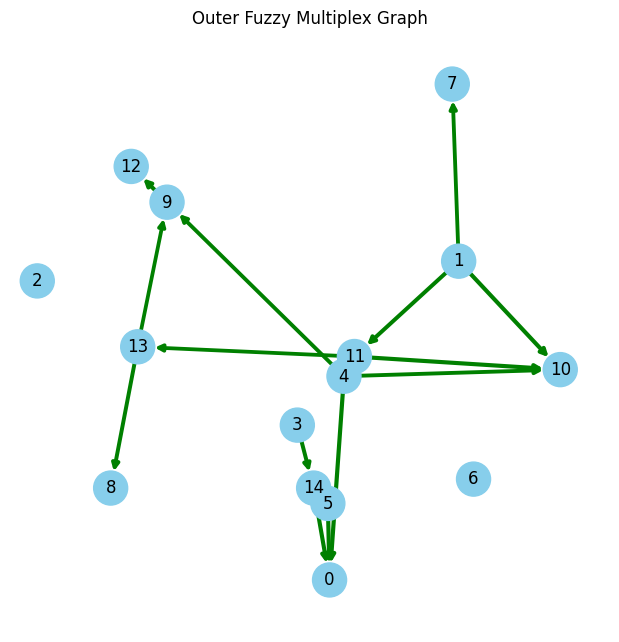

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 14 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.92  0.00  0.00  0.99  0.96  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.95 
N 4 |  1.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.93  0.93  0.00  0.00  0.00  0.00 
N 5 |  0.99  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

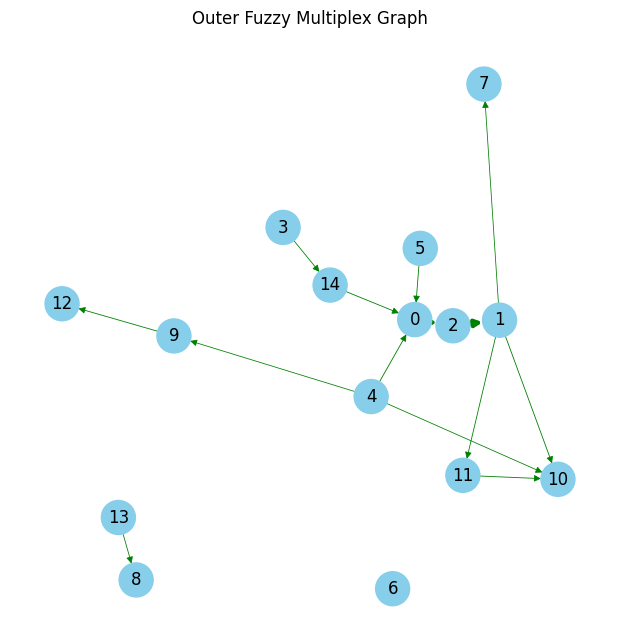

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 14 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.97  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.13  0.13  0.00  0.00  0.00 
N 2 |  0.00  1.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13 
N 4 |  0.14  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13  0.13  0.00  0.00  0.00  0.00 
N 5 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

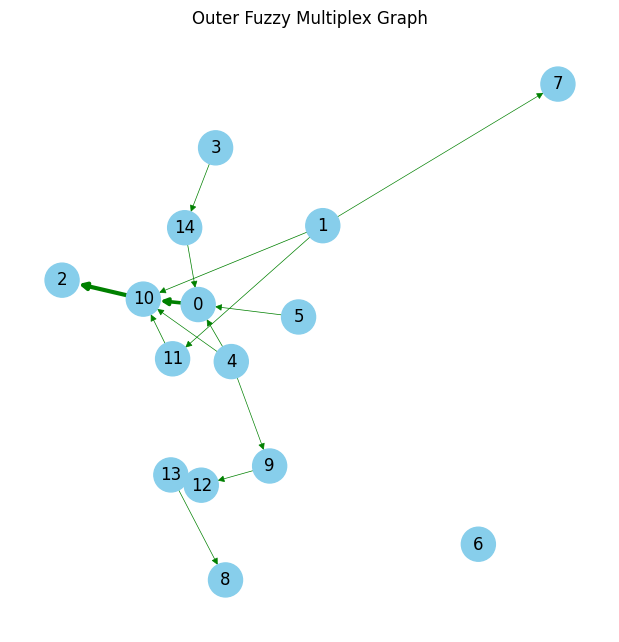

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 14 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.90  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.00  0.00  0.12  0.11  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11 
N 4 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.11  0.00  0.00  0.00  0.00 
N 5 |  0.11  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

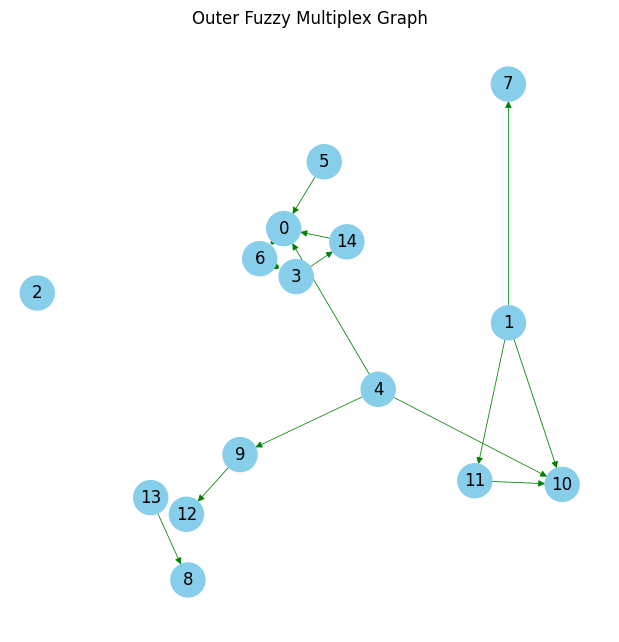

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 14 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.92  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.13  0.13  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12 
N 4 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.12  0.00  0.00  0.00  0.00 
N 5 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  1

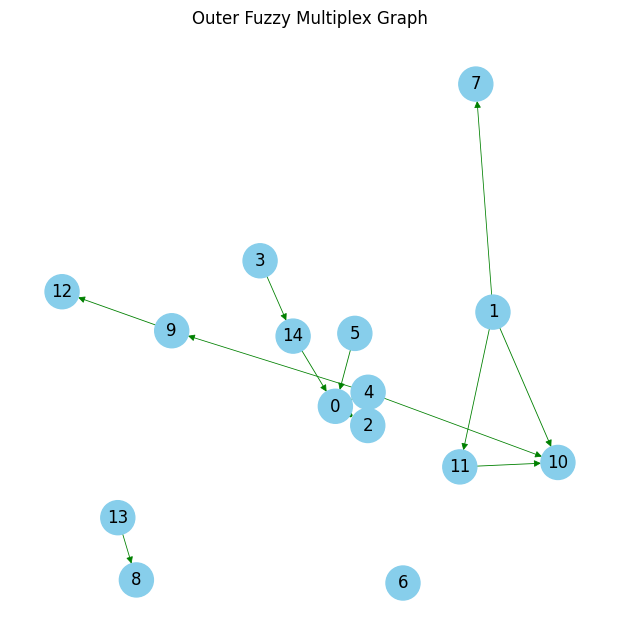

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 14 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.98  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13  0.00  0.00  0.14  0.13  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  1.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13 
N 4 |  0.14  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13  0.13  0.00  0.00  0.00  0.00 
N 5 |  0.14  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

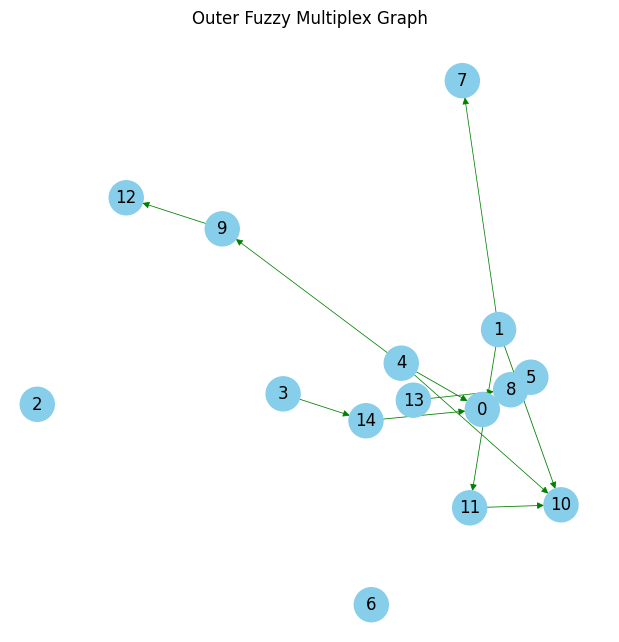

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 14 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  1.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.13  0.13  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13 
N 4 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.12  0.00  0.00  0.00  0.00 
N 5 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

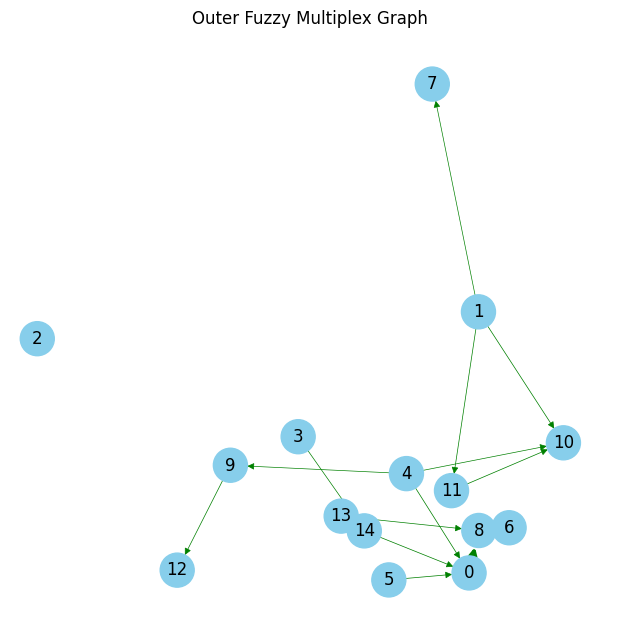

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 14 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.97  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.00  0.00  0.12  0.11  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11 
N 4 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.11  0.00  0.00  0.00  0.00 
N 5 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

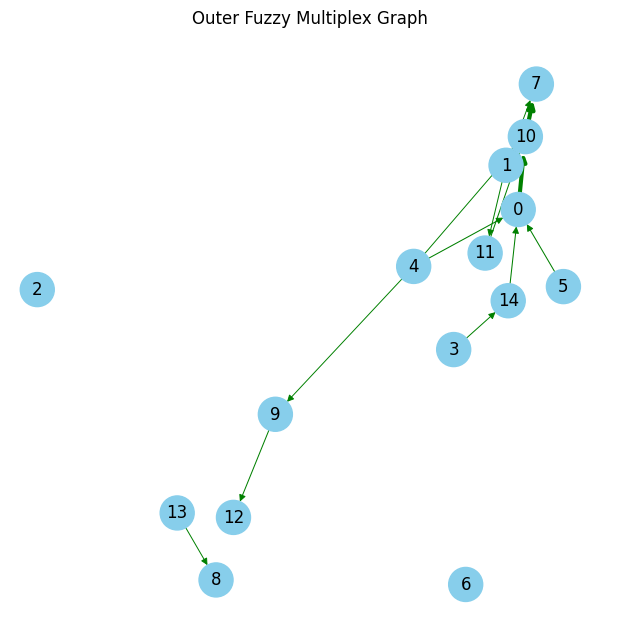

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 14 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.99  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.15  0.00  0.00  0.17  0.16  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.16 
N 4 |  0.17  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.15  0.16  0.00  0.00  0.00  0.00 
N 5 |  0.16  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

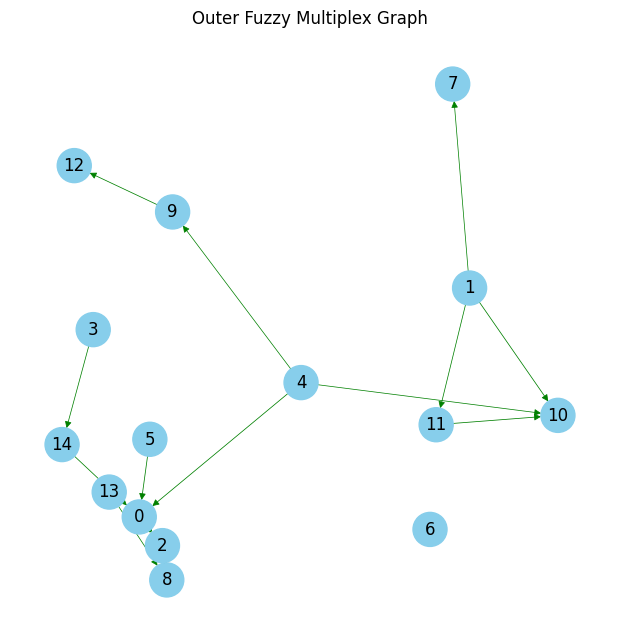

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 14 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.95  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.00  0.00  0.12  0.12  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  1.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12 
N 4 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.12  0.00  0.00  0.00  0.00 
N 5 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

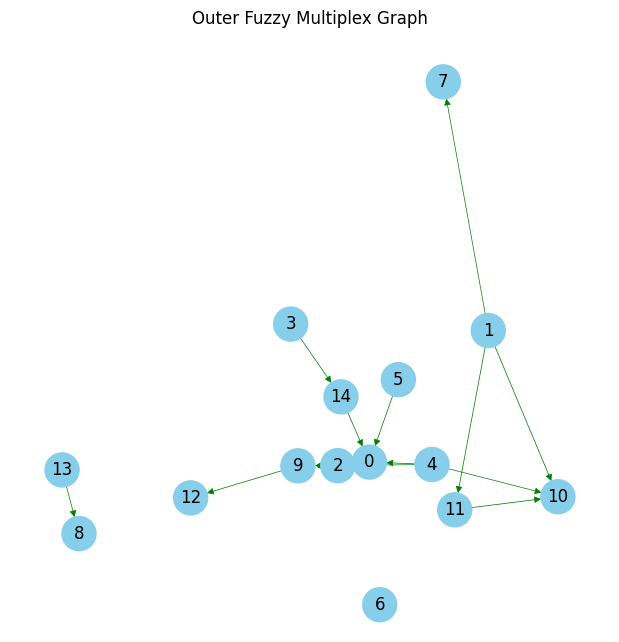

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 14 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.94  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.00  0.00  0.12  0.12  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  1.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12 
N 4 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.11  0.00  0.00  0.00  0.00 
N 5 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

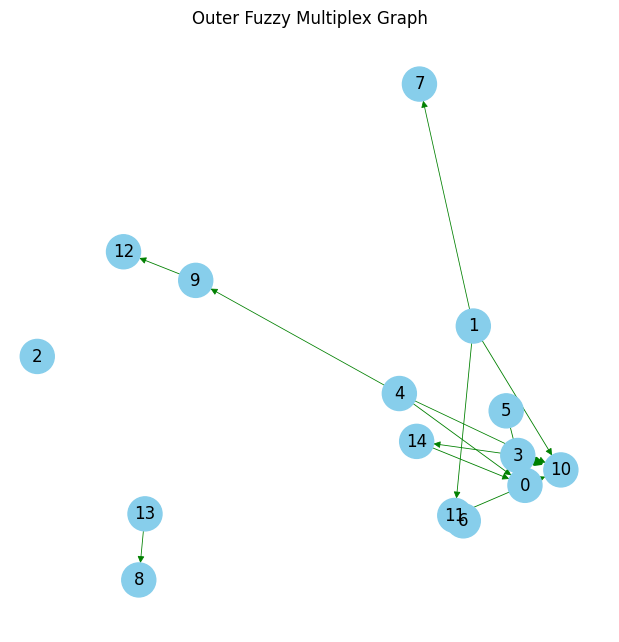

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 14 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  1.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13  0.00  0.00  0.14  0.13  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.95  0.00  0.00  0.00  0.13 
N 4 |  0.14  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13  0.13  0.00  0.00  0.00  0.00 
N 5 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

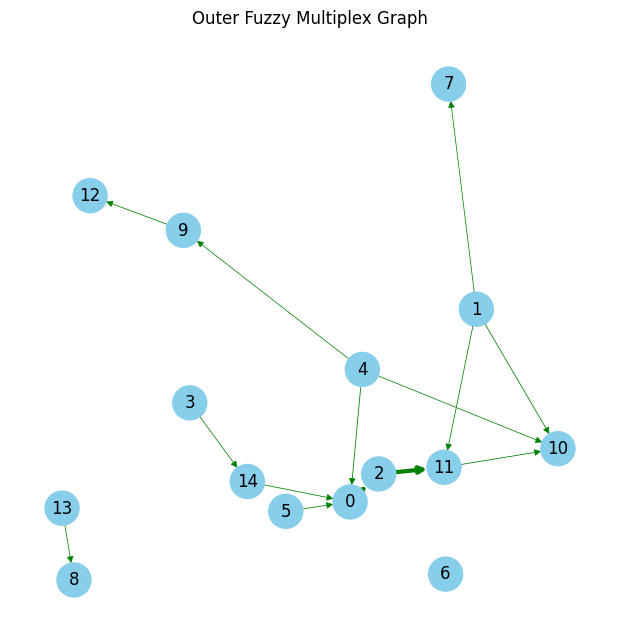

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 14 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.96  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.13  0.12  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  1.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12 
N 4 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.12  0.00  0.00  0.00  0.00 
N 5 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

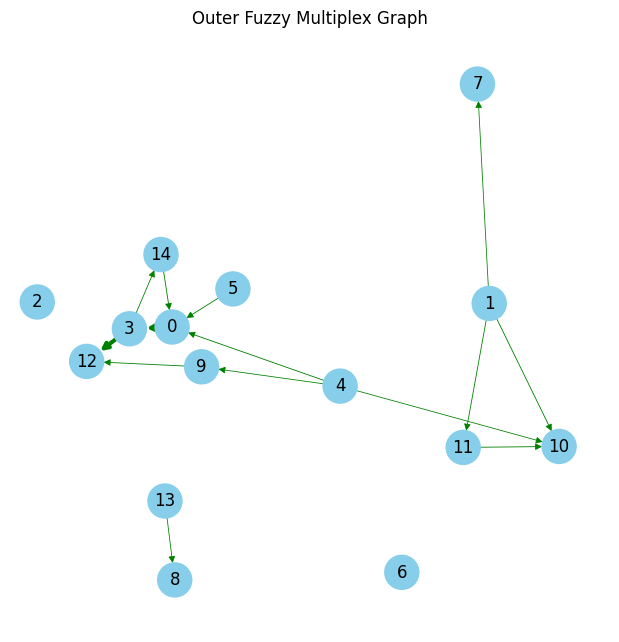

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 14 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  1.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13  0.00  0.00  0.14  0.13  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.99  0.00  0.13 
N 4 |  0.14  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13  0.13  0.00  0.00  0.00  0.00 
N 5 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

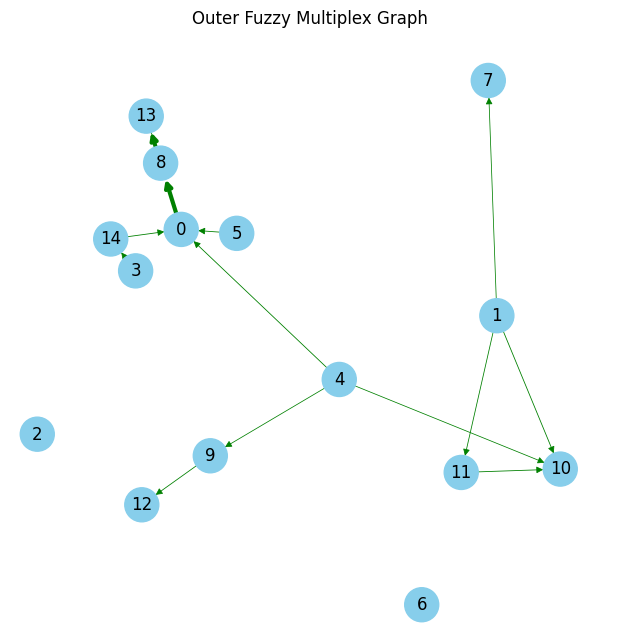

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 14 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  1.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.13  0.13  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13 
N 4 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.12  0.00  0.00  0.00  0.00 
N 5 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

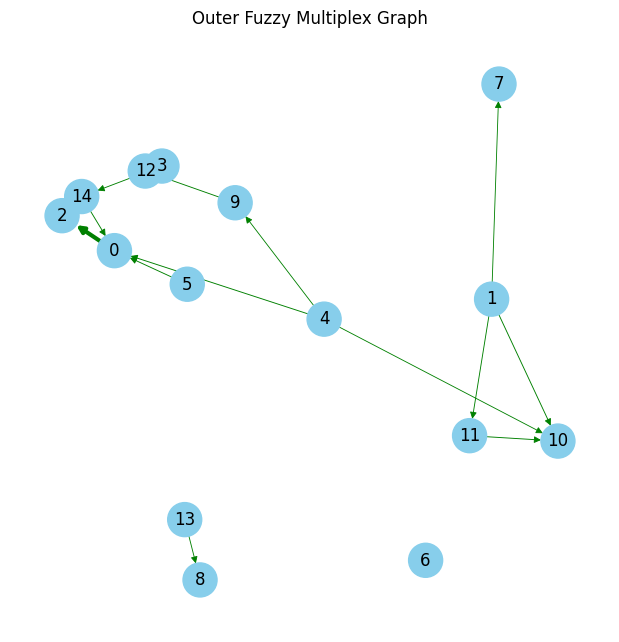

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 14 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  1.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.14  0.00  0.00  0.15  0.14  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.98 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.14 
N 4 |  0.15  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.14  0.14  0.00  0.00  0.00  0.00 
N 5 |  0.15  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

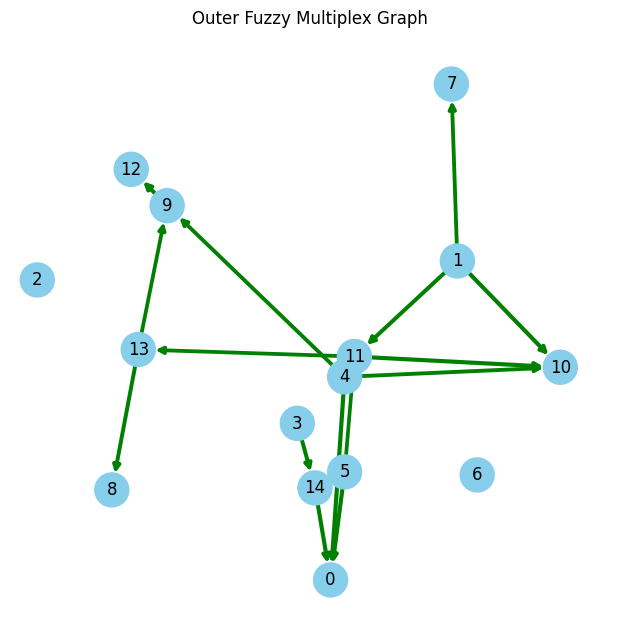

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 15 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.92  0.00  0.00  0.99  0.96  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.95 
N 4 |  1.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.93  0.93  0.00  0.00  0.00  0.00 
N 5 |  0.99  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.89  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

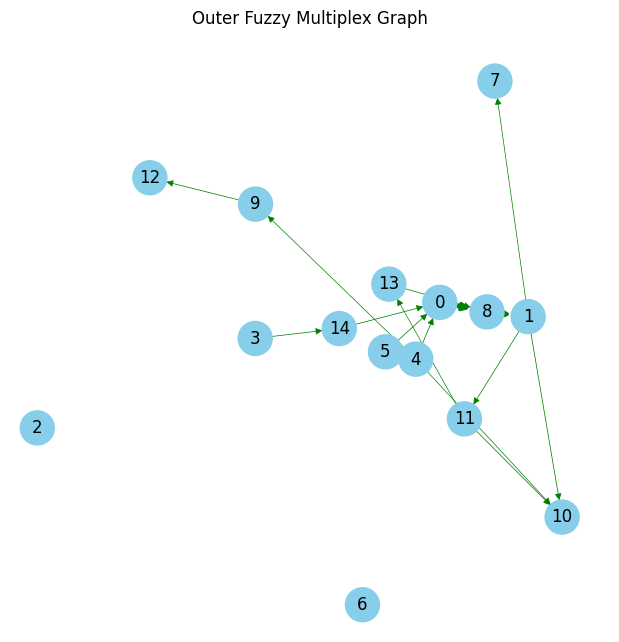

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 15 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.97  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.00  0.00  0.12  0.11  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11 
N 4 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.11  0.00  0.00  0.00  0.00 
N 5 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

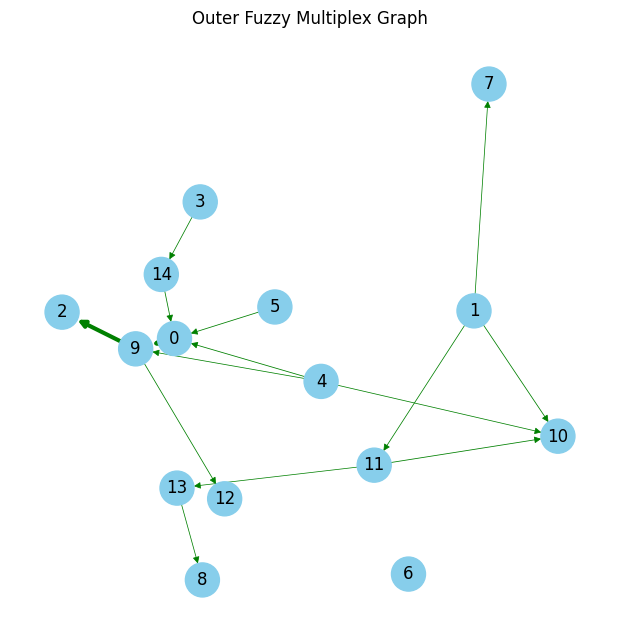

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 15 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  1.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.13  0.12  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12 
N 4 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.12  0.00  0.00  0.00  0.00 
N 5 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

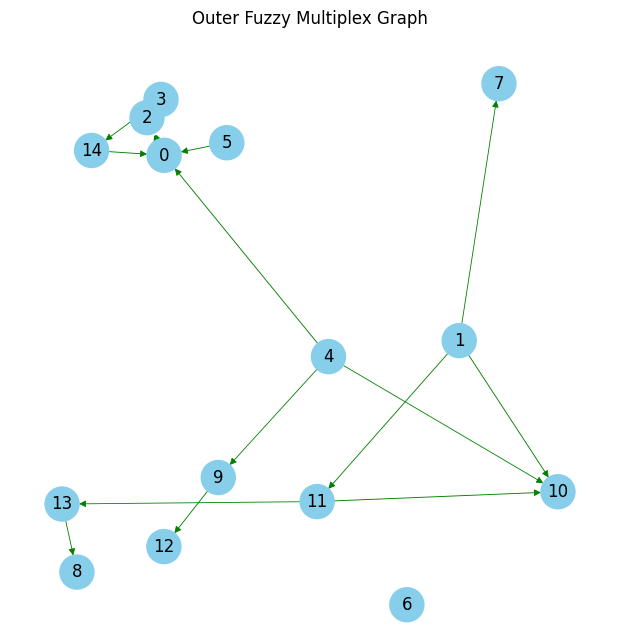

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 15 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.99  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13  0.00  0.00  0.14  0.14  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  1.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.14 
N 4 |  0.14  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13  0.13  0.00  0.00  0.00  0.00 
N 5 |  0.14  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

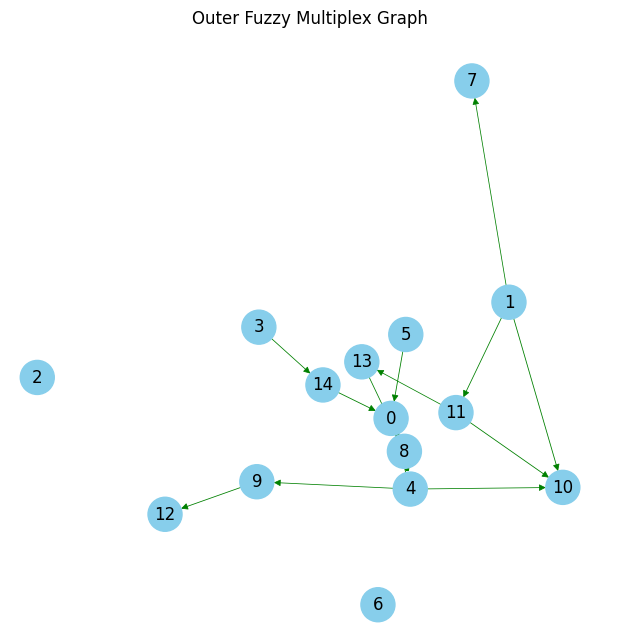

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 15 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  1.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.13  0.13  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13 
N 4 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.12  0.00  0.00  0.00  0.00 
N 5 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

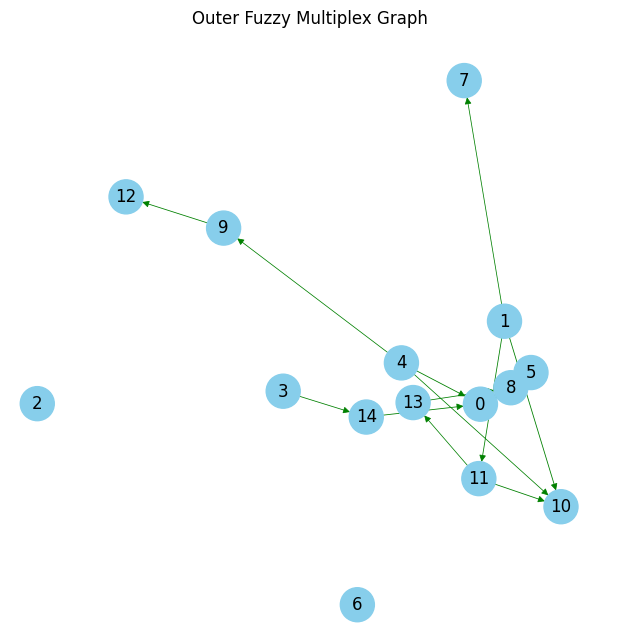

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 15 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  1.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.13  0.13  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13 
N 4 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.12  0.00  0.00  0.00  0.00 
N 5 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

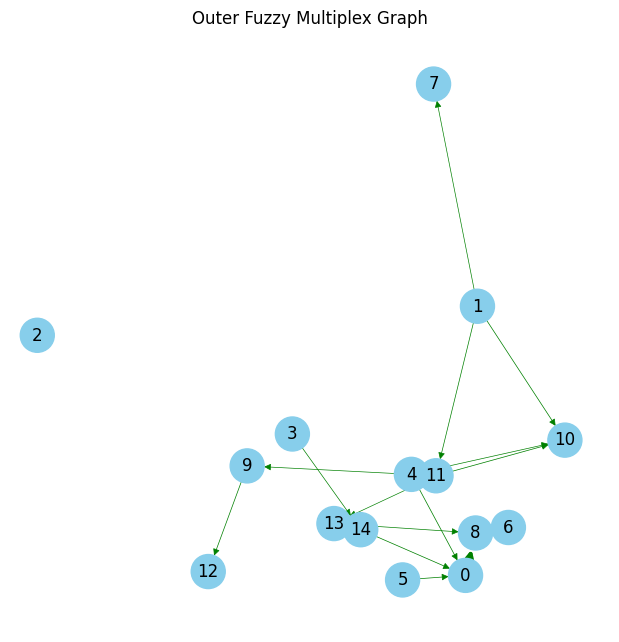

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 15 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.97  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.00  0.00  0.12  0.11  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11 
N 4 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.11  0.00  0.00  0.00  0.00 
N 5 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

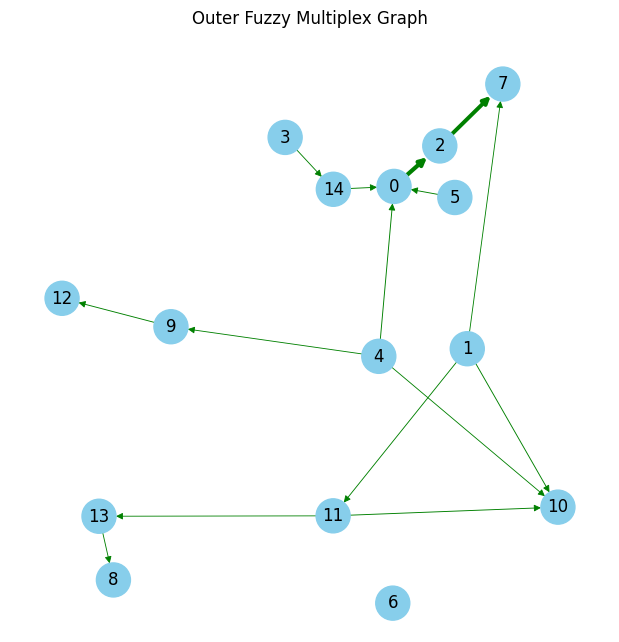

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 15 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  1.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.14  0.00  0.00  0.15  0.14  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.97  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.14 
N 4 |  0.15  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.14  0.14  0.00  0.00  0.00  0.00 
N 5 |  0.15  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

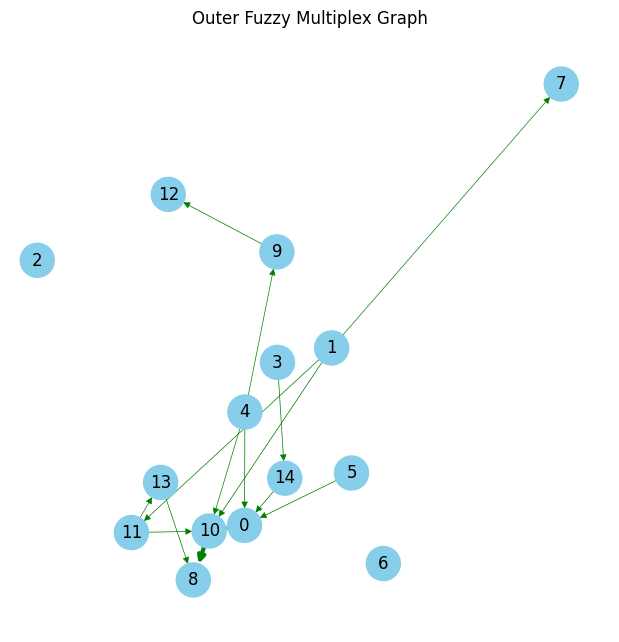

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 15 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.91  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.00  0.00  0.12  0.11  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11 
N 4 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.11  0.00  0.00  0.00  0.00 
N 5 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

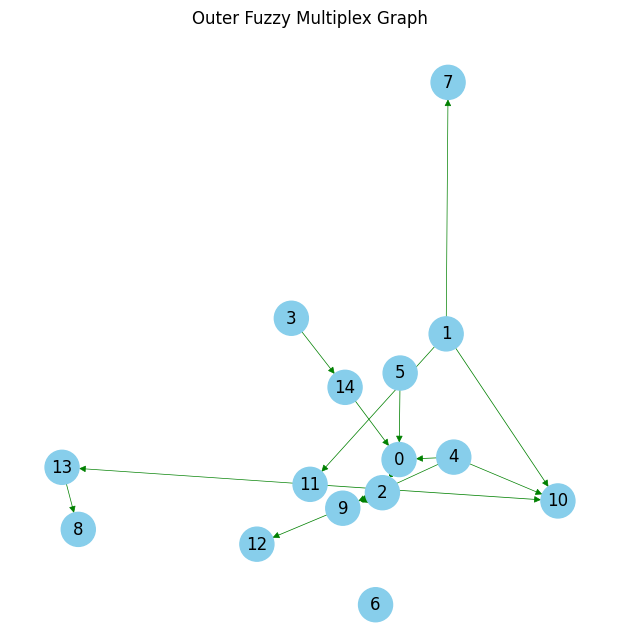

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 15 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.94  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.00  0.00  0.12  0.12  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  1.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12 
N 4 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.11  0.00  0.00  0.00  0.00 
N 5 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

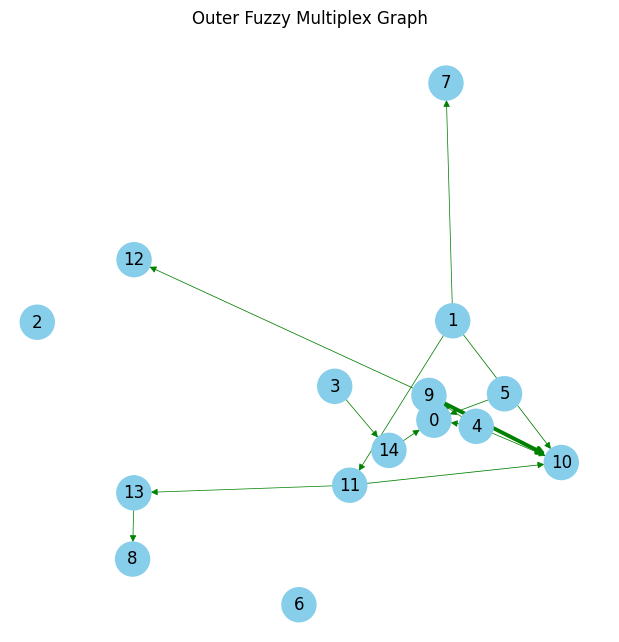

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 15 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  1.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.13  0.12  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12 
N 4 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.12  0.00  0.00  0.00  0.00 
N 5 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

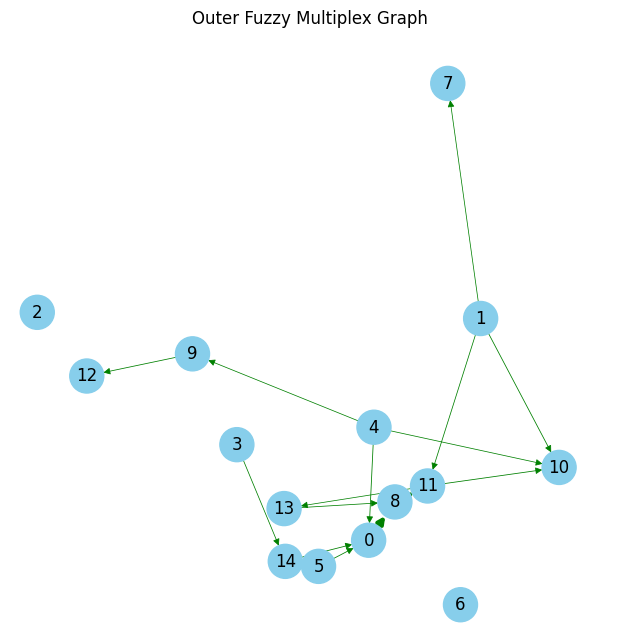

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 15 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.99  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.13  0.12  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12 
N 4 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.12  0.00  0.00  0.00  0.00 
N 5 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

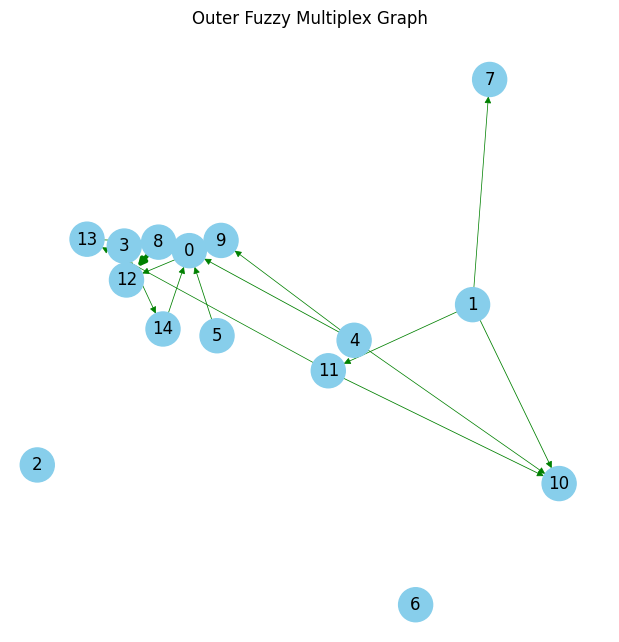

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 15 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.99  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.13  0.12  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12 
N 4 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.12  0.00  0.00  0.00  0.00 
N 5 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

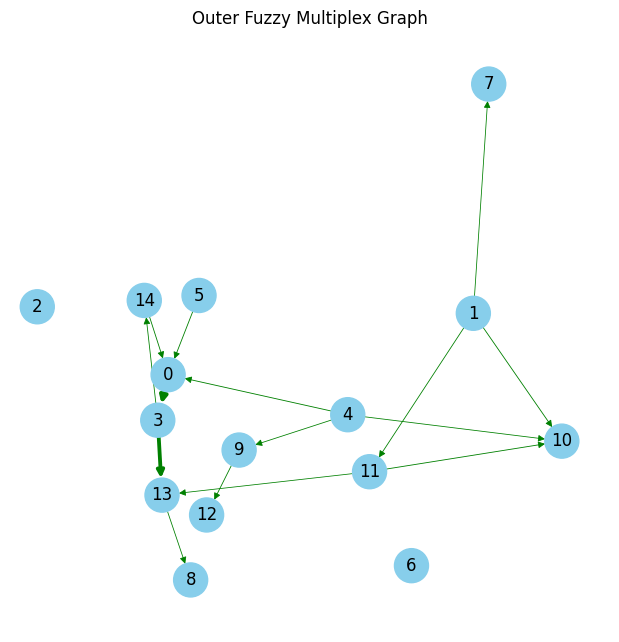

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 15 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  1.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13  0.00  0.00  0.14  0.13  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.94  0.13 
N 4 |  0.14  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13  0.13  0.00  0.00  0.00  0.00 
N 5 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

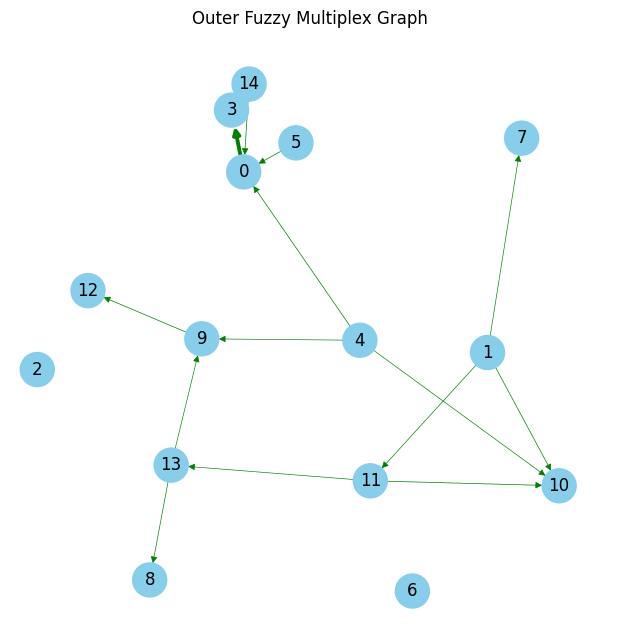

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 15 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.95  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.10  0.00  0.00  0.11  0.11  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  1.00 
N 4 |  0.11  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.10  0.10  0.00  0.00  0.00  0.00 
N 5 |  0.11  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

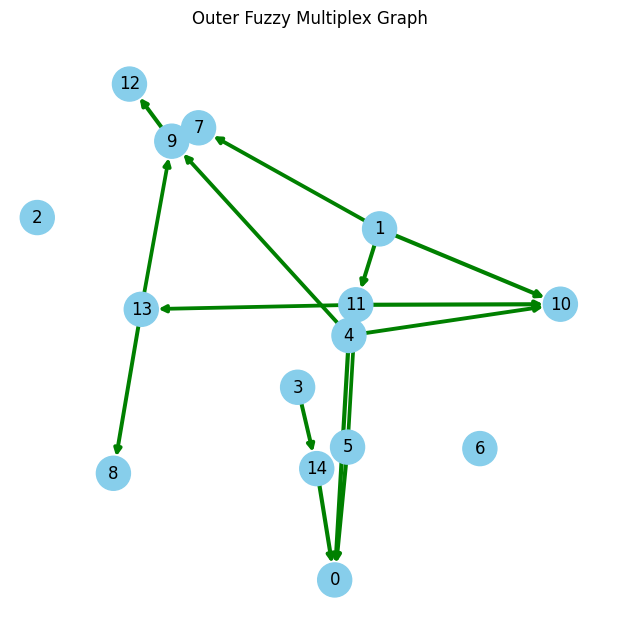

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 16 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.92  0.00  0.00  0.99  0.96  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.95 
N 4 |  1.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.93  0.93  0.00  0.00  0.00  0.00 
N 5 |  0.99  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.89  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

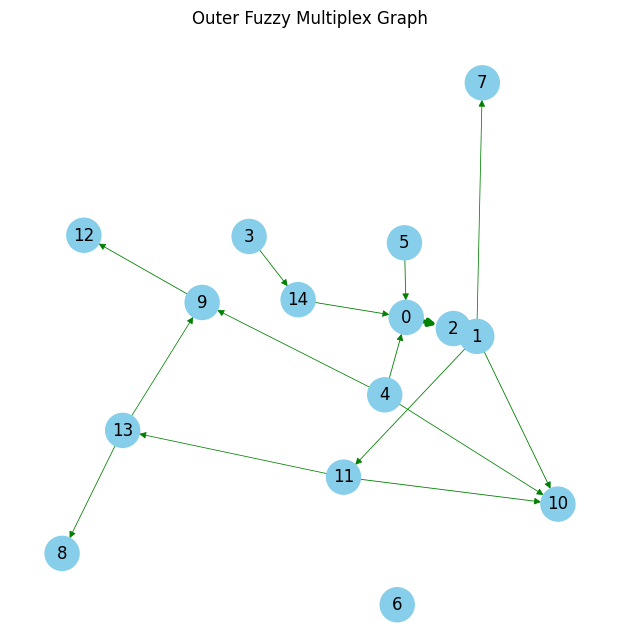

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 16 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.97  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.13  0.13  0.00  0.00  0.00 
N 2 |  0.00  1.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13 
N 4 |  0.14  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13  0.13  0.00  0.00  0.00  0.00 
N 5 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

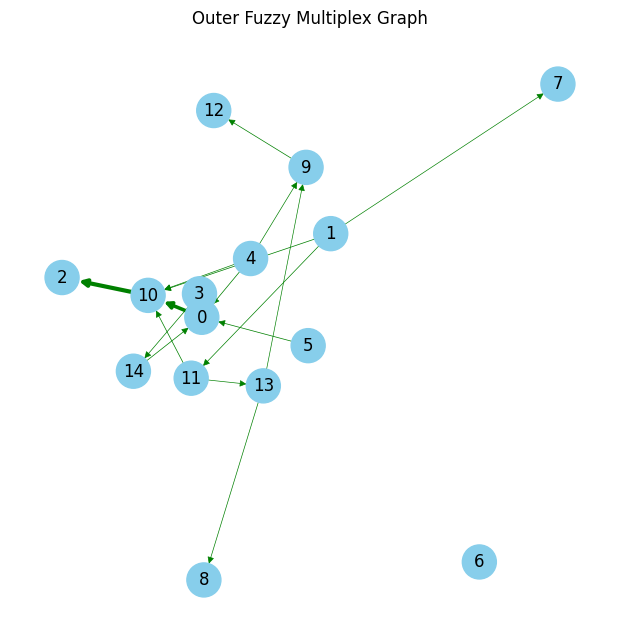

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 16 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.90  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.00  0.00  0.12  0.11  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11 
N 4 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.11  0.00  0.00  0.00  0.00 
N 5 |  0.11  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

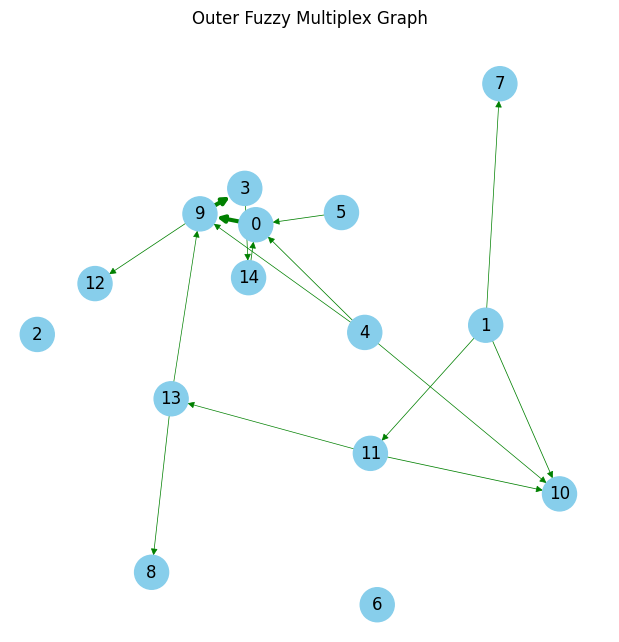

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 16 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.99  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.00  0.00  0.12  0.12  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12 
N 4 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.11  0.00  0.00  0.00  0.00 
N 5 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

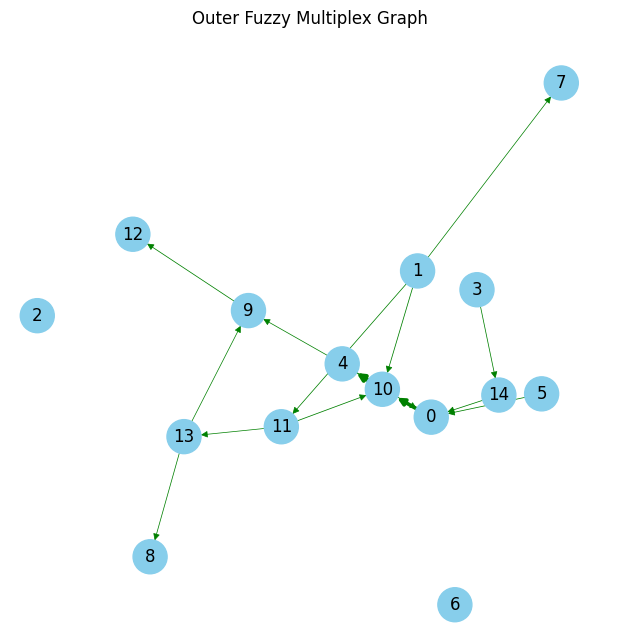

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 16 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.92  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.12  0.12  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12 
N 4 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.12  0.00  0.00  0.00  0.00 
N 5 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

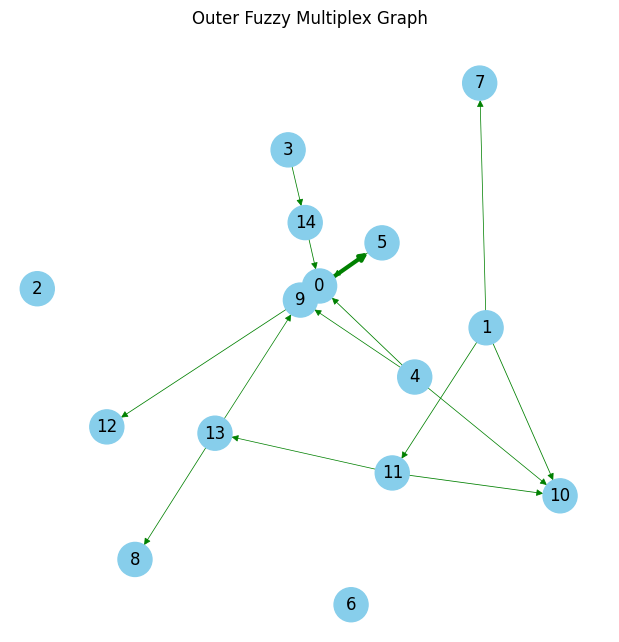

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 16 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  1.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.13  0.12  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12 
N 4 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.12  0.00  0.00  0.00  0.00 
N 5 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

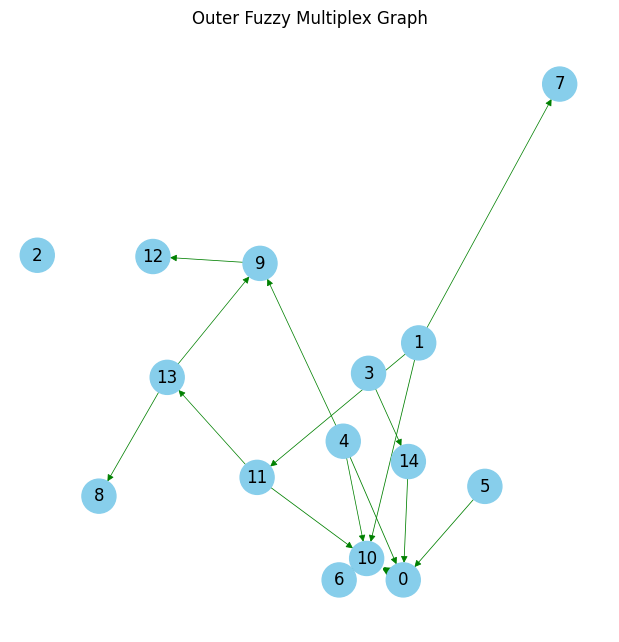

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 16 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.92  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.13  0.12  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12 
N 4 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.12  0.00  0.00  0.00  0.00 
N 5 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

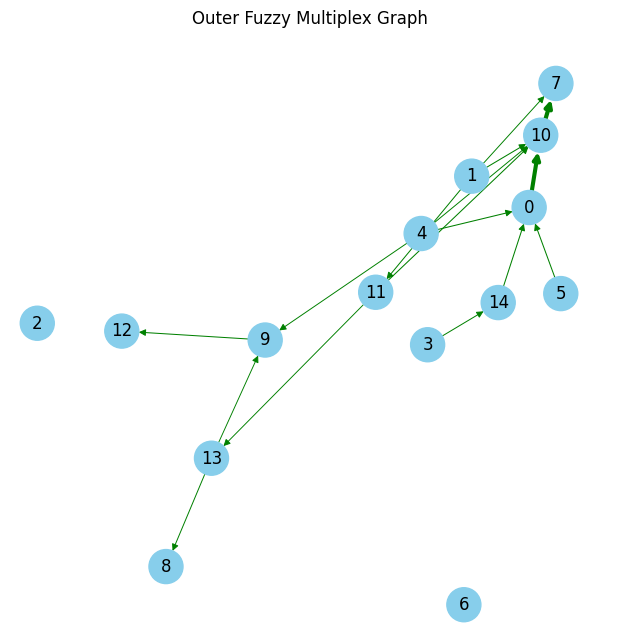

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 16 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.99  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.15  0.00  0.00  0.17  0.16  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.16 
N 4 |  0.17  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.15  0.16  0.00  0.00  0.00  0.00 
N 5 |  0.16  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

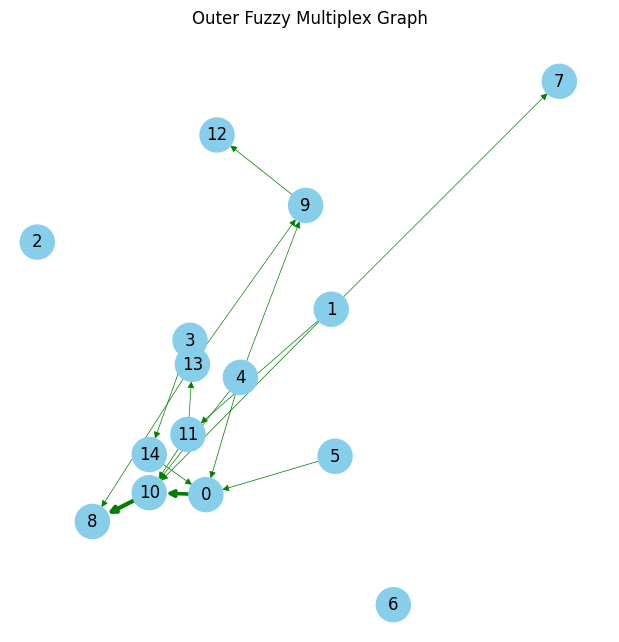

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 16 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.91  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.00  0.00  0.12  0.11  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11 
N 4 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.11  0.00  0.00  0.00  0.00 
N 5 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

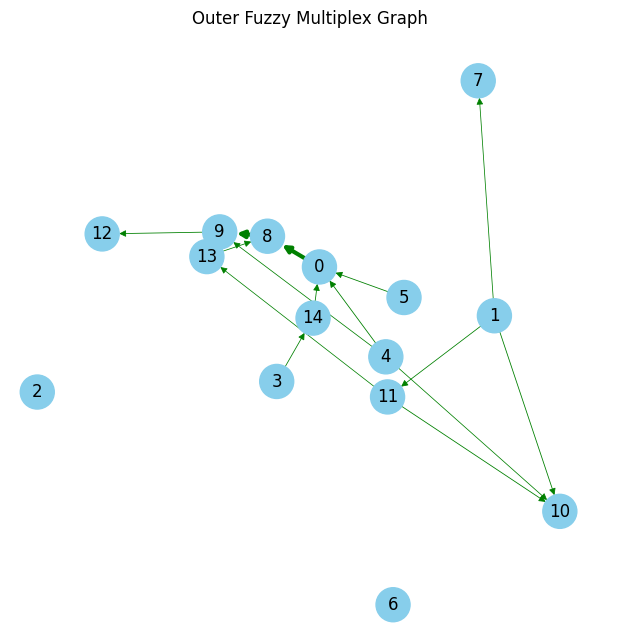

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 16 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  1.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.13  0.13  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13 
N 4 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.12  0.00  0.00  0.00  0.00 
N 5 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

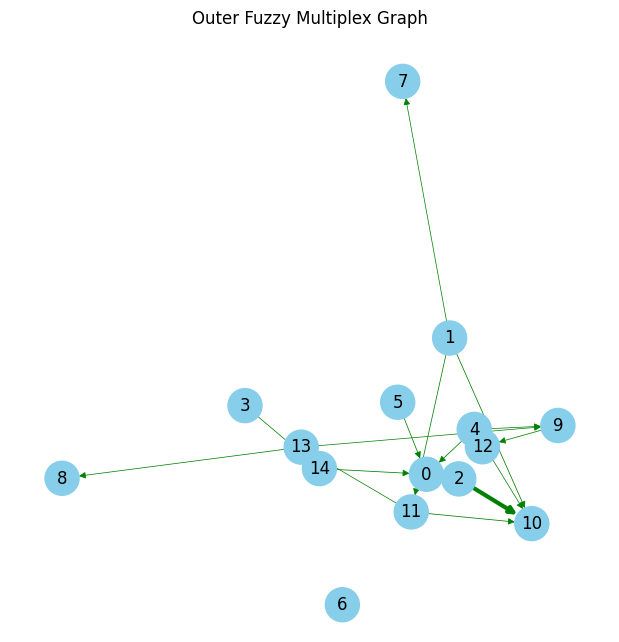

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 16 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.95  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.00  0.00  0.12  0.12  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  1.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12 
N 4 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.12  0.00  0.00  0.00  0.00 
N 5 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

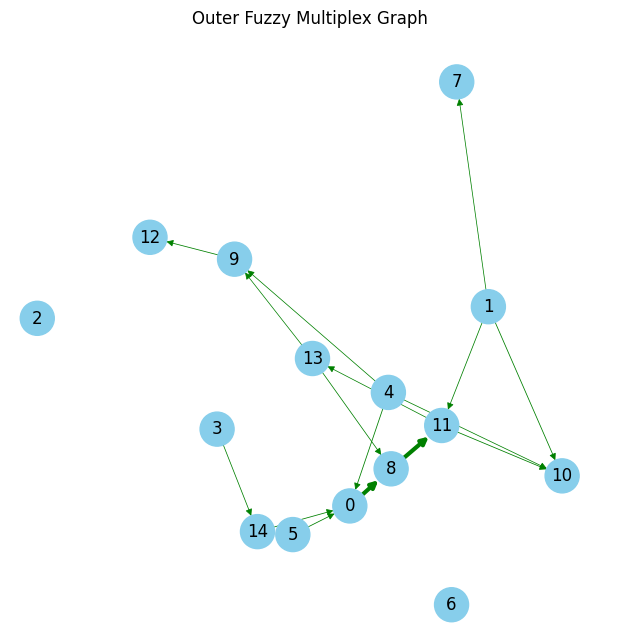

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 16 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.99  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.13  0.12  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12 
N 4 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.12  0.00  0.00  0.00  0.00 
N 5 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

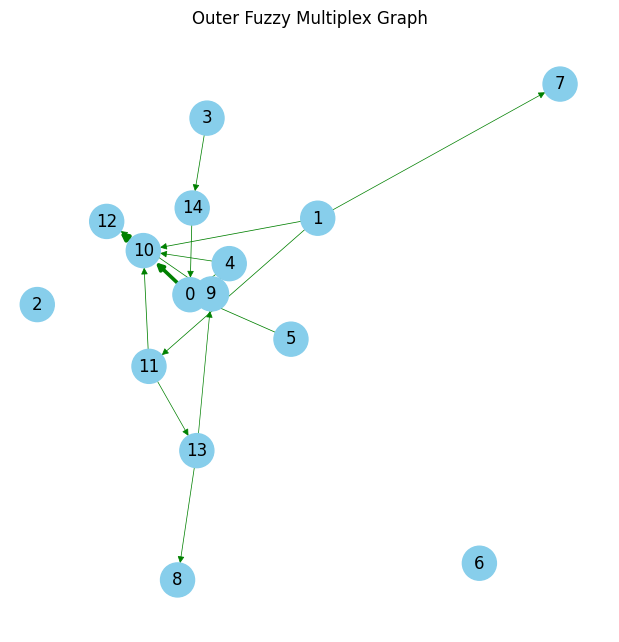

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 16 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.92  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.00  0.00  0.12  0.12  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12 
N 4 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.11  0.00  0.00  0.00  0.00 
N 5 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

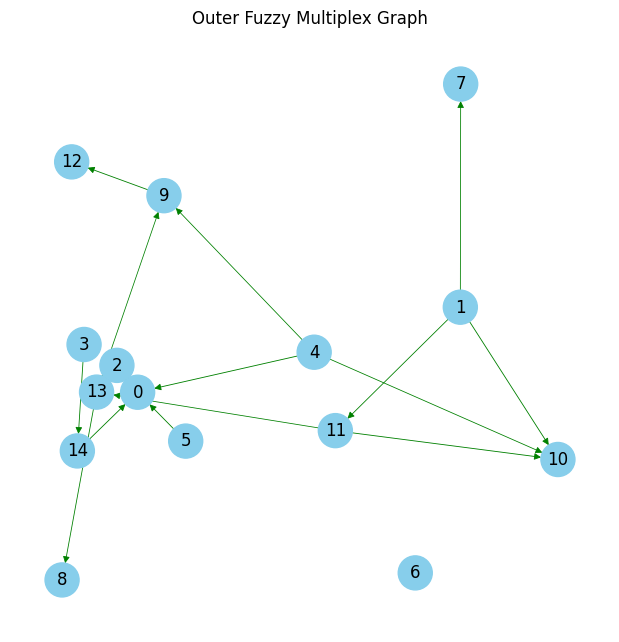

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 16 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.98  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13  0.00  0.00  0.14  0.13  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  1.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13 
N 4 |  0.14  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13  0.13  0.00  0.00  0.00  0.00 
N 5 |  0.14  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

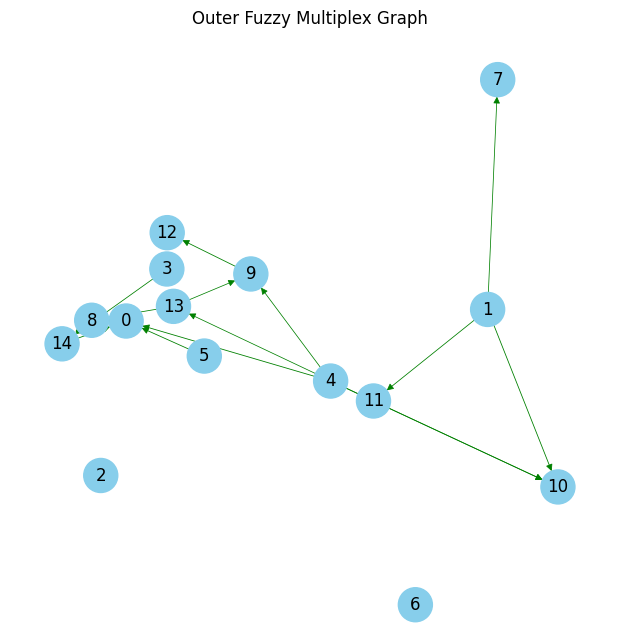

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 16 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  1.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.13  0.13  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13 
N 4 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.12  0.00  0.00  0.00  0.00 
N 5 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

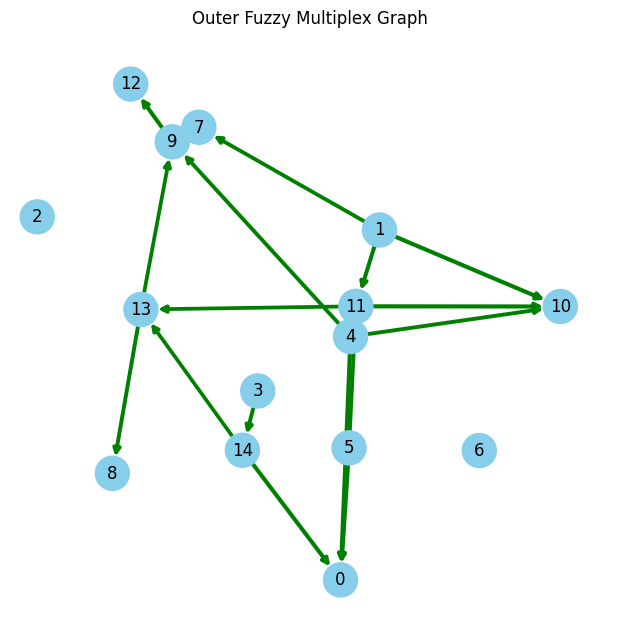

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 17 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.92  0.00  0.00  0.99  0.96  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.95 
N 4 |  1.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.93  0.93  0.00  0.00  0.00  0.00 
N 5 |  0.99  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.89  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

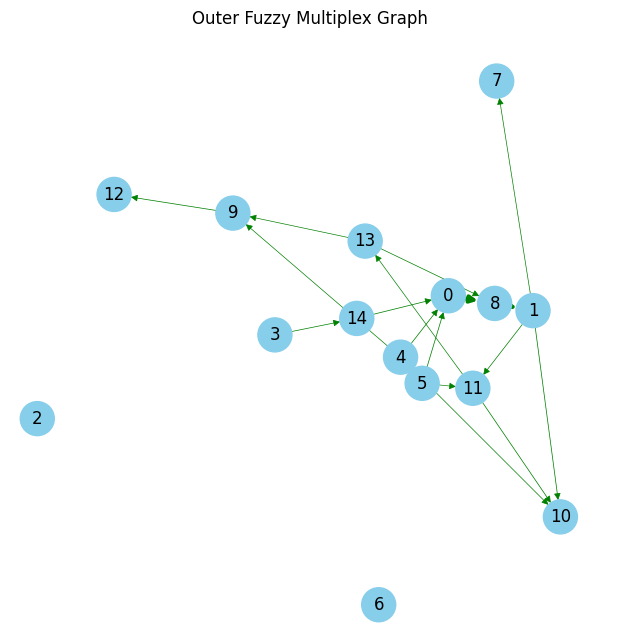

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 17 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.97  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.00  0.00  0.12  0.11  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11 
N 4 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.11  0.00  0.00  0.00  0.00 
N 5 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

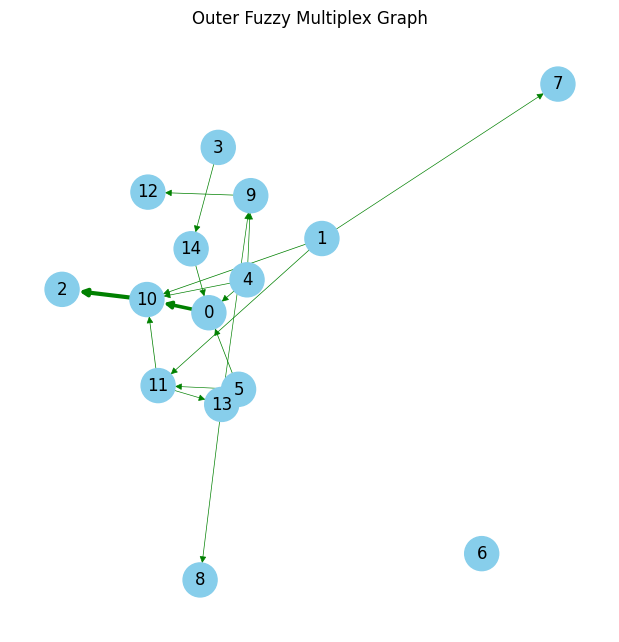

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 17 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.90  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.00  0.00  0.12  0.11  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11 
N 4 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.11  0.00  0.00  0.00  0.00 
N 5 |  0.11  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.10  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

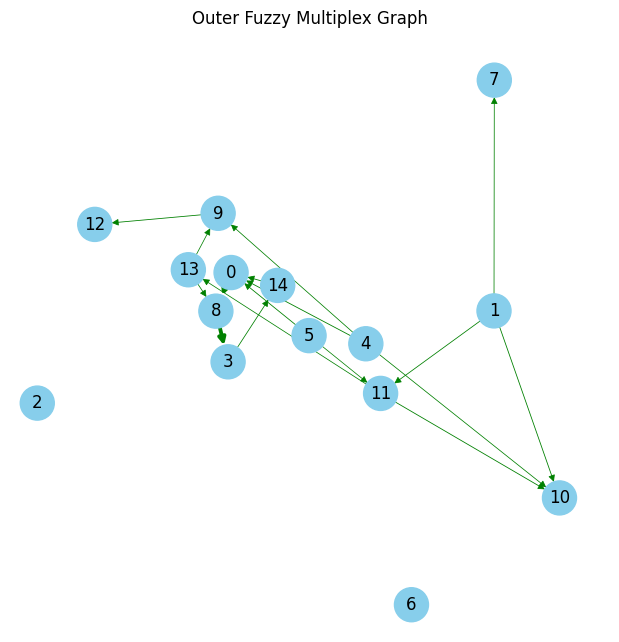

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 17 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  1.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.13  0.13  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13 
N 4 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.12  0.00  0.00  0.00  0.00 
N 5 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

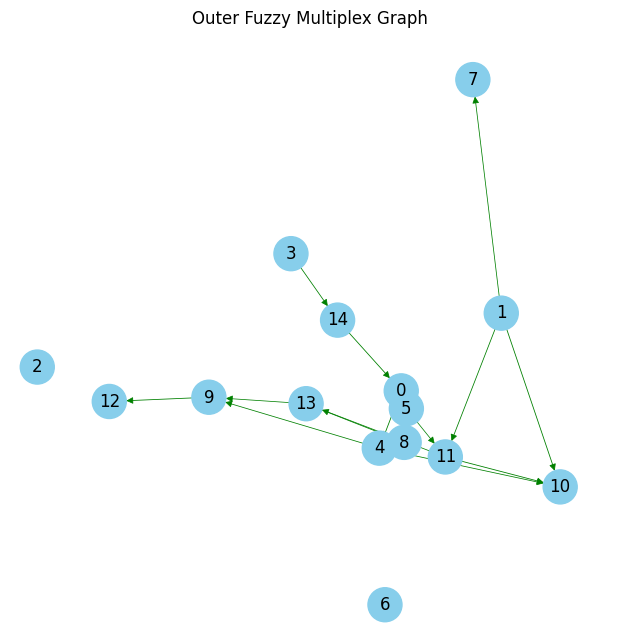

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 17 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  1.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.13  0.13  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13 
N 4 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.12  0.00  0.00  0.00  0.00 
N 5 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

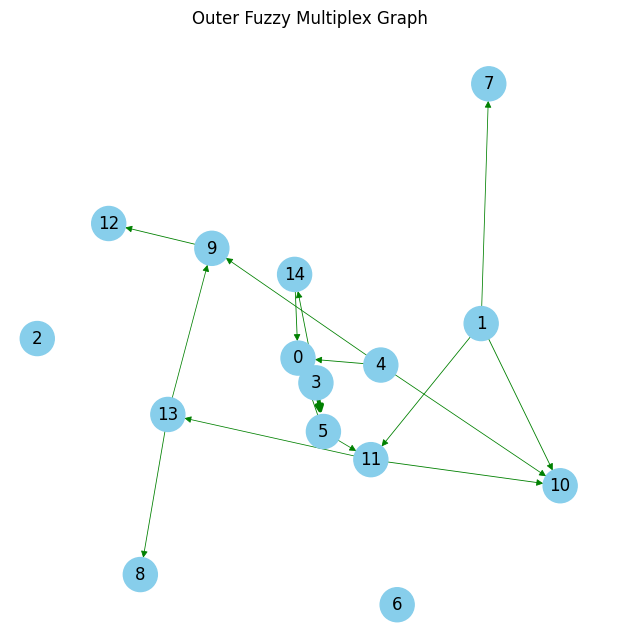

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 17 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  1.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13  0.00  0.00  0.14  0.13  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.97  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13 
N 4 |  0.14  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13  0.13  0.00  0.00  0.00  0.00 
N 5 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

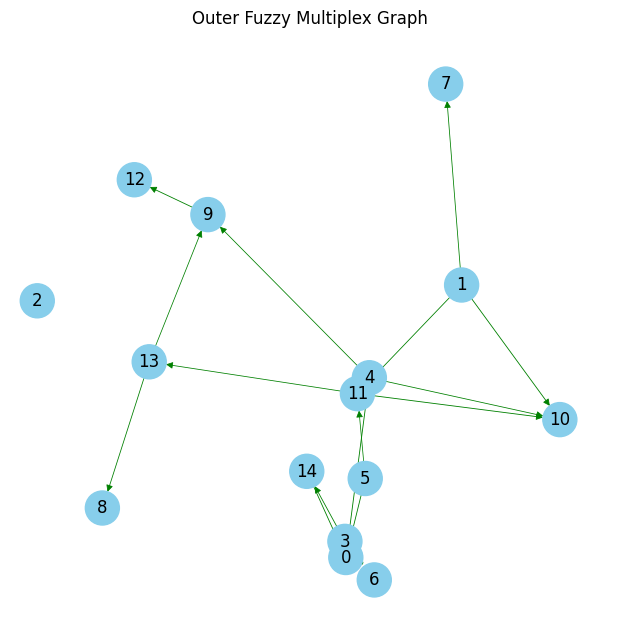

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 17 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  1.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13  0.00  0.00  0.14  0.13  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.99  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13 
N 4 |  0.14  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13  0.13  0.00  0.00  0.00  0.00 
N 5 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

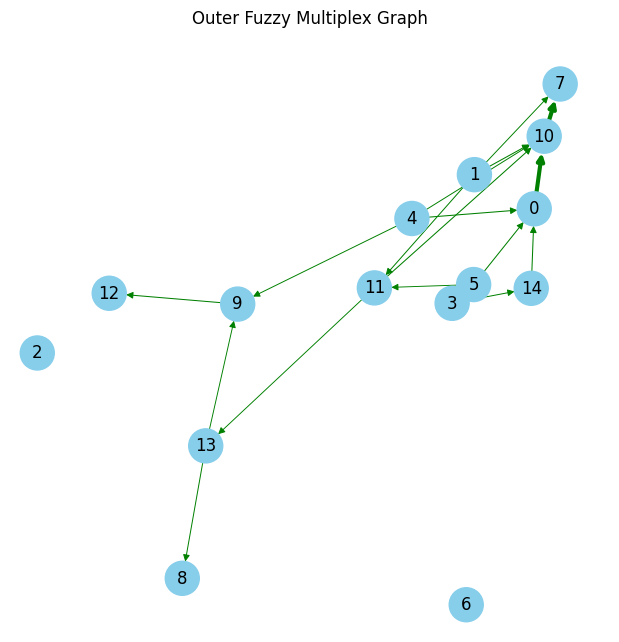

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 17 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.99  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.15  0.00  0.00  0.17  0.16  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.16 
N 4 |  0.17  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.15  0.16  0.00  0.00  0.00  0.00 
N 5 |  0.16  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.15  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

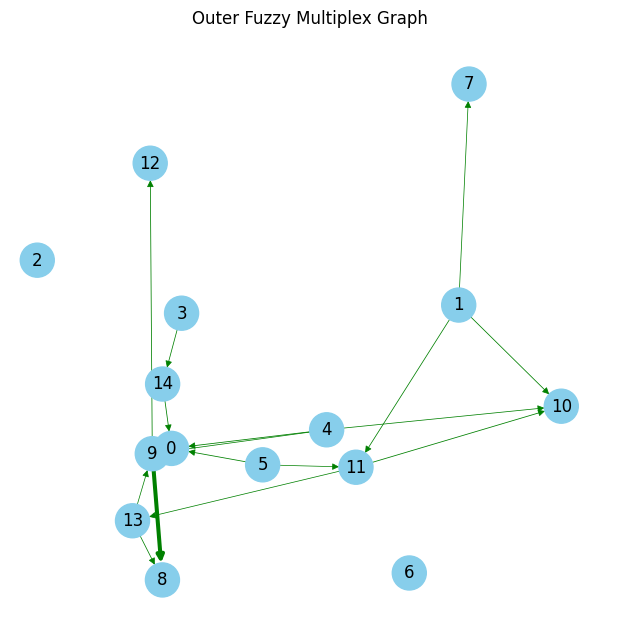

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 17 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  1.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.13  0.12  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12 
N 4 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.12  0.00  0.00  0.00  0.00 
N 5 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

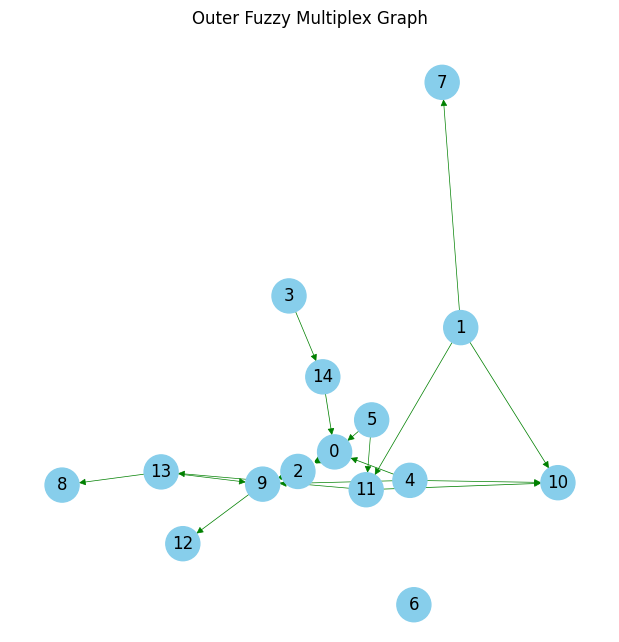

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 17 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.94  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.00  0.00  0.12  0.12  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  1.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12 
N 4 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.11  0.00  0.00  0.00  0.00 
N 5 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

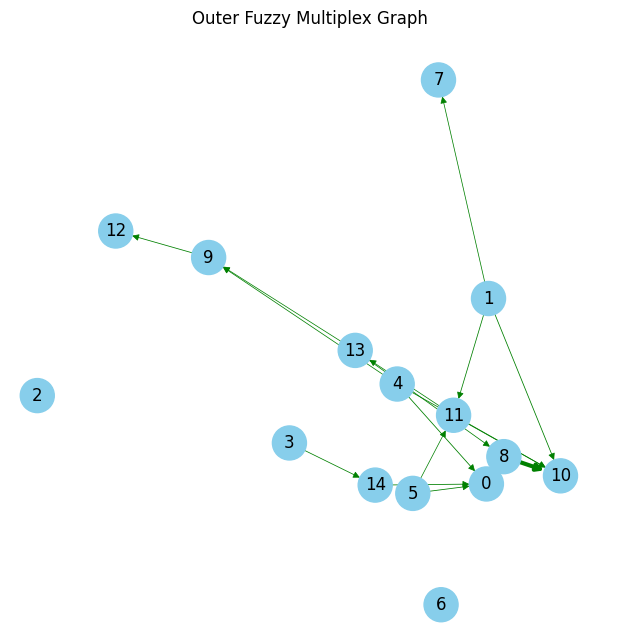

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 17 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.99  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.13  0.12  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12 
N 4 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.12  0.00  0.00  0.00  0.00 
N 5 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

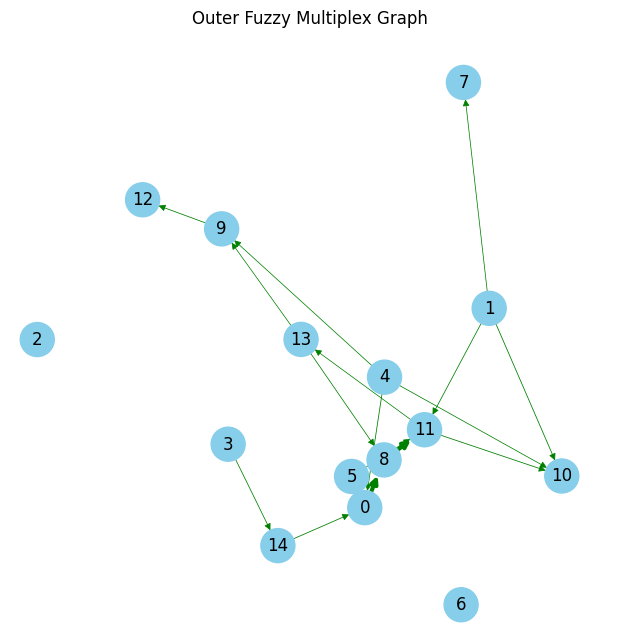

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 17 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.99  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.13  0.12  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12 
N 4 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.12  0.00  0.00  0.00  0.00 
N 5 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

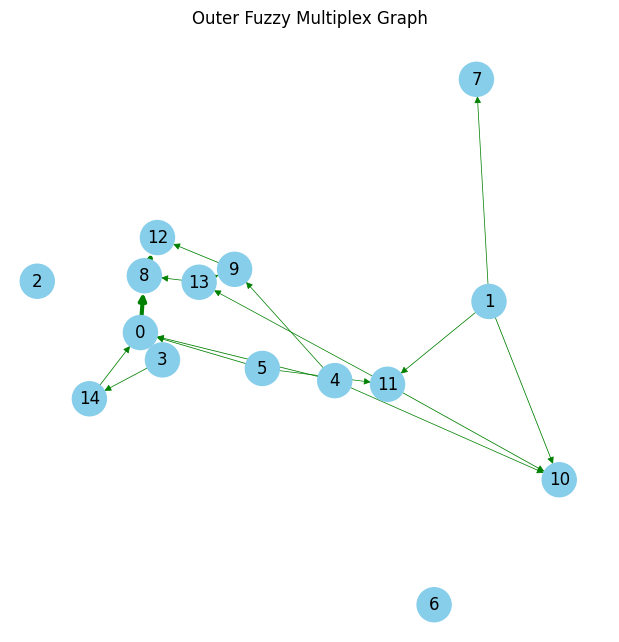

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 17 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.99  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.13  0.12  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12 
N 4 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.12  0.00  0.00  0.00  0.00 
N 5 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

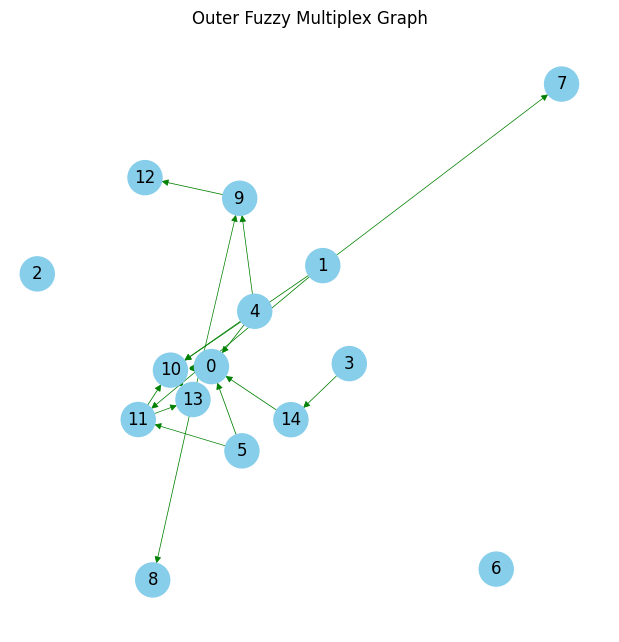

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 17 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.92  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.13  0.12  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12 
N 4 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.12  0.00  0.00  0.00  0.00 
N 5 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

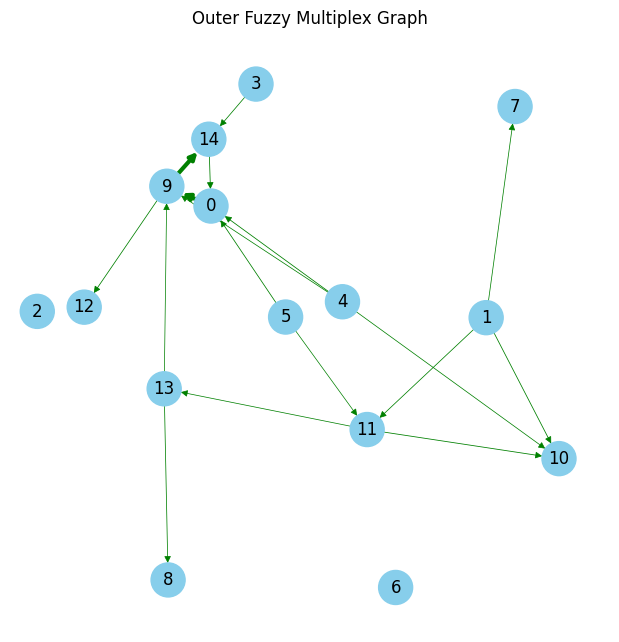

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 17 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  1.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.13  0.12  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12 
N 4 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.12  0.00  0.00  0.00  0.00 
N 5 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

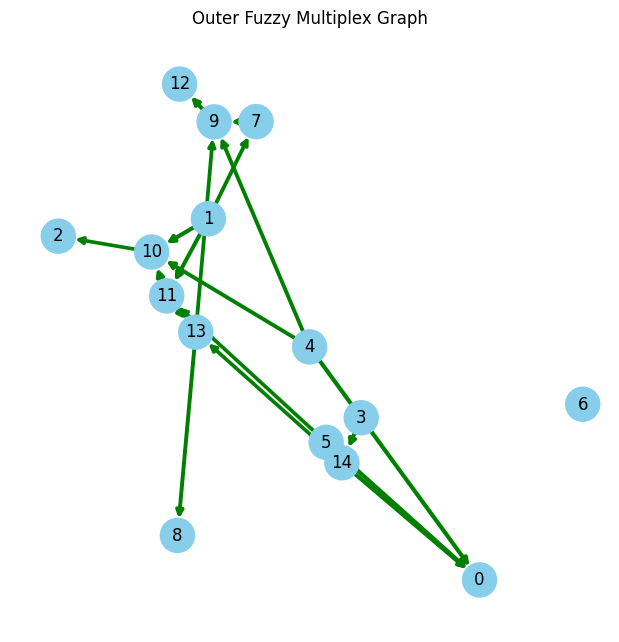

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 18 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.92  0.00  0.00  0.99  0.96  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.95 
N 4 |  1.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.93  0.93  0.00  0.00  0.00  0.00 
N 5 |  0.99  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.89  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

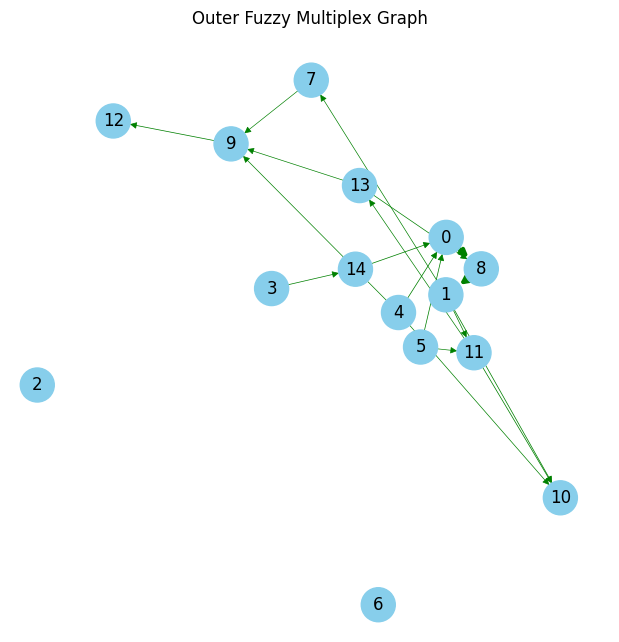

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 18 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.97  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.00  0.00  0.12  0.11  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11 
N 4 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.11  0.00  0.00  0.00  0.00 
N 5 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

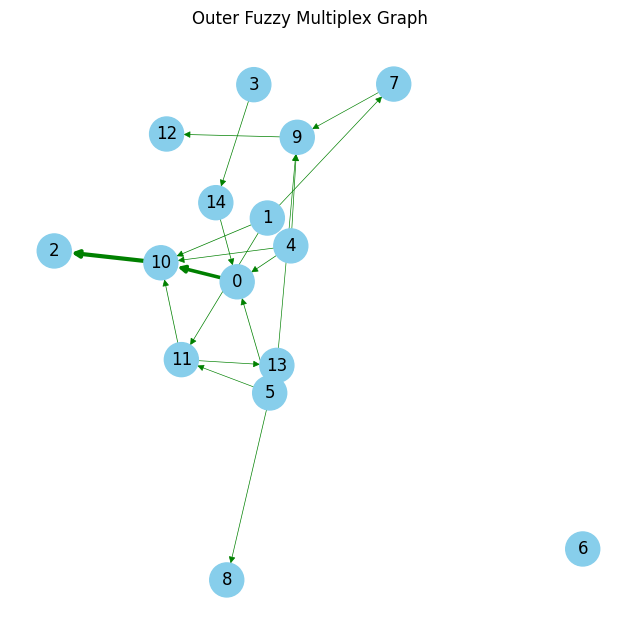

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 18 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.90  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.00  0.00  0.12  0.11  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11 
N 4 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.11  0.00  0.00  0.00  0.00 
N 5 |  0.11  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.10  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

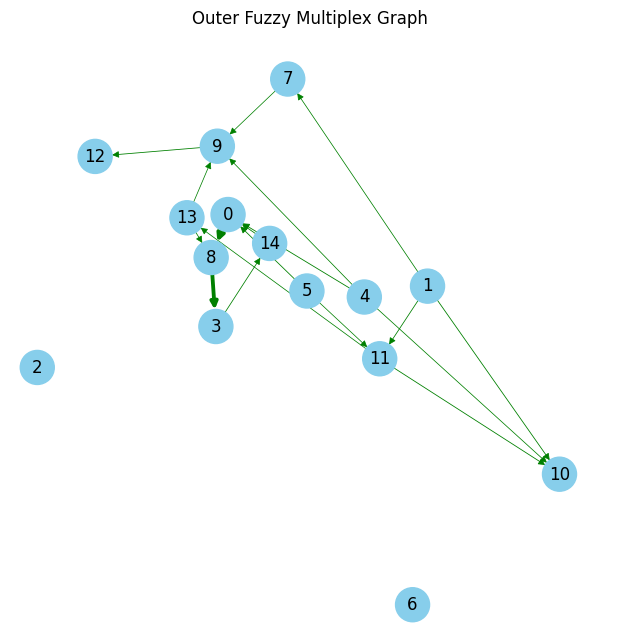

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 18 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  1.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.13  0.13  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13 
N 4 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.12  0.00  0.00  0.00  0.00 
N 5 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

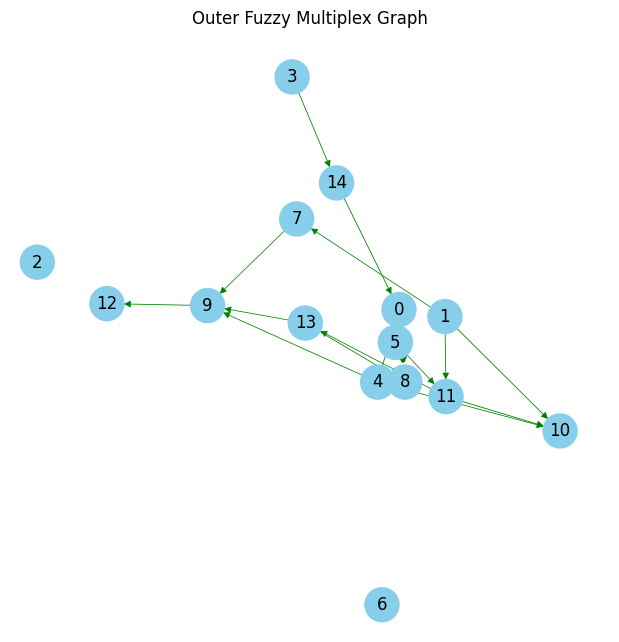

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 18 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  1.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.13  0.13  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13 
N 4 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.12  0.00  0.00  0.00  0.00 
N 5 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

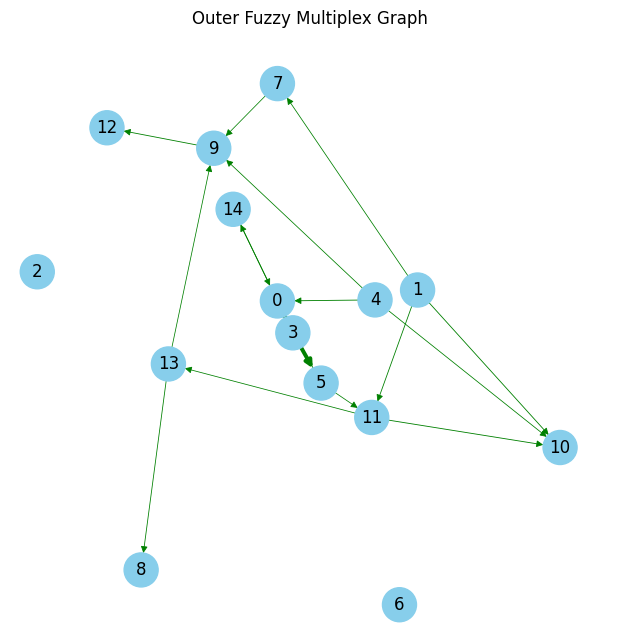

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 18 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  1.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13  0.00  0.00  0.14  0.13  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.97  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13 
N 4 |  0.14  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13  0.13  0.00  0.00  0.00  0.00 
N 5 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

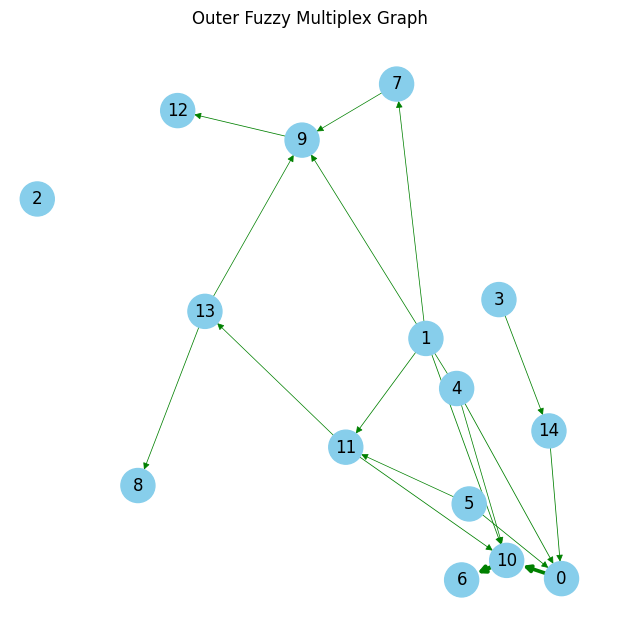

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 18 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.92  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.13  0.12  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12 
N 4 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.12  0.00  0.00  0.00  0.00 
N 5 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

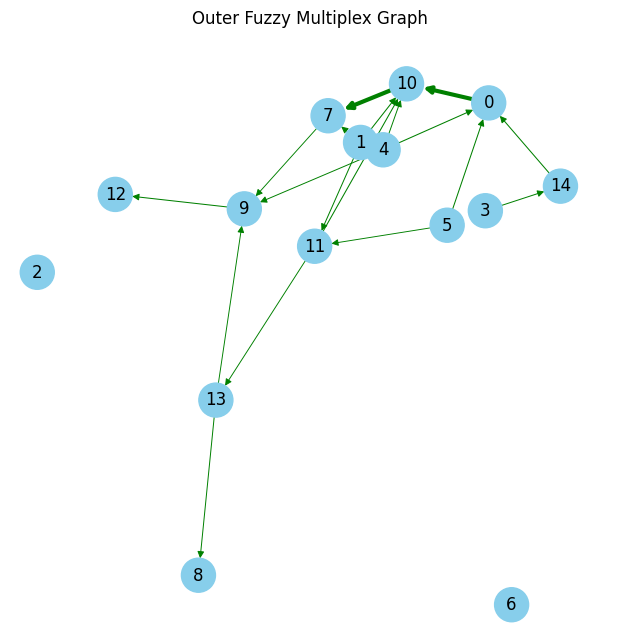

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 18 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.99  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.15  0.00  0.00  0.17  0.16  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.16 
N 4 |  0.17  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.15  0.16  0.00  0.00  0.00  0.00 
N 5 |  0.16  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.15  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

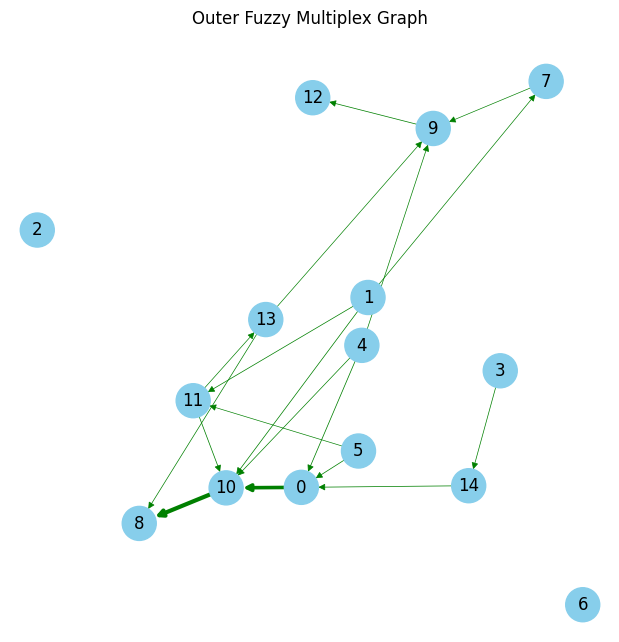

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 18 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.91  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.00  0.00  0.12  0.11  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11 
N 4 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.11  0.00  0.00  0.00  0.00 
N 5 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

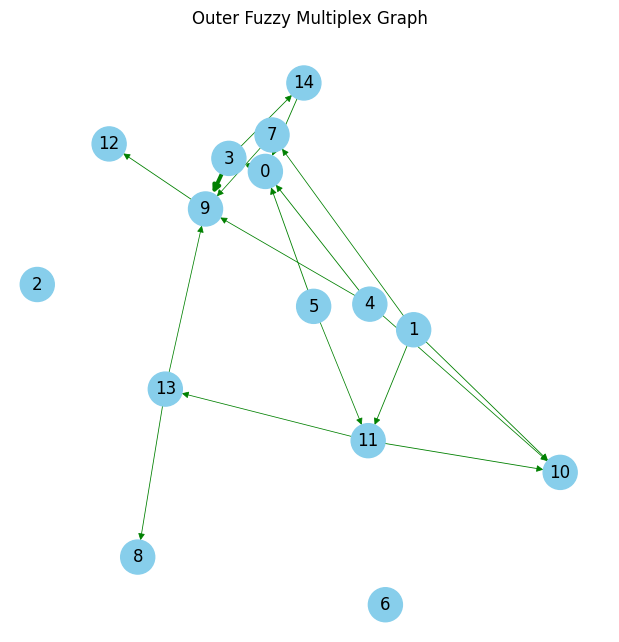

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 18 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  1.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13  0.00  0.00  0.14  0.13  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.96  0.00  0.00  0.00  0.00  0.13 
N 4 |  0.14  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13  0.13  0.00  0.00  0.00  0.00 
N 5 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

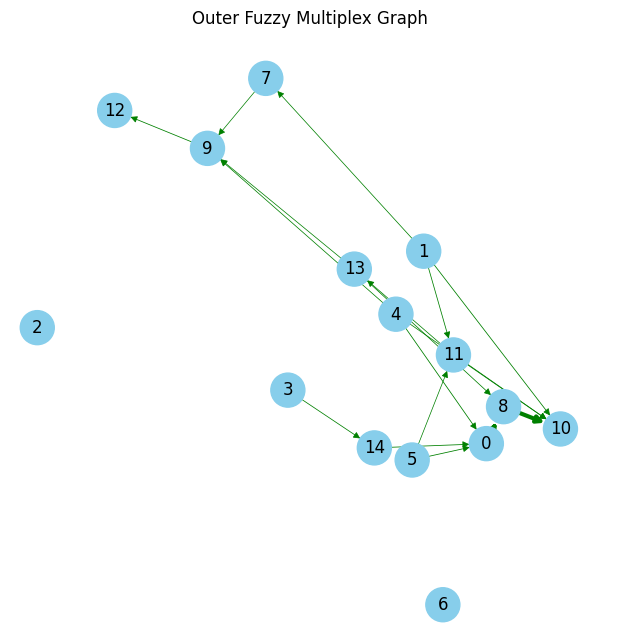

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 18 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.99  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.13  0.12  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12 
N 4 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.12  0.00  0.00  0.00  0.00 
N 5 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

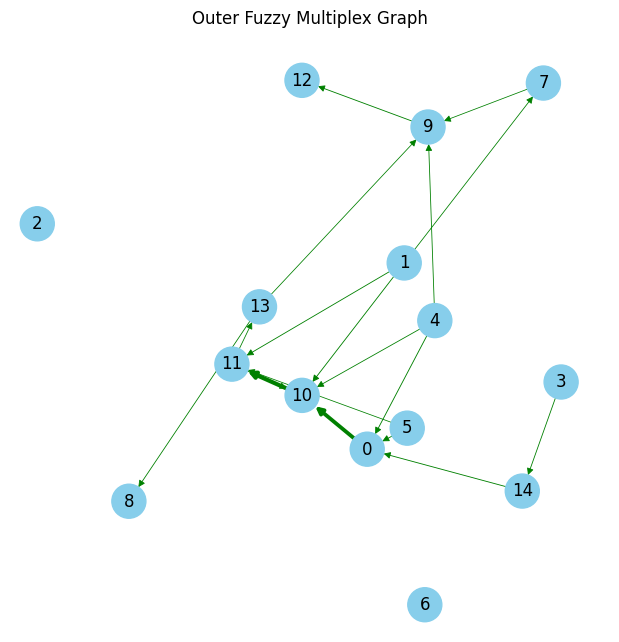

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 18 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.94  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13  0.00  0.00  0.14  0.14  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13 
N 4 |  0.14  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13  0.13  0.00  0.00  0.00  0.00 
N 5 |  0.14  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

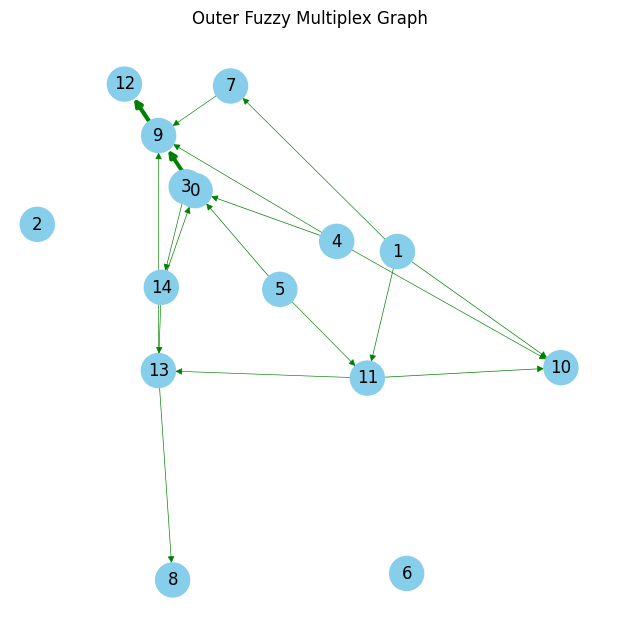

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 18 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.96  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.10  0.00  0.00  0.11  0.11  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11 
N 4 |  0.11  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.10  0.10  0.00  0.00  0.00  0.00 
N 5 |  0.11  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.10  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

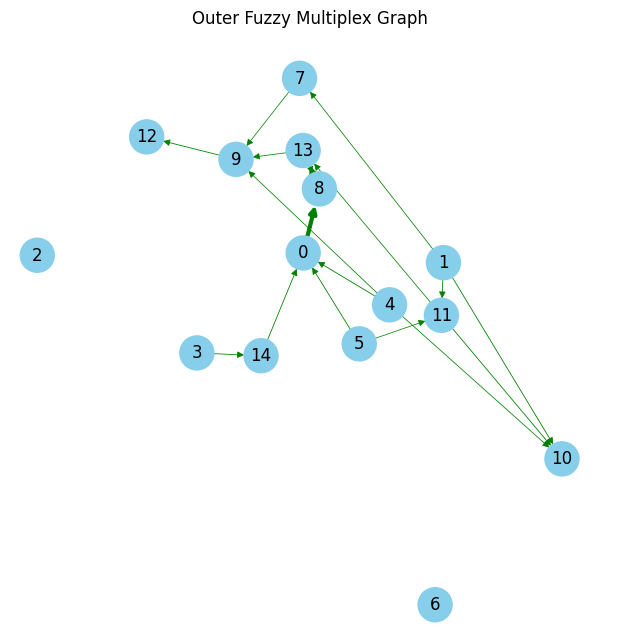

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 18 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  1.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.13  0.13  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13 
N 4 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.12  0.00  0.00  0.00  0.00 
N 5 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

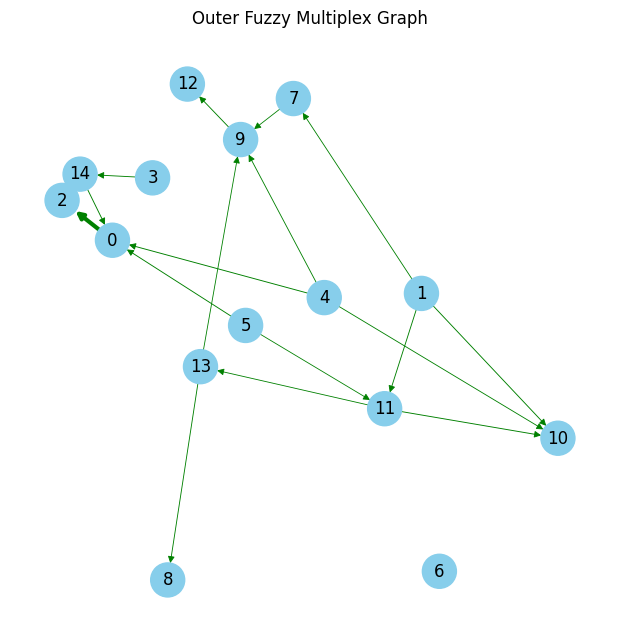

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 18 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  1.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.14  0.00  0.00  0.15  0.14  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.98 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.14 
N 4 |  0.15  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.14  0.14  0.00  0.00  0.00  0.00 
N 5 |  0.15  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

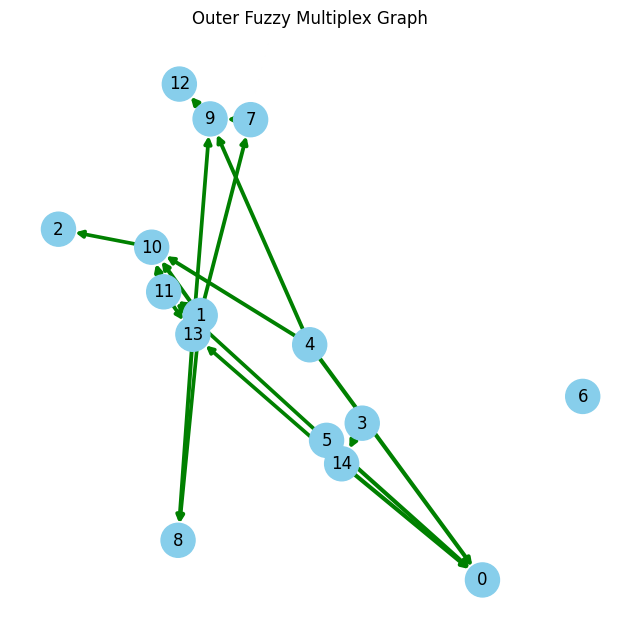

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 19 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.92  0.87  0.00  0.99  0.96  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.95 
N 4 |  1.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.93  0.93  0.00  0.00  0.00  0.00 
N 5 |  0.99  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.89  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

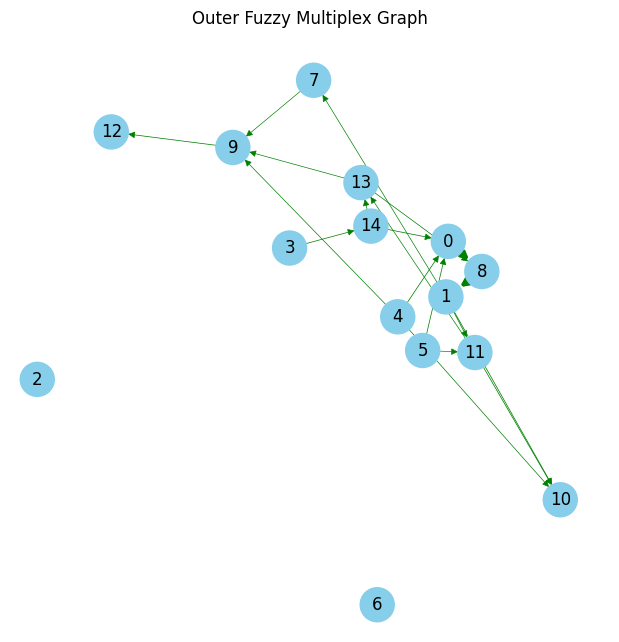

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 19 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.97  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.00  0.00  0.12  0.11  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11 
N 4 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.11  0.00  0.00  0.00  0.00 
N 5 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

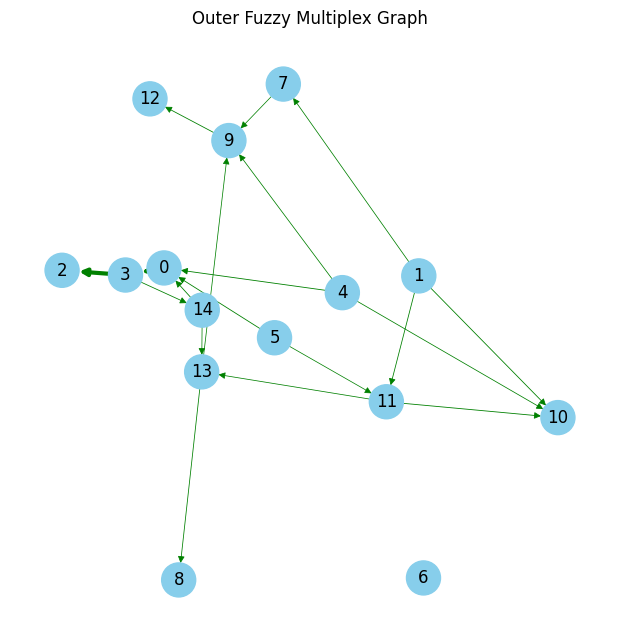

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 19 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.99  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.13  0.13  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  1.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13 
N 4 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.12  0.00  0.00  0.00  0.00 
N 5 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

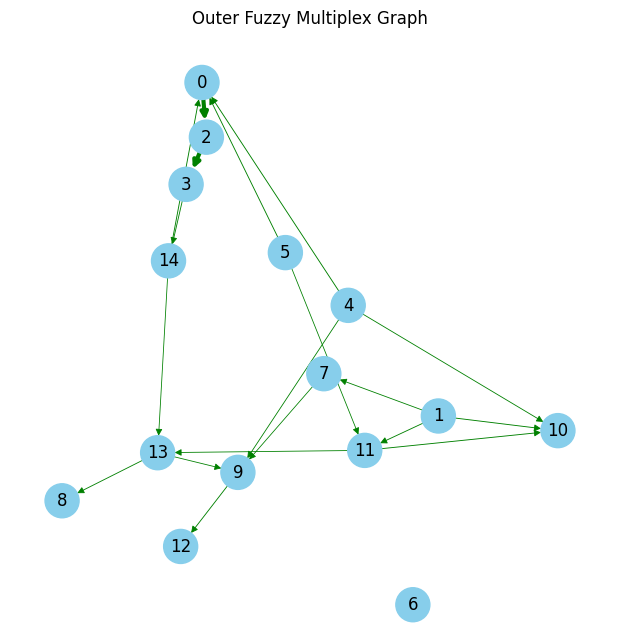

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 19 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.99  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13  0.00  0.00  0.14  0.14  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  1.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.14 
N 4 |  0.14  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13  0.13  0.00  0.00  0.00  0.00 
N 5 |  0.14  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

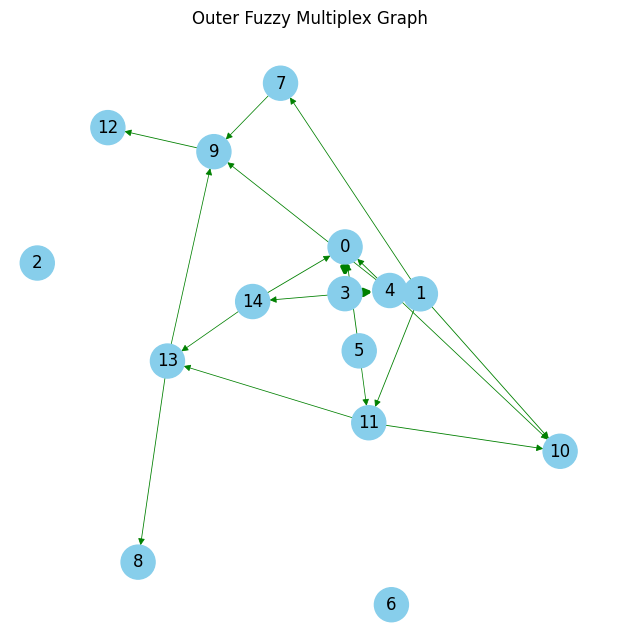

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 19 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  1.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13  0.00  0.00  0.14  0.13  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.96  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13 
N 4 |  0.14  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13  0.13  0.00  0.00  0.00  0.00 
N 5 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

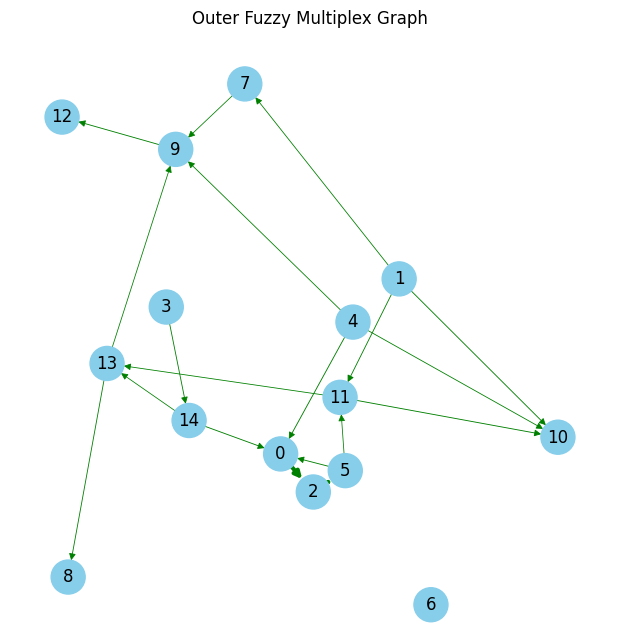

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 19 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.99  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13  0.00  0.00  0.14  0.14  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  1.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.14 
N 4 |  0.14  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13  0.13  0.00  0.00  0.00  0.00 
N 5 |  0.14  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

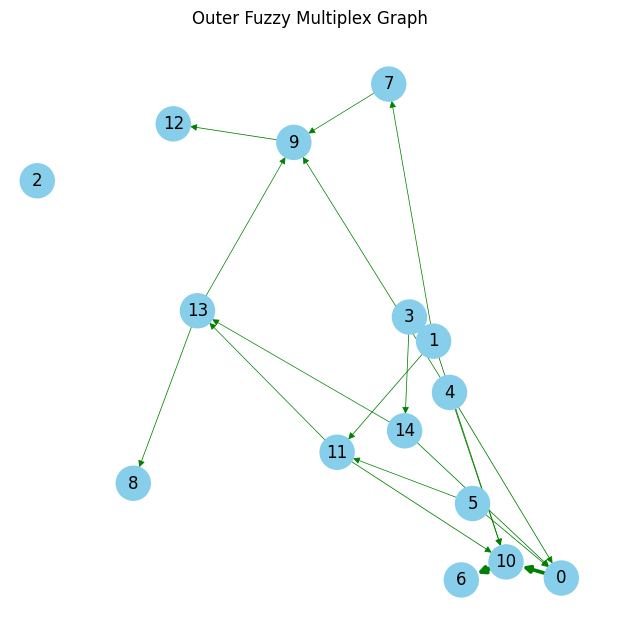

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 19 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.92  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.13  0.12  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12 
N 4 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.12  0.00  0.00  0.00  0.00 
N 5 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

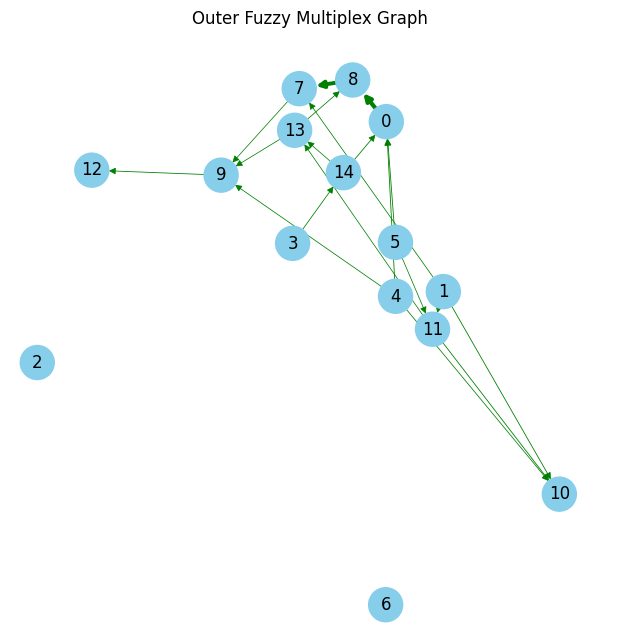

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 19 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  1.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.13  0.13  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13 
N 4 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.12  0.00  0.00  0.00  0.00 
N 5 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

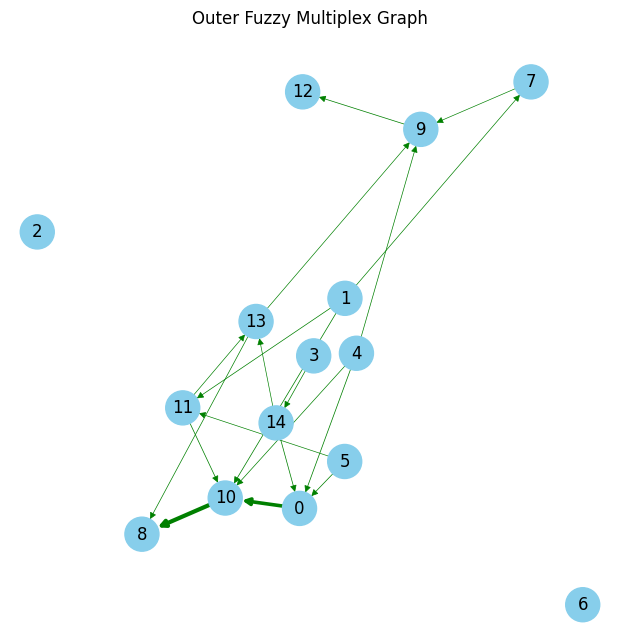

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 19 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.91  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.00  0.00  0.12  0.11  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11 
N 4 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.11  0.00  0.00  0.00  0.00 
N 5 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

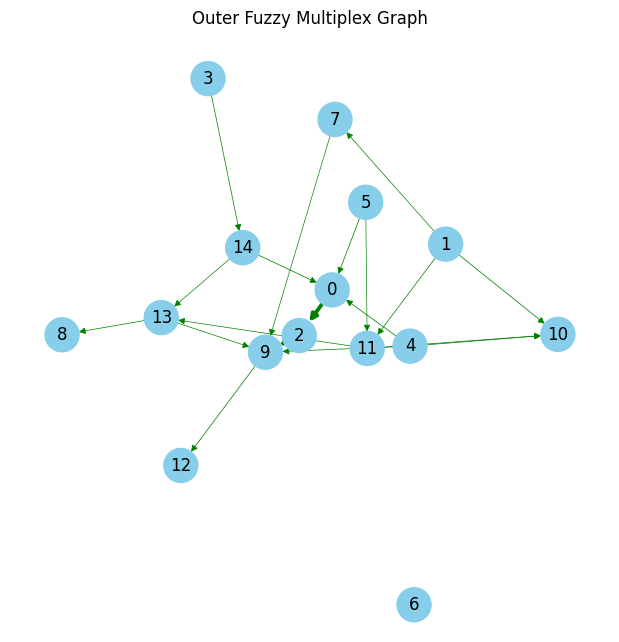

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 19 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.94  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.00  0.00  0.12  0.12  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  1.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12 
N 4 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.11  0.00  0.00  0.00  0.00 
N 5 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

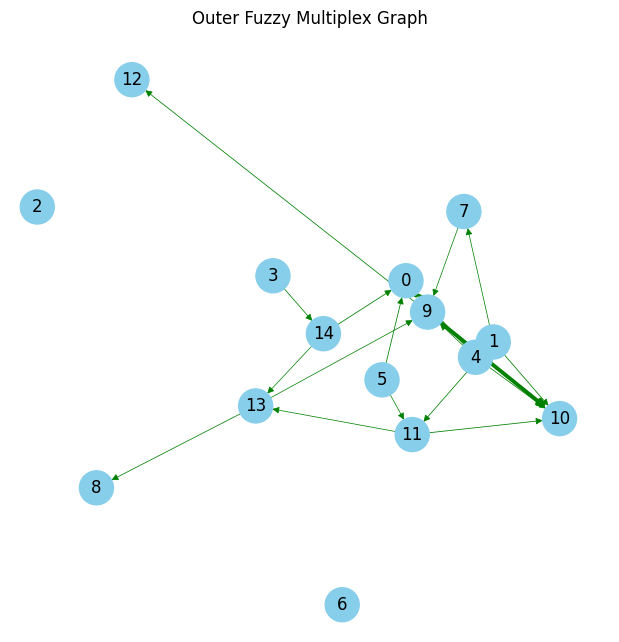

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 19 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  1.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.13  0.12  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12 
N 4 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.12  0.00  0.00  0.00  0.00 
N 5 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

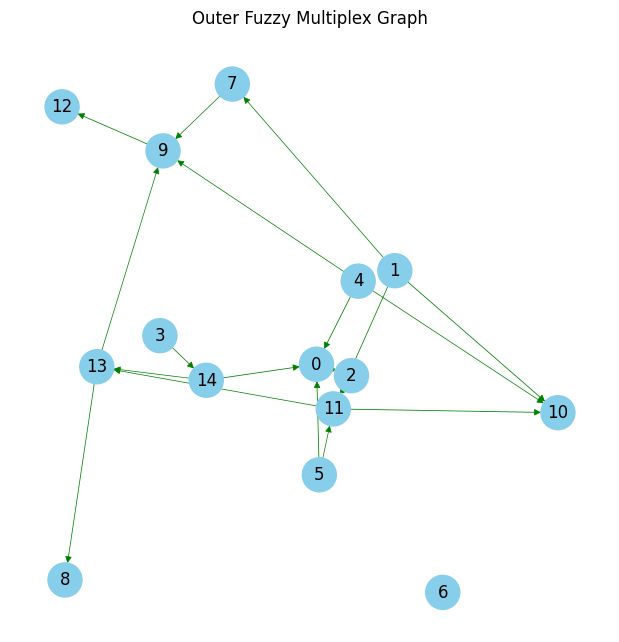

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 19 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.96  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.13  0.12  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  1.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12 
N 4 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.12  0.00  0.00  0.00  0.00 
N 5 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

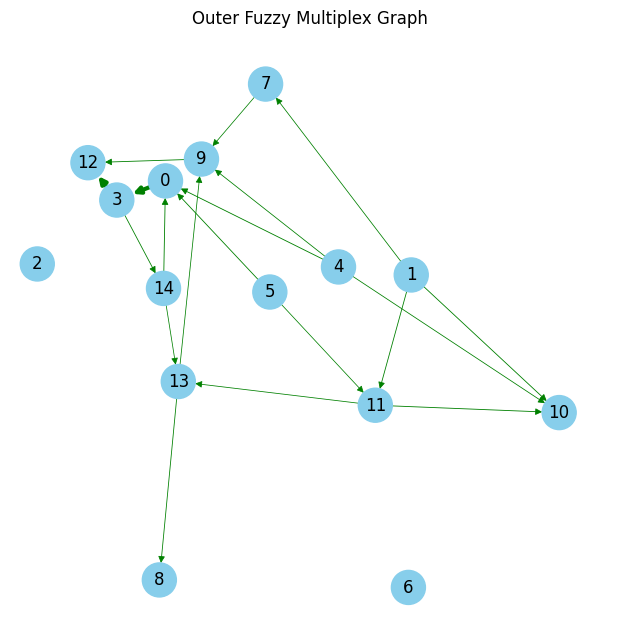

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 19 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  1.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13  0.00  0.00  0.14  0.13  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.99  0.00  0.13 
N 4 |  0.14  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13  0.13  0.00  0.00  0.00  0.00 
N 5 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

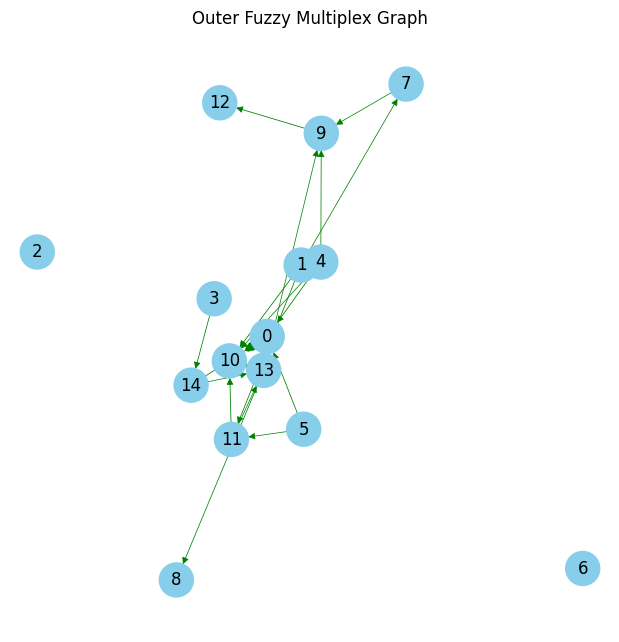

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 19 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.92  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.13  0.12  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12 
N 4 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.12  0.00  0.00  0.00  0.00 
N 5 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

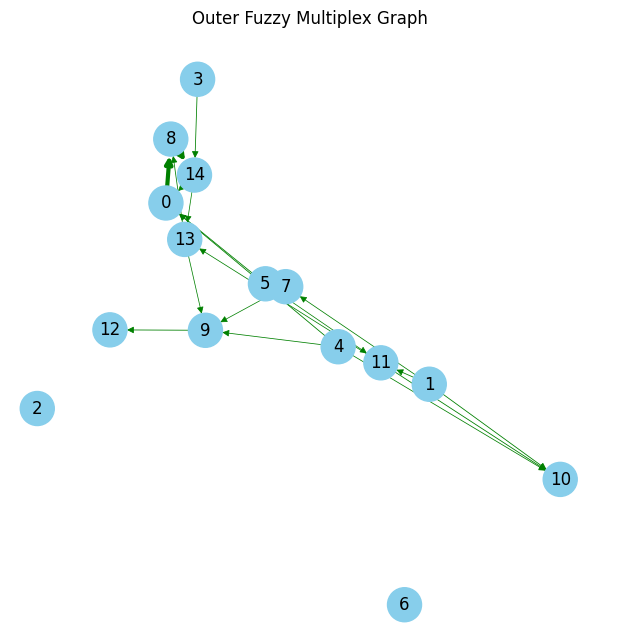

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 19 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  1.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.13  0.13  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13 
N 4 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.12  0.00  0.00  0.00  0.00 
N 5 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

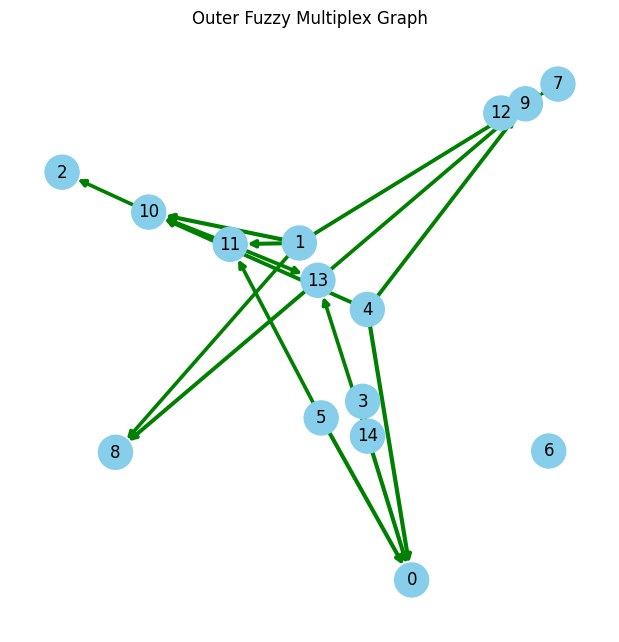

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 20 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.92  0.87  0.00  0.99  0.96  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.95 
N 4 |  1.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.93  0.93  0.00  0.00  0.00  0.00 
N 5 |  0.99  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.89  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

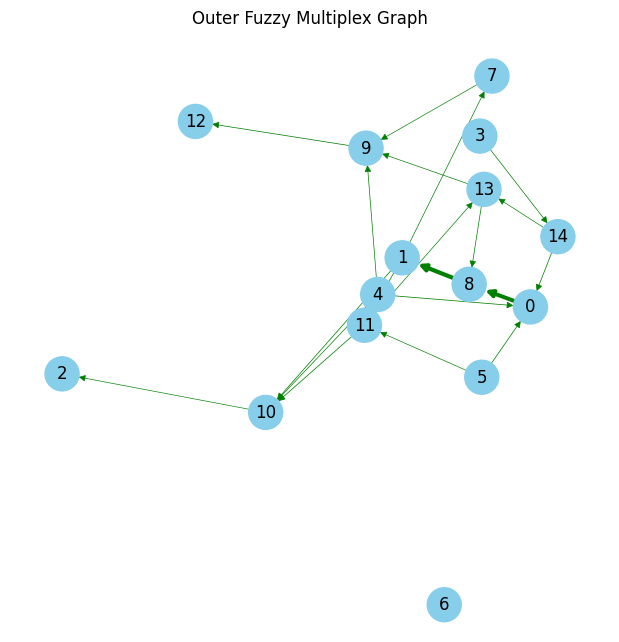

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 20 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.97  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.00  0.00  0.12  0.11  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11 
N 4 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.11  0.00  0.00  0.00  0.00 
N 5 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

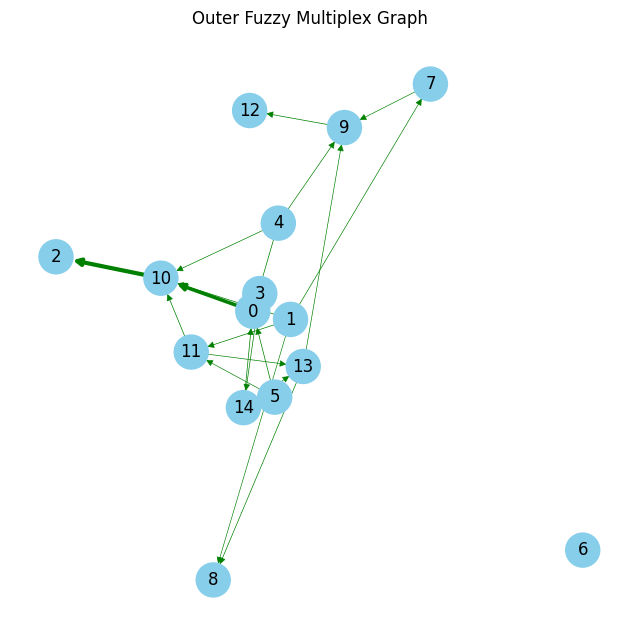

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 20 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.90  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.10  0.00  0.12  0.11  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11 
N 4 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.11  0.00  0.00  0.00  0.00 
N 5 |  0.11  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.10  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

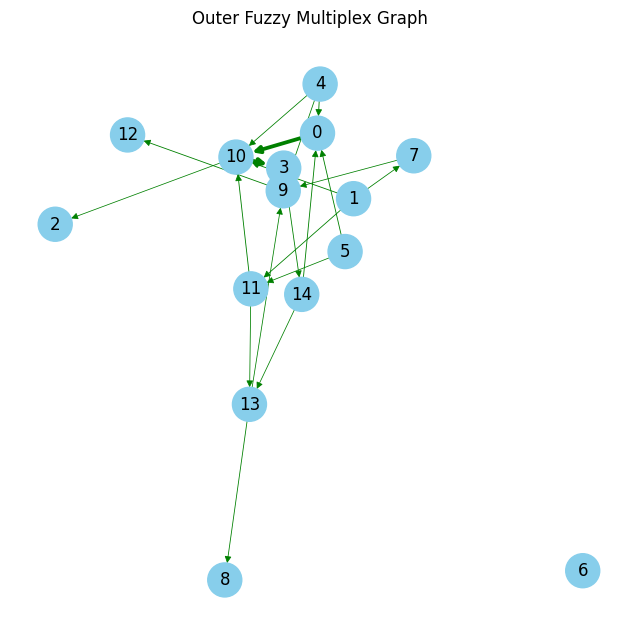

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 20 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.94  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13  0.00  0.00  0.14  0.13  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13 
N 4 |  0.14  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13  0.13  0.00  0.00  0.00  0.00 
N 5 |  0.14  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

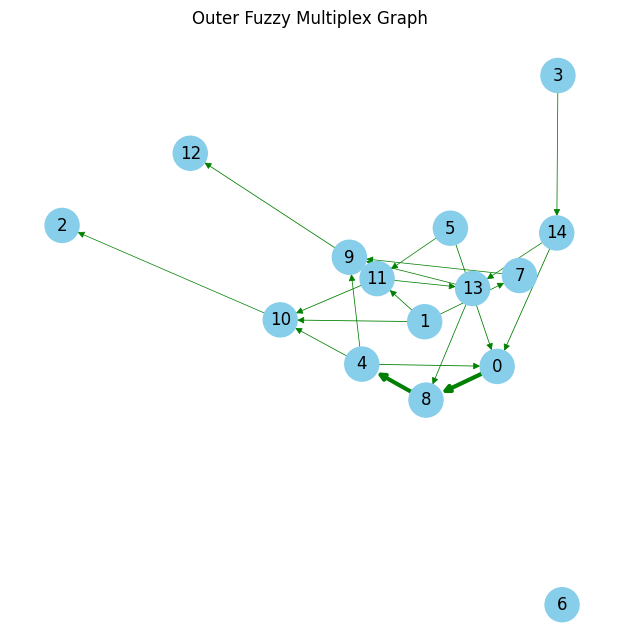

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 20 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  1.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.13  0.13  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13 
N 4 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.12  0.00  0.00  0.00  0.00 
N 5 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

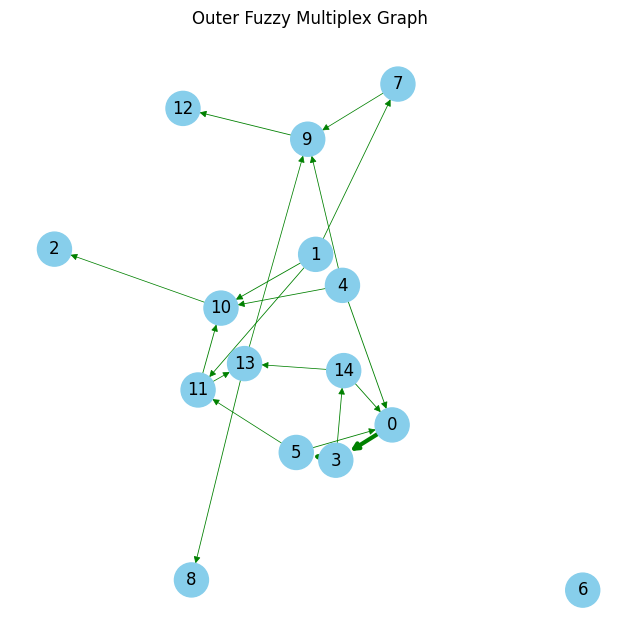

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 20 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  1.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13  0.00  0.00  0.14  0.13  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.97  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13 
N 4 |  0.14  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13  0.13  0.00  0.00  0.00  0.00 
N 5 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

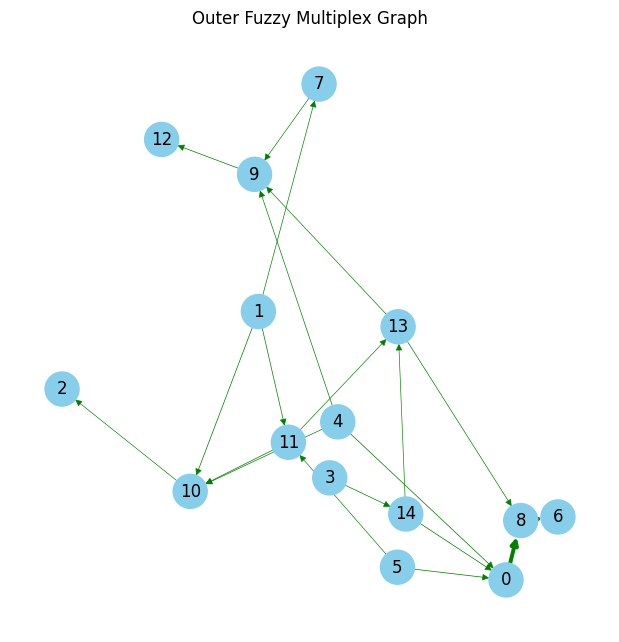

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 20 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.97  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.00  0.00  0.12  0.11  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11 
N 4 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.11  0.00  0.00  0.00  0.00 
N 5 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.10  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

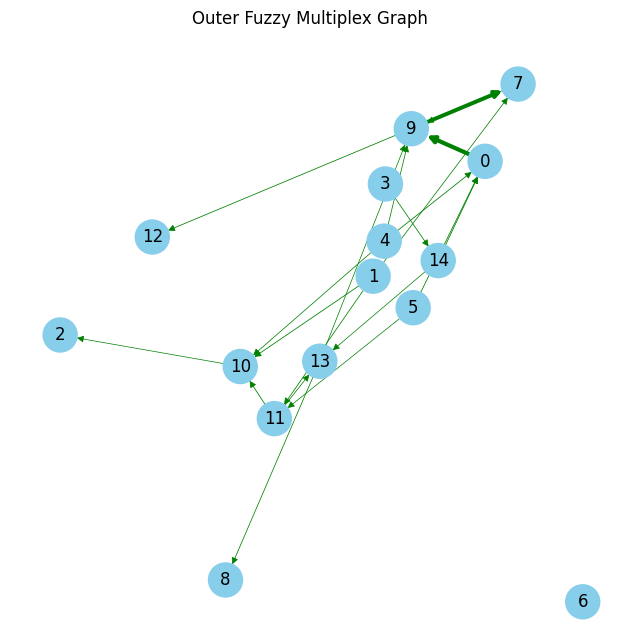

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 20 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  1.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.13  0.12  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12 
N 4 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.12  0.00  0.00  0.00  0.00 
N 5 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

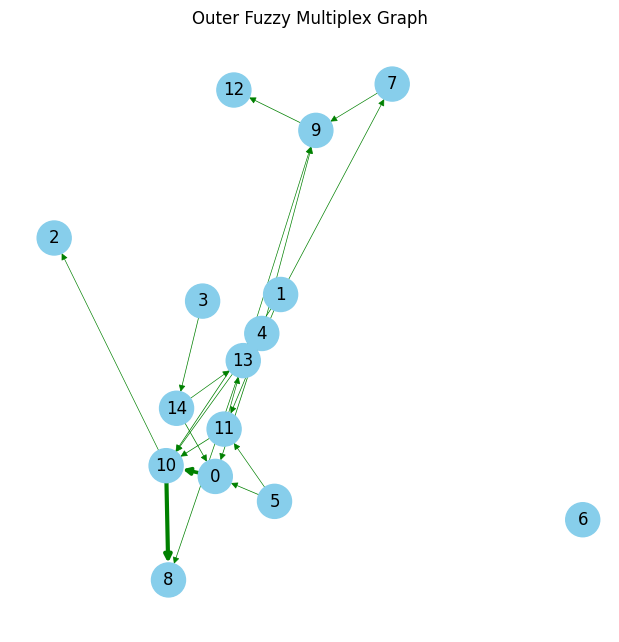

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 20 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.91  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.00  0.00  0.12  0.11  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11 
N 4 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.11  0.00  0.00  0.00  0.00 
N 5 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

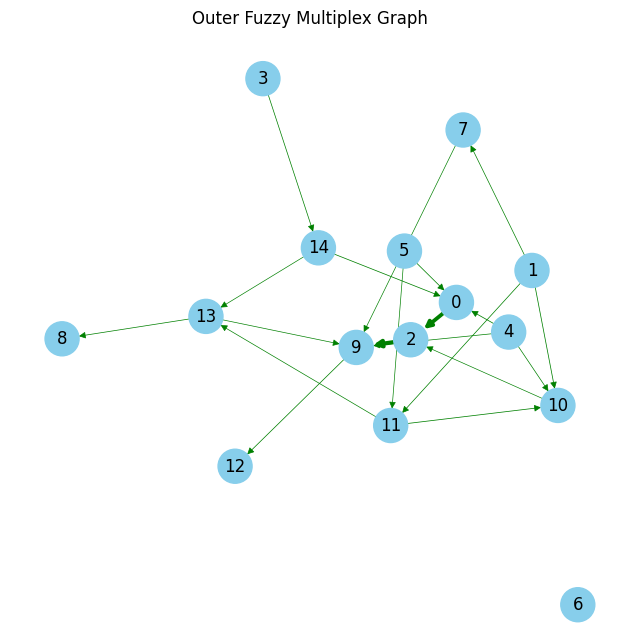

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 20 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.94  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.00  0.00  0.12  0.12  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  1.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12 
N 4 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.11  0.00  0.00  0.00  0.00 
N 5 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

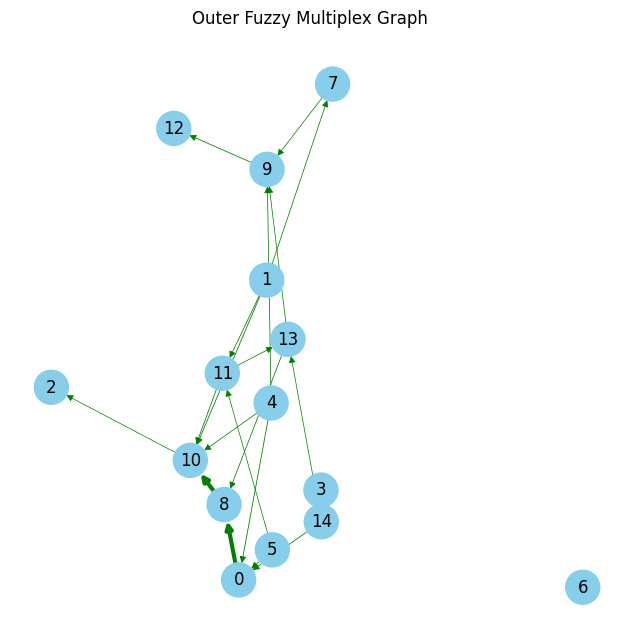

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 20 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.99  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.13  0.12  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12 
N 4 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.12  0.00  0.00  0.00  0.00 
N 5 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

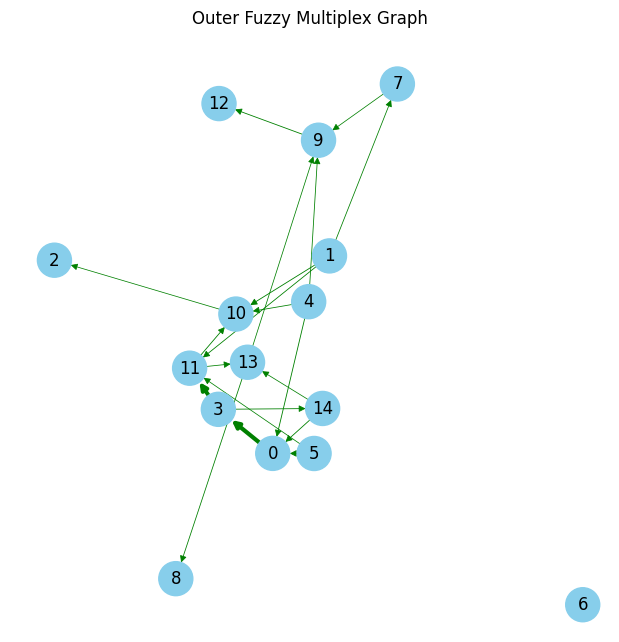

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 20 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  1.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13  0.00  0.00  0.14  0.13  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.97  0.00  0.00  0.13 
N 4 |  0.14  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13  0.13  0.00  0.00  0.00  0.00 
N 5 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

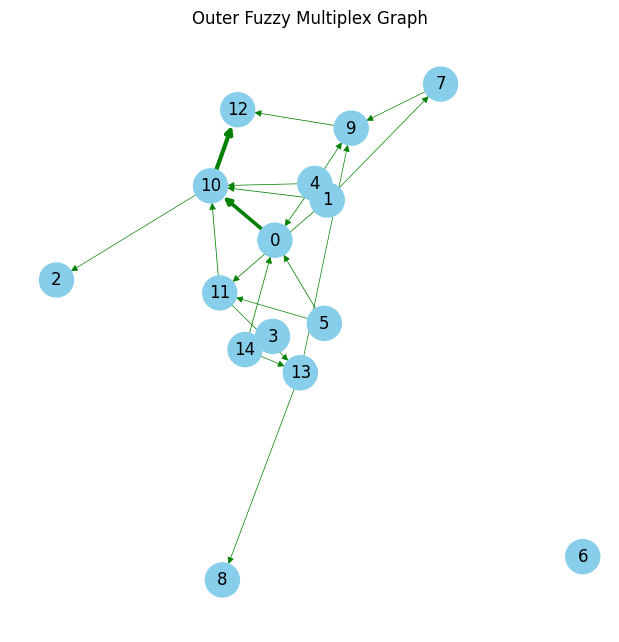

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 20 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.92  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.00  0.00  0.12  0.12  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12 
N 4 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.11  0.00  0.00  0.00  0.00 
N 5 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

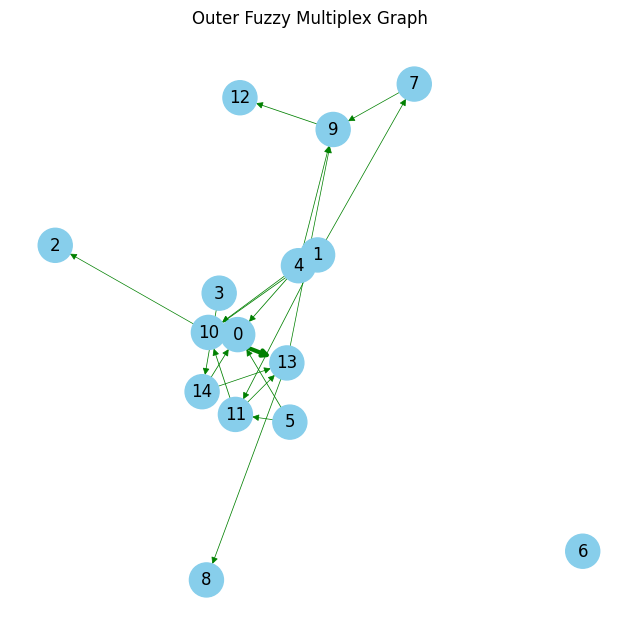

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 20 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.92  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.13  0.12  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12 
N 4 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.12  0.00  0.00  0.00  0.00 
N 5 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

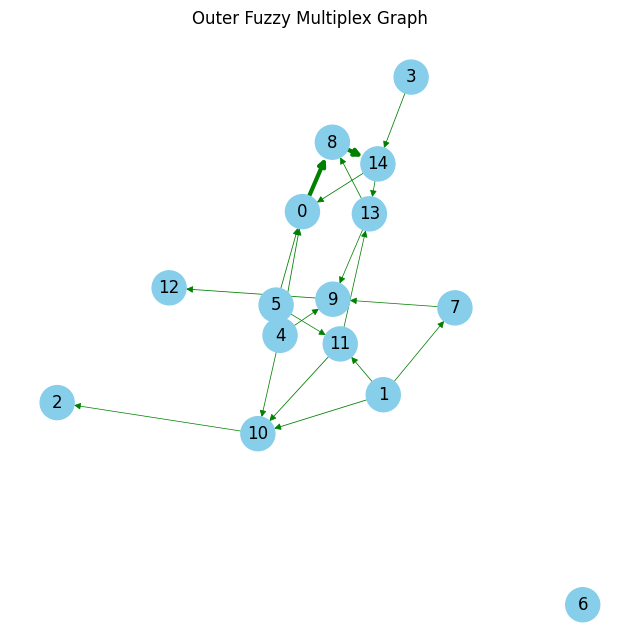

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 20 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  1.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.13  0.13  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13 
N 4 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.12  0.00  0.00  0.00  0.00 
N 5 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

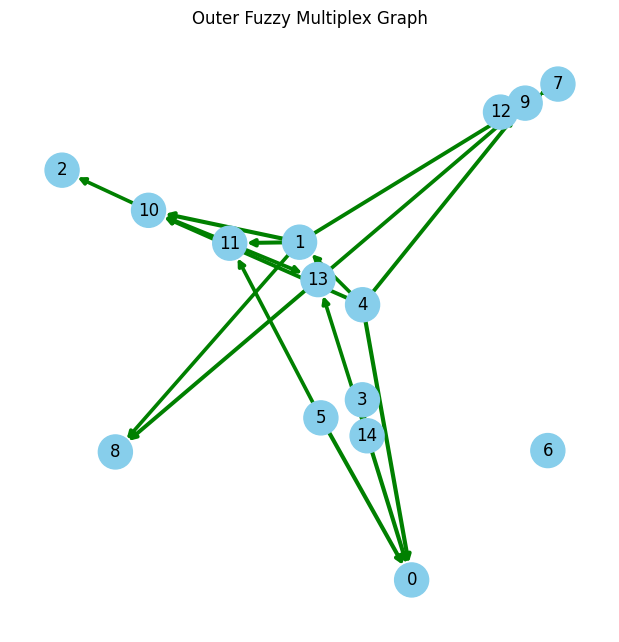

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 21 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.92  0.87  0.00  0.99  0.96  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.95 
N 4 |  1.00  0.87  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.93  0.93  0.00  0.00  0.00  0.00 
N 5 |  0.99  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.89  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

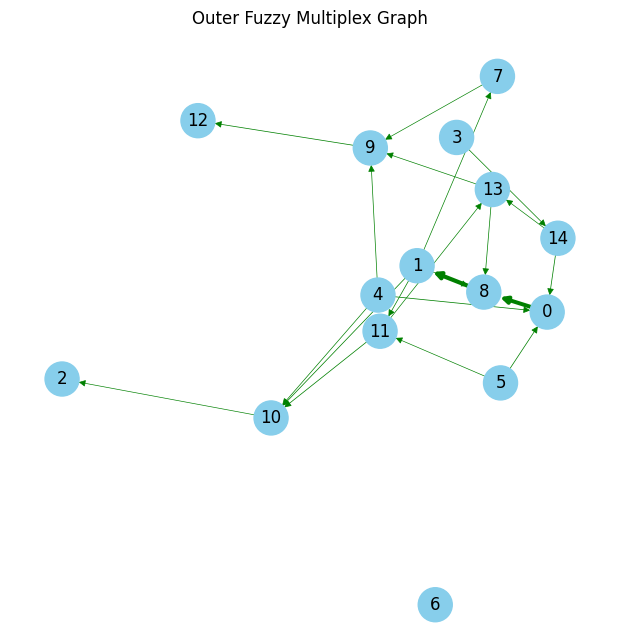

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 21 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.97  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.10  0.00  0.12  0.11  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11 
N 4 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.11  0.00  0.00  0.00  0.00 
N 5 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

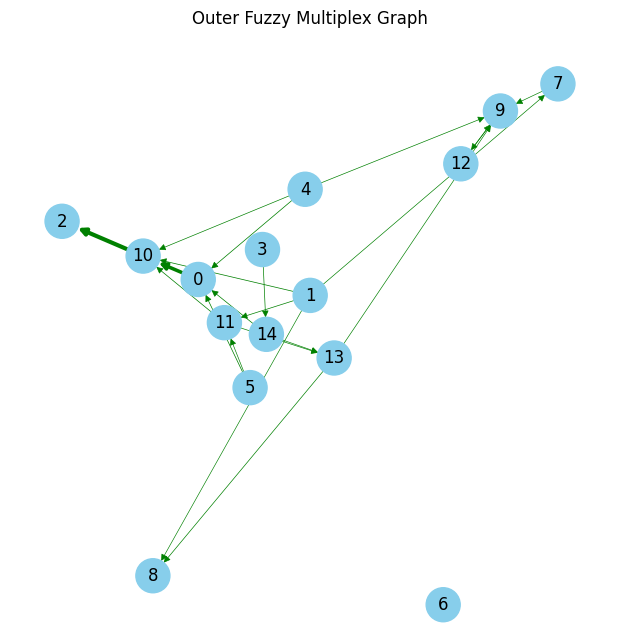

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 21 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.90  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.10  0.00  0.12  0.11  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11 
N 4 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.11  0.00  0.00  0.00  0.00 
N 5 |  0.11  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.10  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

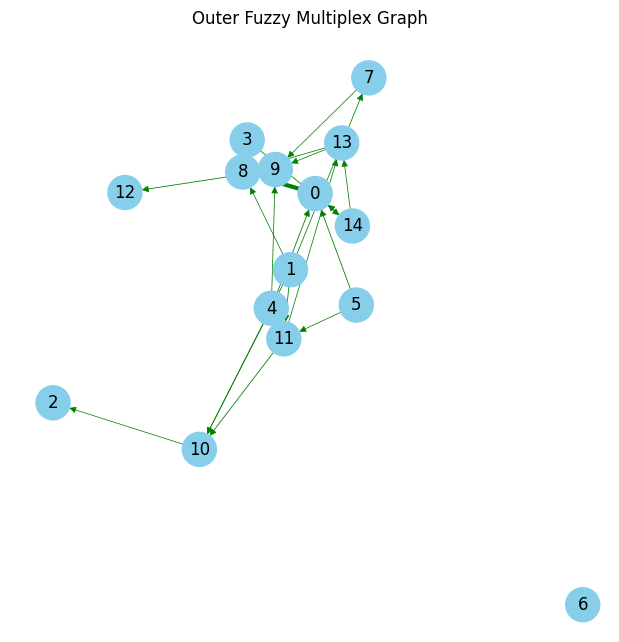

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 21 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  1.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.12  0.00  0.13  0.13  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13 
N 4 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.12  0.00  0.00  0.00  0.00 
N 5 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

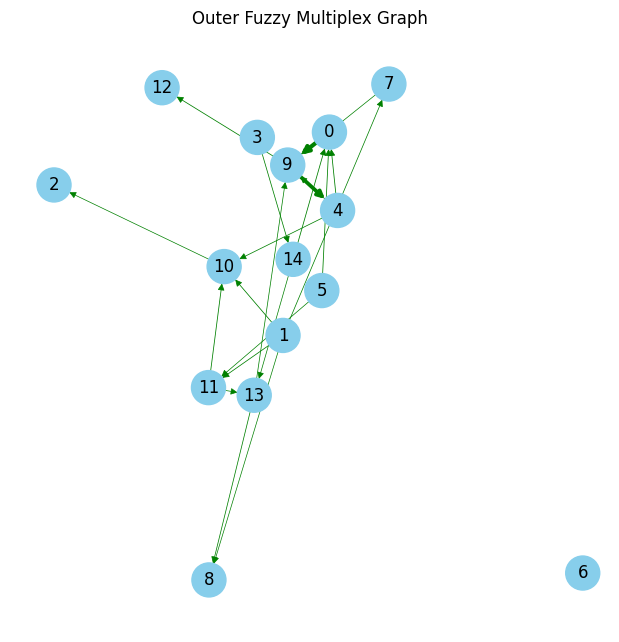

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 21 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  1.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.11  0.00  0.13  0.12  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12 
N 4 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.12  0.00  0.00  0.00  0.00 
N 5 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

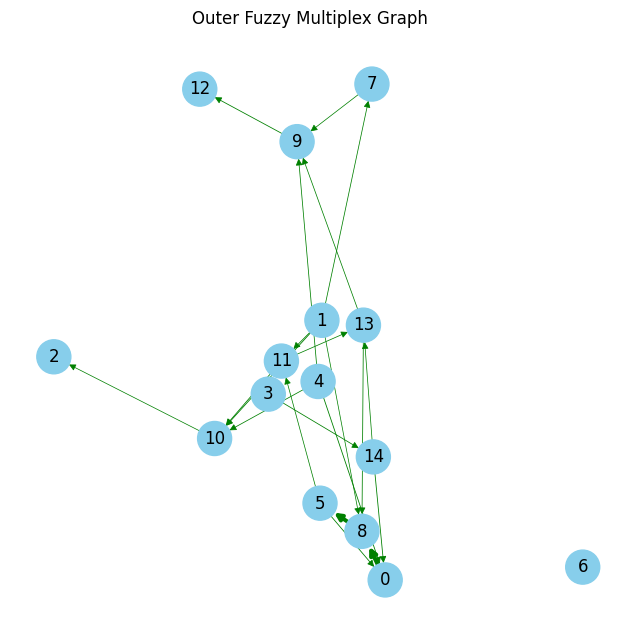

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 21 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  1.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.12  0.00  0.13  0.13  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.13 
N 4 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.12  0.00  0.00  0.00  0.00 
N 5 |  0.13  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.12  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

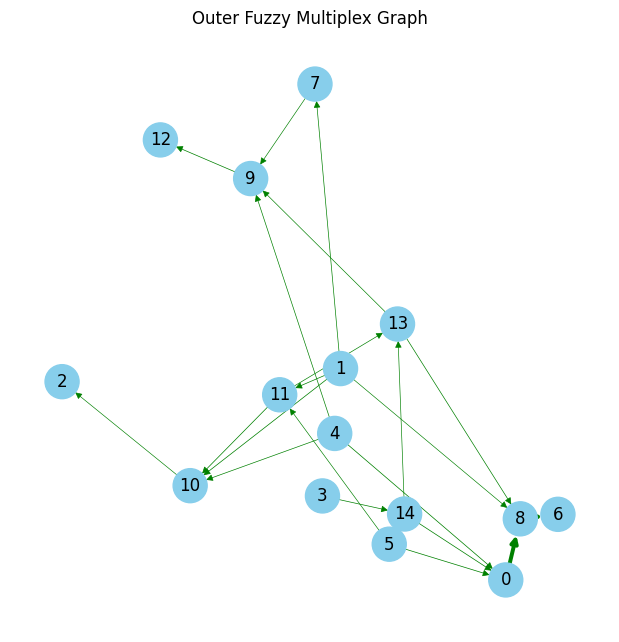

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...
 [Optimizer] Success. Mapped 1 valid trajectories.
 [Optimizer] Matrix Updated. Density: 21 edges.

=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===
     N   0 N   1 N   2 N   3 N   4 N   5 N   6 N   7 N   8 N   9 N  10 N  11 N  12 N  13 N  14
N 0 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.97  0.00  0.00  0.00  0.00  0.00  0.00 
N 1 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.10  0.00  0.12  0.11  0.00  0.00  0.00 
N 2 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
N 3 |  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11 
N 4 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.11  0.11  0.00  0.00  0.00  0.00 
N 5 |  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.10  0.00  0.00  0.00 
N 6 |  0.00  0.00  0.00  0

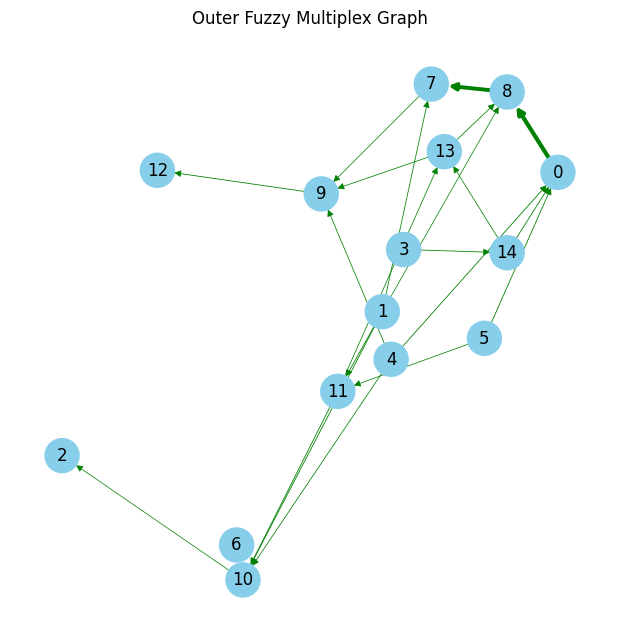

 [Optimizer] Architecture: ['A', 'A', 'C', 'B', 'B', 'B', 'C', 'B', 'B', 'B', 'B', 'C', 'C', 'B', 'A']
 [Optimizer] Mapping State Space (Exhaustive)...


In [ ]:
       #return True
# --- Inner Loop (FCM & Learning) ---
INNER_FCM_STEPS = 1000       # Iterations per node simulation
INNER_LR_X = 1.0             # Learning rate for State X
INNER_LR_Y = 0.01           # Learning rate for State Y
INNER_LR_W = 1.0             # Learning rate for Weights
INNER_SVM_LR = 0.01          # SVM Learning Rate
INNER_GAMMA = 1.0            # Inter-layer neural connection strength

# --- Random Walk & Pathfinding ---
WALK_BETA = 0.3              # Novelty penalty (dampens repeated paths)
WALK_LAMBDA_COST = 1.0       # Penalty weight for cost metrics

# --- Outer Loop (Topology Optimization) ---
OUTER_GENERATIONS = 1        # Iterations per Layer
OUTER_COST_LIMIT = 1000      # Normalization ceiling for scores
INTER_EDGE_THRESH = 0.02     # Min DSM weight to trigger neural link

for ijk in range(D_GRAPH):
    for jik in range(14,28):
            for kij in range(D_GRAPH):
         #   for lll in range(1):
                print(50*'_',ijk,50*'-',jik,50*'=')
                #===============================================================================
                OUTER_N_SIMS = 1000          # More simulations to find the "Hidden Gem" paths
                WALK_MAX_STEPS = 25
                #MAX_DEPTh# Let the walker explore complex relationships deeply
                DSM_TARGET_EDGES = jik        # Allow HIGHER density (Complexity is allowed!)
                OUTER_DSM_LAYERS = 3         # Balanced hierarchy (Structure -> Systems -> Skin)
                DSM_ADDITIVE_RATE = .5     # Low Learning Rate: Learn slowly, don't panic.
                DSM_FEEDBACK_STR = 0.05      # Weak Feedback: Listen to problems, but don't obsess.
                WALK_TOP_K = 2               # Soft Sparsity: Consider more options per step.
                DSM_FEEDBACK_FILTER = 0.1    # Only react to major issues.
                DSM_PRUNE_THRESH = 0.02      # Keep subtle connections.
                DSM_INIT_RANGE = 0.2         # Start with a blanker slate.
                STARTING_POINT = ijk           # START AT SITE ANALYSIS (Respect the Land).
                END_POINT = kij
                #=============================================================================
                # =============================================================================
                # OPTIMIZER CLASS (FIXED INITIALIZATION)
                # =============================================================================6
                class Fuzzy_Hierarchical_Multiplex:
                    def __init__(self, candidate_dims, D_graph,
                                synthetic_targets,
                                gamma_interlayer=1.0, causal_flag=False,
                                metrics=METRIC_KEYS, metric_mask=METRIC_TARGET):

                        self.candidate_dims = candidate_dims
                        self.D_graph = D_graph
                        self.synthetic_targets = synthetic_targets
                        self.causal_flag = causal_flag
                        self.best_dim_per_node = [len(t)-1 for t in synthetic_targets]
                        self.MM = metric_mask
                        self.MK = metrics
                        self.MKI = metrics + ['score']

                        # --- 1. NEURAL ENGINE INITIALIZATION (MOVED INSIDE __INIT__) ---
                        # This ensures self.model exists before run_inner is ever called.

                        # Flatten input dimensions: [[4], [16]...] -> [4, 16...]
                        input_dims_flat = [d[0] for d in candidate_dims]

                        # Prepare Data Tensor
                        # Ensure DATA_MATRIX is available globally
                        self.data_tensor = torch.FloatTensor(DATA_MATRIX)

                        # Initialize the Graph Network [Image of Graph Neural Network architecture]
                        self.model = GraphNetwork(
                            node_feature_dims=input_dims_flat,
                            adjacency_matrix=DSM,
                            latent_dim=16
                        )
                        # -------------------------------------------------------------

                        self.PLM = [[] for _ in range(self.D_graph)]
                        self.PLMS = [[] for _ in range(self.D_graph)]
                        self.nested_reps = [np.zeros(c[0]) for c in candidate_dims]

                        # Inter-layer setup
                        self.inter_layer = InterLayer(D_graph, max_inner_dim=max(candidate_dims), gamma=gamma_interlayer)
                        self.chosen_Gmat = np.random.uniform(0.0, 0.3, (D_graph, D_graph))
                        np.fill_diagonal(self.chosen_Gmat, 0)

                        self.l2_before, self.l2_after = [], []
                        self.max_target_len = max(len(t['target']) for t in synthetic_targets)
                        self.svm_lr = 0.01

                        self.metric_traces = {k: [] for k in metrics}
                        self.metric_traces_per_node = [{} for _ in range(self.D_graph)]

                        # DSM optimization hyperparameters
                        self.dsm_lr = 0.1
                        self.dsm_l1 = 0.02
                        self.dsm_clip = 1.0
                        self.dsm_history = []
                        self.dsm_cost_weight = 0.05
                        self.best_node_weights = {}

                    def print_dsm_basic(self):
                        D = self.D_graph
                        print("\n=== DESIGN STRUCTURE MATRIX (DSM) : Gmat ===")
                        header = "     " + " ".join([f"N{j:>4}" for j in range(D)])
                        print(header)
                        for i in range(D):
                            row = "N{:>2} | ".format(i)
                            for j in range(D):
                                row += f"{self.chosen_Gmat[i, j]:>5.2f} "
                            print(row)

                    # ---------- INNER LOOP (INTEGRATED) ----------
                    def run_inner(self, node_idx, target, D_fcm,
                                steps=INNER_FCM_STEPS, lr_x=INNER_LR_X, lr_y=INNER_LR_Y, lr_W=INNER_LR_W,
                                decorrelate_metrics=False):

                        # =========================================================
                        # 1. EXECUTE THE MLPs (The "Brain" runs here)
                        # =========================================================
                        # Instead of looping 1000 times to converge, we run the signal
                        # through the deep layers of the network once.

                        self.model.eval()
                        with torch.no_grad():
                            # [!] THIS LINE TRIGGERS ALL 3 SETS OF MLPs:
                            # 1. Encoder MLPs (Raw Features -> Latent Patterns)
                            # 2. Graph Mixer MLP (Mixing dependencies via DSM)
                            # 3. Decoder MLPs (Latent Patterns -> Final Metric Score)
                            derived_metrics, _ = self.model(self.data_tensor)

                        # =========================================================
                        # 2. EXTRACT THE RESULT
                        # =========================================================
                        # We grab the calculated score for the specific node we are asking about (node_idx)
                        # We average across the batch to get the "System Stability" score.
                        raw_neural_score = derived_metrics[:, node_idx].mean().item()

                        # =========================================================
                        # 3. APPLY HUMAN CONTROL (Outer Loop Weights)
                        # =========================================================
                        # If the outer optimization loop wants to dampen/amplify this node:
                        outer_scale = getattr(self, 'best_node_weights', {}).get(node_idx, 1.0)
                        if isinstance(outer_scale, (list, np.ndarray)):
                            outer_scale = 1.0

                        final_score = raw_neural_score * outer_scale

                        # =========================================================
                        # 4. FORMAT OUTPUT (Mapping back to dictionary)
                        # =========================================================
                        metric_mask = METRIC_TARGET[node_idx]
                        metric_values = {}

                        for key, mask in zip(self.MK, metric_mask):
                            if mask:
                                metric_values[key] = final_score
                                # Trace history for plotting later
                                self.metric_traces[key].append((raw_neural_score, final_score))
                            else:
                                metric_values[key] = 0.0

                        metric_values['score'] = final_score

                        # Return 0.0s placeholders to keep your legacy code happy
                        return 0.0, 0.0, 0.0, 0.0, metric_values

                    # ---------- OUTER LOOP ----------

                    # ---------- OUTER LOOP (Topology Optimization) ----------
                    def run_outer(self, outer_cost_limit=OUTER_COST_LIMIT, alpha=0.0, additive_rate=DSM_ADDITIVE_RATE):
                        """
                        OPTIMIZED: Replaces iterative simulation with Exhaustive State Space Mapping.
                        """
                        node_metrics_list = self.capped_node_metrics
                        D = self.D_graph


                        # =========================================================
                        # 3. EXHAUSTIVE STATE EVALUATION (The Speedup)
                        # =========================================================

                        # Re-infer architecture state
                        node_types = infer_node_types(node_metrics_list)
                        C_matrix = build_coupling_matrix(node_types)

                        print(f" [Optimizer] Architecture: {node_types}")
                        print(f" [Optimizer] Mapping State Space (Exhaustive)...")

                        # Initialize the Engine
                        # 1. Initialize the Strategic version of the engine
                        # Note: node_types is now handled internally by self-rule tier_map
                        state_engine = StrategicBrain(C_matrix, node_metrics_list)

                        # 2. EXECUTE: Use the Strategic Search instead of the standard Beam/DFS
                        # This prevents the 'Max Depth' stall using Alpha-Beta pruning
                      #  END_POINT = D - 1
                        final_path, fidelity_score = state_engine.run_minimax(
                            start=STARTING_POINT,
                            end=END_POINT,
                            max_depth=10  # Constrain depth to find the efficient Hybrid/Agile paths
                        )

                        # 3. (Optional) If your Pareto logic expects a list of paths:
                        valid_paths = [final_path]
                        if not valid_paths:
                            print(" [WARNING] Topology Fragmented. No valid logic flows found.")
                            valid_paths.append(list(range(D))) # Fallback
                        else:
                            print(f" [Optimizer] Success. Mapped {len(valid_paths)} valid trajectories.")

                        # =========================================================
                        # 4. MATRIX CONSTRUCTION & UPDATE
                        # =========================================================

                        # Build Layer
                        G_layer = build_dsm_from_walks(D, valid_paths)

                        # Feedback Injection
                        G_feedback = G_layer.T * DSM_FEEDBACK_STR
                        G_feedback[G_layer < DSM_FEEDBACK_FILTER] = 0.0
                        G_layer_final = G_layer + G_feedback

                        # Global Update
                        self.chosen_Gmat = self.chosen_Gmat + (additive_rate * G_layer_final)

                        # Normalize & Prune
                        if np.max(self.chosen_Gmat) > 0: self.chosen_Gmat /= np.max(self.chosen_Gmat)

                        flat = self.chosen_Gmat.ravel()
                        if len(flat) > DSM_TARGET_EDGES:
                            threshold = np.partition(flat, -DSM_TARGET_EDGES)[-DSM_TARGET_EDGES]
                            self.chosen_Gmat[self.chosen_Gmat < threshold] = 0.0

                        self.chosen_Gmat[self.chosen_Gmat < DSM_PRUNE_THRESH] = 0.0

                        # Logging
                        density = np.count_nonzero(self.chosen_Gmat)
                        print(f" [Optimizer] Matrix Updated. Density: {density} edges.")
                        self.walks = valid_paths
                        self.best_walk = valid_paths[0] if valid_paths else []
                        self.print_dsm_basic()


                        return node_metrics_list, 0.0, 0.0

                    def run(self, outer_generations=OUTER_GENERATIONS, num_dsm_layers=OUTER_DSM_LAYERS):
                        best_score = -np.inf

                        # 1. FIX INITIALIZATION:
                        # Use the random initial state as the baseline.
                        # This ensures Layer 0 captures the "Jump" from noise to structure.
                        baseline = self.chosen_Gmat.copy()
                        dsm_decomposer = DSM_Layer_Decomposer(baseline, mode='additive')
                        dsm_decomposer.current_total = baseline.copy()

                        print(f"Starting Optimization: {num_dsm_layers} Layers x {outer_generations} Gens")

                        # Define the "Building Blocks" for the 3 layers (based on your 12-15 node stack)
                        # Layer 0: Structure (Nodes 0-5), Layer 1: Systems (Nodes 6-10), Layer 2: Skin/Ops (Nodes 11-14)
                        nodes_per_layer = np.array_split(range(self.D_graph), num_dsm_layers)

                        for layer_idx in range(num_dsm_layers):
                            print(f"\n>>> COMPILING LAYER {layer_idx + 1}: {['STRUCTURE', 'SYSTEMS', 'SKIN', 'INTERIOR', 'MEP', 'FAÇADE'][layer_idx]} <<<")

                            # Determine the nodes active in this specific layer
                            active_nodes = nodes_per_layer[layer_idx]

                            for gen in range(outer_generations):
                                # 1. Inner Loop (Targeting active nodes for this layer)
                                node_metrics_list = []
                                for node_idx in range(self.D_graph):
                                    full_target = self.synthetic_targets[node_idx]['target']
                                    D_fcm = self.candidate_dims[node_idx][0]
                                    target = full_target[:D_fcm]

                                    # We simulate everything, but the "Learning" is focused on the active layer
                                    _, _, _, _, metrics = self.run_inner(node_idx, target, D_fcm)
                                    node_metrics_list.append(metrics)

                                self.capped_node_metrics = node_metrics_list

                                # 2. Outer Loop (Topology Optimization)
                                # We pass the layer_idx to run_outer if you want to adjust the WALK_TOP_K
                                # or additive_rate per layer (e.g., higher for structure, lower for skin)
                                _, capped_score, _ = self.run_outer()

                                best_score = max(best_score, capped_score)
                                print(f" [Gen {gen+1}] Score: {capped_score:.4f}", end='\r')

                            print("")

                            # 3. SNAPSHOT: The Decomposer captures the "Delta" for this layer
                            # This is where the MUX/DEMUX logic is voucher-ed.
                            dsm_decomposer.add_snapshot(self.chosen_Gmat)

                        self.dsm_layers = dsm_decomposer.layers
                        print("\nOptimization Complete. All 3 Layers Compiled.")
                        return best_score

                    # ---------- VISUALIZATIONS & ANALYSIS ----------


                    def plot_outer_fuzzy_graph(self):
                        G = nx.DiGraph()
                        for i in range(self.D_graph): G.add_node(i)
                        for i in range(self.D_graph):
                            for j in range(self.D_graph):
                                if i != j and abs(self.chosen_Gmat[i, j]) > 0.02:
                                    G.add_edge(i, j, weight=self.chosen_Gmat[i, j])

                        node_sizes = [self.best_dim_per_node[i] * 200 for i in range(self.D_graph)]
                        edge_colors = ['green' if d['weight'] > 0 else 'red' for _, _, d in G.edges(data=True)]
                        edge_widths = [abs(d['weight']) * 3 for _, _, d in G.edges(data=True)]

                        pos = nx.spring_layout(G)
                        plt.figure(figsize=(6, 6))
                        nx.draw(G, pos, node_size=node_sizes, node_color='skyblue',
                                edge_color=edge_colors, width=edge_widths, arrows=True, with_labels=True)
                        plt.title("Outer Fuzzy Multiplex Graph")
                        plt.show()



                # =============================================================================

                if __name__ == "__main__":
                    # Ensure necessary globals exist before running; otherwise this block is illustrative
                    try:
                        optimizer = Fuzzy_Hierarchical_Multiplex(
                            candidate_dims, D_graph,
                            synthetic_targets,
                            gamma_interlayer=0,
                            causal_flag=False
                        )

                        # Run Optimization
                        metrics_list = optimizer.run()

                        # Visualizations
                    # optimizer.plot_pointwise_minmax_elite()
                        #optimizer.plot_nested_activations()

                        # Compute FMT with elite bounds
                        #fmt_elite_bounds = optimizer.compute_fmt_with_elite_bounds(top_k=top_k + 10)

                        # Plot as heatmaps
                        #optimizer.plot_fmt_with_run_metrics()

                        # Compute fuzzy multiplex tensor
                        #fmt_tensor = optimizer.compute_fuzzy_metric_tensor(normalize=False)
                        #optimizer.plot_fuzzy_metric_tensor_heatmaps(fmt_tensor)

                        # Plot Contributions & Graph
                        #optimizer.plot_node_score_contribution()
                        optimizer.plot_outer_fuzzy_graph()

                        # Interactions
                    # tensor = optimizer.print_interactions()
                        #print("Tensor shape:", tensor.shape, '\n', tensor)

                        # Datapoints & Equations
                        #optimizer.collect_fmt_datapoints()
                        #optimizer.plot_fmt_per_datapoint()
                        #optimizer.collect_metric_traces_per_node()
                    # optimizer.plot_metric_equations_per_node()

                        # DSM Tracking Demo
                        dsm_tracker = DSM_Tracker(optimizer)

                        # Run extra DSM update
                        optimizer.run_outer()
                        dsm_tracker.update_dsms()

                        # Retrieve matrices
                        primary, residual = dsm_tracker.get_matrices()
                        #print("Primary DSM:\n", primary)
                        #rint("Residual DSM:\n", residual)

                    except NameError as e:
                        print(f"Error: Missing external dependency definition. \n{e}")
                        print("Please ensure D_graph, DATA_MATRIX, METRIC_KEYS, etc. are defined.")

            # primary, residual = dsm_tracker.get_matrices()

                class TopologicalEvaluator:
                    def __init__(self, dsm, node_metrics, node_types=None):
                        """
                        :param dsm: The adjacency matrix (np.array)
                        :param node_metrics: List of dicts containing 'cost', 'quality', etc.
                        :param node_types: List of 'A' or 'B' types (inferred if None)
                        """
                        self.dsm = np.array(dsm)
                        self.metrics = node_metrics
                        self.node_types = node_types if node_types else self._infer_types()
                        self.G = self._build_graph()

                    def _infer_types(self):
                        return ["A" if m.get('quality', 0) >= m.get('cost', 0) else "B" for m in self.metrics]

                    def _build_graph(self):
                        G = nx.DiGraph()
                        for i in range(len(self.dsm)):
                            for j in range(len(self.dsm)):
                                if self.dsm[i, j] > 0:
                                    G.add_edge(i, j, weight=self.dsm[i, j])
                        return G

                    def calculate_system_pressure(self):
                        """Calculates total pressure based on P = F/A logic across the topology."""
                        total_p = 0
                        edge_data = []

                        for u, v in self.G.edges():
                            # Force (Potential delta)
                            v_u = np.array(list(self.metrics[u].values()))
                            v_v = np.array(list(self.metrics[v].values()))
                            force = np.linalg.norm(np.maximum(v_v - v_u, 0)) + 1e-9

                            # Area (Friction of destination)
                            area = np.mean(v_v) + 0.1

                            # Pressure
                            p = self.dsm[u, v] * (force / area)
                            total_p += p
                            edge_data.append({'link': (u, v), 'pressure': p})

                        return total_p, edge_data

                    def evaluate_topology(self):
                        # 1. Component Analysis
                        sccs = list(nx.strongly_connected_components(self.G))
                        cycles = [list(c) for c in sccs if len(c) > 1]

                        # 2. Hierarchical Depth
                        condensed = nx.condensation(self.G)
                        layers = list(nx.topological_generations(condensed))

                        # 3. System Pressure
                        total_p, edge_pressures = self.calculate_system_pressure()

                        # 4. NODE METRIC FITNESS (New Implementation)
                        # Calculate how much leverage nodes have based on connectivity
                        try:
                            centrality = nx.degree_centrality(self.G)
                        except:
                            centrality = {i: 0 for i in range(len(self.metrics))}

                        metric_score = 0
                        for i, m in enumerate(self.metrics):
                            # Net utility of the node
                            val = m.get('quality', 0) - m.get('cost', 0)
                            # Boost score if the node is topologically significant
                            metric_score += val * (1 + centrality.get(i, 0))

                        # 5. Final Fitness Calculation
                        # Combines Structural Depth (Stability) - Pressure (Friction) + Metric Performance (Value)
                        fitness = (len(layers) * 5) - (total_p * 0.25) + (metric_score * 10)

                        return {
                            "hierarchy_depth": len(layers),
                            "cycle_count": len(cycles),
                            "system_pressure": round(total_p, 4),
                            "net_metric_value": round(metric_score, 4),
                            "fitness_score": round(fitness, 2),
                            "bottlenecks": sorted(edge_pressures, key=lambda x: x['pressure'], reverse=True)[:3]
                        }

                import numpy as np

                # 1. GENERATE ACTUAL STATE DATA
                # We must turn the generator functions into a snapshot of data
                generators = GENERATOR_MAP
                current_state = {node: gen() for node, gen in generators.items()}

                # 2. TRANSFORM STATE INTO EVALUATOR-FRIENDLY METRICS
                # The evaluator looks for 'quality' and 'cost'. We map your architectural KPIs:
                # Quality = performance-based metrics (safety, aesthetics, completeness)
                # Cost = resource-based metrics (budget, tonnage, violations)
                evaluator_metrics = []
                METRIC_MAP = metric_feature_map
                node_list = list(METRIC_MAP.keys())

                for node in node_list:
                    node_data = current_state.get(node, {})
                    feat_key = METRIC_MAP[node][0]
                    category = METRIC_MAP[node][1]

                    val = node_data.get(feat_key, 0.5)

                    # Logic: If it's a 'Prevention' or 'Alpha' category, it's Quality.
                    # If it's 'Efficiency' or 'Total Cost', it relates to Cost.
                    if category in ["Regulatory_Alpha", "Clinical_Safety", "Loss_Ratio_Prevention"]:
                        evaluator_metrics.append({"quality": val, "cost": 0.1}) # Low baseline cost
                    else:
                        evaluator_metrics.append({"quality": 0.5, "cost": val / 1000.0}) # Scale budget to 0-1 range

                # 3. RUN EVALUATOR
                # Ensure 'primary' (your DSM) is indexed in the same order as node_list
                evaluator = TopologicalEvaluator(primary, evaluator_metrics)
                report = evaluator.evaluate_topology()


                # 4. OUTPUT RESULTS
                        # Unify all analysis and print logic into a single command

                def run_unified_audit(primary_matrix, target_dsm, evaluator_metrics, node_list):
                    """
                    Unified Topological Audit comparing the 'Primary' system against the 'Target DSM'.
                    """
                    # 1. Setup Evaluators for both matrices
                    # We are comparing Primary (The baseline/current state) vs DSM (The target/proposed state)
                    eval_primary = TopologicalEvaluator(primary_matrix, evaluator_metrics)
                    eval_target = TopologicalEvaluator(target_dsm, evaluator_metrics)

                    # 2. Process Reports
                    res_p = eval_primary.evaluate_topology()
                    res_t = eval_target.evaluate_topology()

                    # 3. UNIFIED OUTPUT TABLE
                    print(f"\n{' TOPOLOGICAL SYSTEM AUDIT: PRIMARY VS. TARGET DSM ':=^75}")
                    print(f"{'KPI Indicator':<32} | {'PRIMARY':<15} | {'TARGET DSM':<15} | {'DELTA':<10}")
                    print("-" * 75)

                    metrics_map = [
                        ("Fitness Score (0-100)", res_p['fitness_score'], res_t['fitness_score']),
                        ("System Pressure (Pa)", res_p['system_pressure'], res_t['system_pressure']),
                        ("Sequential Hierarchy Depth", res_p['hierarchy_depth'], res_t['hierarchy_depth']),
                        ("Coupled Feedback Cycles", res_p['cycle_count'], res_t['cycle_count'])
                    ]

                    for label, p_val, t_val in metrics_map:
                        print(f"{label:<32} | {p_val:<15.2f} | {t_val:<15.2f} | {t_val - p_val:+.2f}")

                    print("=" * 75)

                    # 4. PRIMARY BOTTLENECK
                    if res_p['bottlenecks']:
                        p_top = res_p['bottlenecks'][0]
                        p_src, p_dst = p_top['link']
                        print(f"PRIMARY BOTTLENECK: {node_list[p_src]} → {node_list[p_dst]}")
                        print(f"Friction Magnitude: {p_top['pressure']:.4f}")

                    print("-" * 75)

                    # 5. TARGET DSM BOTTLENECK
                    if res_t['bottlenecks']:
                        t_top = res_t['bottlenecks'][0]
                        t_src, t_dst = t_top['link']
                        print(f"TARGET DSM BOTTLENECK: {node_list[t_src]} → {node_list[t_dst]}")
                        print(f"Friction Magnitude: {t_top['pressure']:.4f}")

                # --- EXECUTION ---
                # This compares the Primary matrix against the target DSM directly.
                run_unified_audit(primary, DSM, evaluator_metrics, node_list)
                import numpy as np
                import pandas as pd
                import networkx as nx

                import numpy as np
                import pandas as pd
                import networkx as nx

                class GenericServiceSimulator:
                    def __init__(self, touchpoints, generator_map):
                        self.TOUCHPOINTS = touchpoints
                        self.GENERATOR_MAP = generator_map

                    def evaluate_dsm(self, dsm_matrix, label="Generic Run", weak_threshold=0.2):
                        """
                        Evaluates the DSM structure, simulates flow, and calculates sensitivity + fitness.
                        """
                        D = dsm_matrix.shape[0]
                        G = nx.DiGraph()

                        #

                        for i in range(D):
                            G.add_node(self.TOUCHPOINTS[i])
                            for j in range(D):
                                if dsm_matrix[i, j] > 0:
                                    G.add_edge(self.TOUCHPOINTS[i], self.TOUCHPOINTS[j])

                        # Identify Components (SCCs)
                        sccs = list(nx.strongly_connected_components(G))
                        node_to_module = {}
                        module_details = {}
                        detected_feedback_loops = []

                        for idx, comp in enumerate(sccs):
                            comp_list = list(comp)
                            comp_list.sort(key=lambda x: self.TOUCHPOINTS.index(x))
                            for node in comp_list:
                                node_to_module[node] = idx

                            is_coupled = len(comp_list) > 1
                            cluster_name = " + ".join(comp_list) if is_coupled else comp_list[0]

                            if is_coupled:
                                for u in comp_list:
                                    for v in comp_list:
                                        if G.has_edge(u, v):
                                            if self.TOUCHPOINTS.index(u) > self.TOUCHPOINTS.index(v):
                                                detected_feedback_loops.append({
                                                    "cluster": cluster_name,
                                                    "description": f"Feedback: {u} -> {v}"
                                                })

                            module_details[idx] = {
                                "name": cluster_name,
                                "type": "Coupled Cluster" if is_coupled else "Linear Unit",
                                "members": comp_list,
                                "size": len(comp_list)
                            }

                        # Leveling & Execution
                        MG = nx.DiGraph()
                        MG.add_nodes_from(range(len(sccs)))
                        for u, v in G.edges():
                            mu, mv = node_to_module[u], node_to_module[v]
                            if mu != mv: MG.add_edge(mu, mv)

                        try:
                            levels = list(nx.topological_generations(MG))
                        except nx.NetworkXUnfeasible:
                            levels = [list(MG.nodes())]

                        execution_log = []
                        process_time_steps = 0
                        total_rework_risk = 0.0

                        for level_idx, modules_in_level in enumerate(levels, 1):
                            process_time_steps += 1
                            for mod_idx in modules_in_level:
                                details = module_details[mod_idx]
                                if details["size"] > 1:
                                    total_rework_risk += (details["size"] ** 1.5) * 0.15

                                for tp in details["members"]:
                                    data = self.GENERATOR_MAP[tp]()
                                    for k, v in data.items():
                                        execution_log.append({
                                            "Run Label": label, "Time Step": level_idx,
                                            "Cluster Name": details["name"], "Node": tp, "Metric": k, "Value": v
                                        })

                        # ==========================================================
                        # WEAK CONNECTION (SENSITIVITY) ANALYSIS
                        # ==========================================================
                        #
                        G_strong = nx.DiGraph()
                        weak_links_count = 0
                        dropped_links = []

                        for i in range(D):
                            G_strong.add_node(self.TOUCHPOINTS[i])
                            for j in range(D):
                                w = dsm_matrix[i, j]
                                if w > 0:
                                    if w >= weak_threshold:
                                        G_strong.add_edge(self.TOUCHPOINTS[i], self.TOUCHPOINTS[j])
                                    else:
                                        weak_links_count += 1
                                        dropped_links.append((self.TOUCHPOINTS[i], self.TOUCHPOINTS[j], w))

                        sccs_strong = list(nx.strongly_connected_components(G_strong))
                        strong_coupled_count = sum(1 for c in sccs_strong if len(c) > 1)
                        original_coupled_count = sum(1 for c in sccs if len(c) > 1)

                        critical_weak_links = []
                        if strong_coupled_count < original_coupled_count:
                            for u, v, w in dropped_links:
                                in_same_original_scc = any(u in c and v in c and len(c) > 1 for c in sccs)
                                path_exists_strong = nx.has_path(G_strong, u, v) and nx.has_path(G_strong, v, u)
                                if in_same_original_scc and not path_exists_strong:
                                    critical_weak_links.append({"link": f"{u} -> {v}", "weight": round(w, 4), "effect": "Maintains Loop"})

                        sensitivity_report = {
                            "threshold": weak_threshold, "weak_links_ignored": weak_links_count,
                            "loops_original": original_coupled_count, "loops_filtered": strong_coupled_count,
                            "critical_weak_links": critical_weak_links,
                            "is_sensitive": (original_coupled_count != strong_coupled_count)
                        }

                        results = {
                            "label": label, "total_nodes": D, "total_time_steps": process_time_steps,
                            "rework_risk_score": round(total_rework_risk, 2), "feedback_loops": detected_feedback_loops,
                            "structure": module_details, "execution_df": pd.DataFrame(execution_log),
                            "sensitivity_analysis": sensitivity_report
                        }

                        # *** NEW: Calculate Fitness Immediately ***
                        results["fitness_analysis"] = self.calculate_design_fitness(results)
                        return results

                        # *** NEW: Calc

                    def calculate_design_fitness(self, results):
                        """
                        Derives a fitness score, classifies the design archetype,
                        and stores critical performance metrics.
                        """
                        N = results['total_nodes']
                        steps = results['total_time_steps']
                        risk = results['rework_risk_score']

                        # 1. PARALLELISM SCORE (Efficiency)
                        # Avoid division by zero
                        safe_steps = steps if steps > 0 else 1
                        parallelism_ratio = N / safe_steps

                        # Cap generic parallelism bonuses at 20 points
                        speed_score = min(parallelism_ratio * 10, 20)

                        # 2. STABILITY SCORE (Safety)
                        # Higher risk reduces score drastically
                        # Perfect score is 10. Risk of 5 reduces it to ~1.6
                        stability_score = 10 / (1 + (risk * 0.5))

                        # 3. COMPOSITE FITNESS
                        # Balanced mix: Speed (40%) and Stability (60%)
                        raw_fitness = (speed_score * 0.4) + (stability_score * 0.6)

                        # 4. DESIGN IMPLICATION (Archetype Classification)
                        implication = "Unknown"
                        if parallelism_ratio >= 1.5 and risk > 1.0:
                            implication = "Agile / High Velocity" # Fast but risky
                        elif parallelism_ratio < 1.2 and risk < 0.5:
                            implication = "Waterfall / Bureaucratic" # Stable but slow
                        elif parallelism_ratio >= 1.5 and risk < 0.5:
                            implication = "Ideal Architecture" # Fast & Stable (Rare)
                        elif parallelism_ratio < 1.2 and risk > 1.0:
                            implication = "Chaotic / Bottlenecked" # Slow & Risky (Worst case)
                        else:
                            implication = "Hybrid / Moderate"

                        # 5. CONSTRUCT RESULT DICTIONARY
                        return {
                            # --- The Requested Fields ---
                            "design_archetype": implication, # The classification
                            "total_steps": steps,            # Raw duration
                            "rework_risk": round(risk, 4),   # Raw risk

                            # --- Calculation Details ---
                            "parallelism_ratio": round(parallelism_ratio, 2),
                            "speed_points": round(speed_score, 2),
                            "stability_points": round(stability_score, 2),
                            "composite_score": round(raw_fitness, 2)
                        }

                # ==========================================
                # UPDATED PRINT HELPER
                # ==========================================
                def print_fitness_comparison(res_a, res_b):
                    print(f"\n{'='*80}")
                    print(f" DESIGN FITNESS COMPARISON")
                    print(f"{'='*80}")

                    # Headers
                    print(f"{'Metric':<30} | {res_a['label']:<22} | {res_b['label']:<22}")
                    print(f"{'-'*30} | {'-'*22} | {'-'*22}")

                    fit_a = res_a['fitness_analysis']
                    fit_b = res_b['fitness_analysis']

                    # Core Stats from the new dictionary structure
                    print(f"{'Design Archetype':<30} | {fit_a['design_archetype']:<22} | {fit_b['design_archetype']:<22}")
                    print(f"{'Total Steps':<30} | {fit_a['total_steps']:<22} | {fit_b['total_steps']:<22}")
                    print(f"{'Rework Risk':<30} | {fit_a['rework_risk']:<22} | {fit_b['rework_risk']:<22}")
                    print(f"{'-'*30} | {'-'*22} | {'-'*22}")
                    print(f"{'Parallelism Ratio':<30} | {fit_a['parallelism_ratio']:<22} | {fit_b['parallelism_ratio']:<22}")
                    print(f"{'Composite Fitness (0-10)':<30} | {fit_a['composite_score']:<22} | {fit_b['composite_score']:<22}")
                    print(f"{'='*80}")

                # ==========================================
                # 1. DEFINE GENERIC INPUTS
                # ==========================================

                # Generic Touchpoints (Nodes A through E)
                generic_touchpoints = TOUCHPOINTS
                # Generic Generator Map (Abstract Work)
                # - Node A: Input Source (High variance inputs)
                # - Node B/C: Processing (Efficiency metrics)
                # - Node D/E: Output/Control (Quality metrics)
                generic_generator_map = GENERATOR_MAP

                # ==========================================
                # 2. DEFINE GENERIC ARCHITECTURES (DSMs)
                # ==========================================
                N = D_graph

                # A. SERIAL PROCESS (0->1->2->3->4)
                serial_dsm = np.zeros((N, N))
                for i in range(N-1):
                    serial_dsm[i, i+1] = 1

                # B. INTEGRATED PROCESS (Coupled Core)
                # Node B (1), C (2), D (3) form a feedback loop
                integrated_dsm = serial_dsm.copy()
                integrated_dsm[3, 1] = 1 # D feeds back to B

                # ==========================================
                # 3. RUN SIMULATION
                # ==========================================

                sim = GenericServiceSimulator(generic_touchpoints, generic_generator_map)

                # Run Serial
                res_serial = sim.evaluate_dsm(DSM, label="Serial Flow")

                # Run Integrated
                res_integrated = sim.evaluate_dsm(primary, label="Integrated Core")

                # ==========================================
                # 4. VIEW RESULTS
                # ==========================================

                print(f"--- COMPARISON (Nodes: {len(generic_touchpoints)}) ---")
                print(f"Serial Duration:     {res_serial['total_time_steps']} steps (Risk: {res_serial['rework_risk_score']})")
                print(f"Integrated Duration: {res_integrated['total_time_steps']} steps (Risk: {res_integrated['rework_risk_score']})")

                print("\n--- DETAILED EXECUTION LOG (INTEGRATED) ---")
                df = res_integrated['execution_df']
                # Show how Node B, C, D ran in the same Time Step
                target_nodes = TOUCHPOINTS[1:4]

                results = sim.evaluate_dsm(primary, label="Feedback Analysis")

                print(f"Filtering for: {target_nodes}")
                print(df[df['Node'].isin(target_nodes)][['Time Step', 'Node', 'Metric', 'Value']].head(6))
                print("--- STRUCTURAL ANALYSIS ---")
                print(f"Rework Risk Score: {results['rework_risk_score']}")

                print("\n[1] IDENTIFIED MODULES/CLUSTERS:")
                for idx, details in results['structure'].items():
                    print(f"  Module {idx}: {details['name']} ({details['type']})")

                print("\n[2] DETECTED FEEDBACK LOOPS:")
                if results['feedback_loops']:
                    for loop in results['feedback_loops']:
                        print(f"  Warning: {loop['description']}")
                        print(f"           (Found inside cluster: '{loop['cluster']}')")
                else:
                    print("  None detected.")

                print("\n[3] EXECUTION SNAPSHOT (Coupled Block):")
                df = results['execution_df']
                # Filter for the coupled cluster name dynamically
                coupled_cluster_name = [d['name'] for d in results['structure'].values() if d['type'] == 'Coupled Cluster']
                if coupled_cluster_name:
                    print(df[df['Cluster Name'] == coupled_cluster_name[0]].head(3).to_string(index=False))



                res_serial = sim.evaluate_dsm(DSM, label="Linear Baseline")
                res_integrated = sim.evaluate_dsm(primary, label="Integrated Loop")

                # --- Compare Fitness ---
                print_fitness_comparison(res_serial, res_integrated)

                print(f"\n[Detailed Implication for Integrated Run]")
                print(f"Why this score? Because we found {len(res_integrated['feedback_loops'])} feedback loops.")
                if res_integrated['fitness_analysis']['composite_score'] < res_serial['fitness_analysis']['composite_score']:
                    print(">> CONCLUSION: The gain in speed did not justify the cost of coordination risk.")
                else:
                    print(">> CONCLUSION: The design is robust enough to handle the complexity.")


                all_results.append(sim.evaluate_dsm(primary, label="Integrated (Core)"))



# Pareto

In [ ]:
import matplotlib.pyplot as plt

class ParetoAnalyzer:
    @staticmethod
    def identify_pareto_efficient(costs):
        """
        Finds the Pareto-efficient points in a cloud of data.
        :param costs: (n_points, 2) array where columns are (Steps, Risk).
                      Assumes LOWER is better for both.
        :return: Boolean mask of efficient points.
        """
        is_efficient = np.ones(costs.shape[0], dtype=bool)
        for i, c in enumerate(costs):
            if is_efficient[i]:
                # Keep points where no other point is strictly better
                # A point j dominates i if:
                # step[j] <= step[i] AND risk[j] <= risk[i]
                # AND at least one is strictly smaller.
                is_efficient[is_efficient] = np.any(costs[is_efficient] < c, axis=1)  | \
                                             np.any(costs[is_efficient] == c, axis=1)
                is_efficient[i] = True  # Keep self
        return is_efficient

    @staticmethod
    def plot_tradeoff_landscape(results_list):
        """
        Visualizes Steps vs Risk with the Pareto Front highlighted.
        """
        # 1. Extract Data
        data = []
        labels = []
        archetypes = []

        for res in results_list:
            fit = res['fitness_analysis']
            # We want to MINIMIZE Steps and MINIMIZE Risk
            data.append([fit['total_steps'], fit['rework_risk']])
            labels.append(res['label'])
            archetypes.append(fit['design_archetype'])

        points = np.array(data)

        # 2. Calculate Frontier
        # Simple sorting method for 2D Pareto:
        # Sort by X (Steps). The Pareto front are points where Y (Risk) is lower than all previous Ys.
        sorted_indices = np.argsort(points[:, 0])
        sorted_points = points[sorted_indices]

        pareto_front = []
        current_min_risk = float('inf')

        pareto_indices = []

        for idx in sorted_indices:
            step, risk = points[idx]
            if risk < current_min_risk:
                pareto_front.append([step, risk])
                pareto_indices.append(idx)
                current_min_risk = risk

        pareto_front = np.array(pareto_front)

        # 3. Plotting
        plt.figure(figsize=(12, 7))

        # Color map for archetypes
        unique_archs = list(set(archetypes))
        colors = plt.cm.get_cmap('tab10', len(unique_archs))
        color_map = {arch: colors(i) for i, arch in enumerate(unique_archs)}

        # Scatter all points
        for i, point in enumerate(points):
            plt.scatter(point[0], point[1], c=[color_map[archetypes[i]]],
                        s=100, alpha=0.7, edgecolors='gray')

            # Annotate interesting points (Pareto or outliers)
            if i in pareto_indices:
                plt.text(point[0], point[1]+0.05, labels[i], fontsize=9, fontweight='bold')

        # Draw Pareto Line
        if len(pareto_front) > 0:
            plt.plot(pareto_front[:, 0], pareto_front[:, 1], 'r--', linewidth=2, label='Pareto Frontier', alpha=0.6)
            plt.fill_between(pareto_front[:, 0], pareto_front[:, 1], points[:, 1].max(), color='red', alpha=0.05)

        # Legend creation
        from matplotlib.lines import Line2D
        legend_elements = [Line2D([0], [0], color='r', linestyle='--', label='Pareto Frontier')]
        for arch, col in color_map.items():
            legend_elements.append(Line2D([0], [0], marker='o', color='w', markerfacecolor=col, label=arch, markersize=10))

        plt.title("Design Space Trade-offs: Efficiency vs Stability", fontsize=14)
        plt.xlabel("Total Time Steps (Lower is Faster)", fontsize=12)
        plt.ylabel("Rework Risk Score (Lower is Safer)", fontsize=12)
        plt.legend(handles=legend_elements)
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.tight_layout()
        plt.show()

        # 4. Print Table
        print(f"\n{'='*60}")
        print(f" PARETO EFFICIENT DESIGNS (The 'Sweet Spots')")
        print(f"{'='*60}")
        print(f"{'Design Label':<20} | {'Steps':<8} | {'Risk':<8} | {'Archetype'}")
        print(f"{'-'*20} | {'-'*8} | {'-'*8} | {'-'*15}")

        for idx in pareto_indices:
            fit = results_list[idx]['fitness_analysis']
            print(f"{results_list[idx]['label']:<20} | {fit['total_steps']:<8} | {fit['rework_risk']:<8} | {fit['design_archetype']}")
        print(f"{'='*60}")
ParetoAnalyzer.plot_tradeoff_landscape(all_results)


In [ ]:
class TopologicalEvaluator:
    def __init__(self, dsm, node_metrics, node_types=None):
        self.dsm = np.array(dsm)
        self.metrics = node_metrics if node_metrics else [{'score': 0.5} for _ in range(len(dsm))]
        self.G = self._build_graph()

    def _build_graph(self):
        G = nx.DiGraph()
        D = len(self.dsm)
        for i in range(D):
            for j in range(D):
                weight = self.dsm[i, j]
                if weight > 0.01:
                    G.add_edge(i, j, weight=weight)
        return G

    def calculate_coupling_complexity(self):
        """
        New Metric: Measures 'Ripple Effect' or 'Spaghetti Factor'.
        It asks: If I touch Node A, what % of the rest of the hospital shakes?
        """
        N = len(self.dsm)
        if N == 0: return 0.0, "Empty"

        # 1. Reachability Matrix (Transitive Closure)
        # We check which nodes can eventually reach which other nodes
        try:
            # This computes the "Deep Connectivity" (A->B->C means A touches C)
            tc = nx.transitive_closure(self.G)
            reachable_count = len(tc.edges())
        except:
            # Fallback for massive graphs
            reachable_count = len(self.G.edges())

        # 2. Coupling Index Calculation
        # Max possible connections in fully coupled graph = N*(N-1)
        max_connections = N * (N - 1)
        if max_connections == 0: return 0.0, "Trivial"

        # Coupling Index: 0.0 (Disconnected) -> 1.0 (Everything touches Everything)
        coupling_index = reachable_count / max_connections

        # 3. Categorization
        if coupling_index < 0.1: status = "Modular (Clean)"
        elif coupling_index < 0.4: status = "Hierarchical (Structured)"
        elif coupling_index < 0.7: status = "Highly Coupled (Complex)"
        else: status = "Integral/Spaghetti (Critical Risk)"

        return coupling_index, status

    def calculate_system_pressure(self):
        """Calculates stress based on Node Capability vs Link Weight."""
        total_p = 0
        edge_pressures = []

        for u, v in self.G.edges():
            cap_u = self.metrics[u].get('score', 0.5)
            cap_v = self.metrics[v].get('score', 0.5)
            link_strength = self.dsm[u, v]

            # Pressure = Link * (Delta / Source_Strength)
            # High Pressure = Weak Node driving Strong Node via Heavy Link
            delta = abs(cap_v - cap_u) + 0.01
            p = link_strength * (delta / (cap_u + 0.01))

            total_p += p
            edge_pressures.append({'link': (u, v), 'pressure': p})

        return total_p, edge_pressures

    def evaluate_topology(self):
        # 1. Coupling Analysis (The new logic)
        coupling_score, coupling_status = self.calculate_coupling_complexity()

        # 2. Structural Analysis
        try:
            sccs = list(nx.strongly_connected_components(self.G))
            cycle_count = len([c for c in sccs if len(c) > 1])
            condensed = nx.condensation(self.G)
            hierarchy_depth = nx.dag_longest_path_length(condensed)
        except:
            cycle_count = 0
            hierarchy_depth = 0

        # 3. Pressure Analysis
        system_pressure, edge_data = self.calculate_system_pressure()

        # 4. Fitness Calculation
        # Now explicitly penalizes "Bad Coupling" (Spaghetti)
        # but rewards "Good Coupling" (Depth/Hierarchy)

        fitness = 50.0
        fitness += (hierarchy_depth * 8.0)       # Structure is good
        fitness -= (system_pressure * 2.0)       # Stress is bad
        fitness -= (cycle_count * 12.0)          # Feedback loops are very expensive

        # Penalize over-coupling (Spaghetti)
        if coupling_score > 0.6:
            fitness -= (coupling_score * 30.0)

        fitness = max(0.0, min(100.0, fitness))
        bottlenecks = sorted(edge_data, key=lambda x: x['pressure'], reverse=True)[:5]

        return {
            "fitness_score": round(fitness, 2),
            "coupling_index": round(coupling_score, 3), # New Metric
            "coupling_status": coupling_status,         # New Metric
            "system_pressure": round(system_pressure, 4),
            "hierarchy_depth": hierarchy_depth,
            "cycle_count": cycle_count,
            "bottlenecks": bottlenecks
        }


┌──────────────────────────────────────────────┐
│ OUTER LOOP – TOPOLOGY / ARCHITECTURE SEARCH  │
│  • DSM mutation                              │
│  • Pathfinding / minimax / walk logic        │
│  • Structural fitness evaluation             │
└──────────────────────────────────────────────┘
              ↑ feedback
┌──────────────────────────────────────────────┐
│ INNER LOOP – SEMANTIC STATE ESTIMATION        │
│  • Neural Graph Network                      │
│  • Latent patterns per node                  │
│  • Learned metrics                           │
└──────────────────────────────────────────────┘
              ↑ signals
┌──────────────────────────────────────────────┐
│ DATA GENERATORS / DOMAIN SIMULATORS           │
│  • GENERATOR_MAP                             │
│  • Synthetic targets                         │
└──────────────────────────────────────────────┘
